In [1]:
#et Plotting configuration
!pip install SciencePlots
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

In [4]:
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
import numpy as np
# Parameters set for the rest of the code based on the fasthenry simulations

# ============================================================
# Constants
# ============================================================

phi0 = h / (2 * e)
um = 1e-6

# ============================================================
# User parameters
# ============================================================


I_target_nA = 6.3 # Persistent current
I_target = I_target_nA * 1e-9   # A

W_um=5
Ly=5
b_um = 0.1
b = b_um * um

lam_um = 0.07
lam = lam_um * um

gamma = 0.2236
g = 1.0

mu_B = physical_constants['Bohr magneton'][0]
mu_s = mu_B

W = W_um * um

# Field observation height
Z_um = 0.005
Z_m = Z_um * um

# Monte Carlo / noise settings
sigma_m2 = 5e17
sigma_um2 = sigma_m2 * 1e-12
r_sample = 0.30
rng = np.random.default_rng(1234)


# Analytical infinite strip

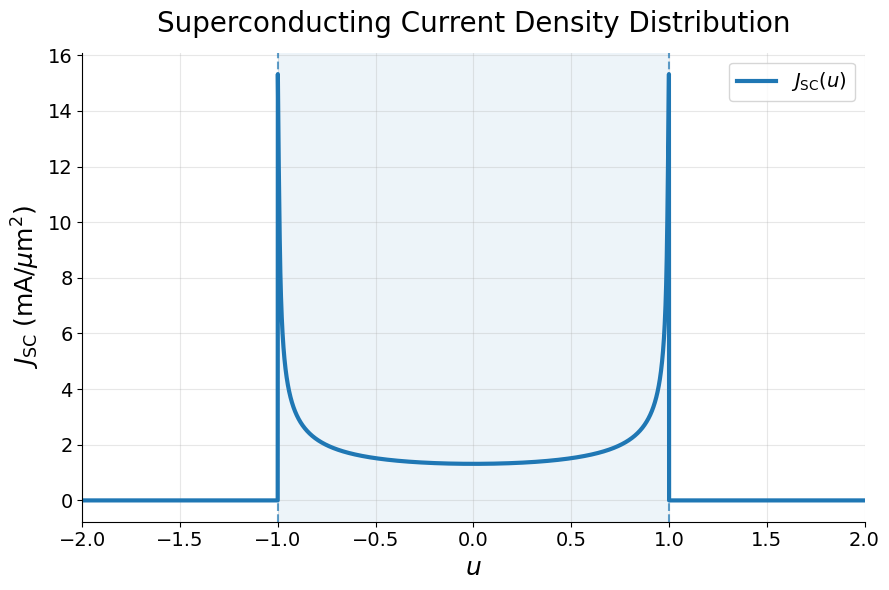

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Parameters
# ==========================
I_SC = 1          # mA
lam = 0.07           # micrometers
b = 0.1              # micrometers
W = 5              # micrometers
gamma = 0.2236

# Dimensionless penetration depth
lam_tilde = lam**2 / (b * W)

# Prefactor
prefactor = (2 * I_SC) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

# ==========================
# Current density function
# ==========================
def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <=1)
    bulk = au <= (1 - lam_tilde)

    # Edge region
    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    # Bulk region
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor * J

# ==========================
# Grid
# ==========================
min_u = -2.
max_u = 2.
u = np.linspace(min_u, max_u, 5000)

# Avoid singularities exactly at u = ±1
eps = 1e-6
#u[np.abs(u - 1) < eps] = 1 - eps
#u[np.abs(u + 1) < eps] = -1 + eps

J = J_SC(u)

# ==========================
# Plot styling
# ==========================
plt.figure(figsize=(9, 6))

plt.plot(
    u,
    J,
    lw=3,
    label=r"$J_{\rm SC}(u)$"
)

# Superconducting strip boundaries
plt.axvline(-1, ls="--", lw=1.5, alpha=0.7)
plt.axvline(1, ls="--", lw=1.5, alpha=0.7)

# Fill strip region
plt.axvspan(-1, 1, alpha=0.08)

plt.xlabel(r"$u$", fontsize=18)
plt.ylabel(
    r"$J_{\rm SC}\;(\mathrm{mA}/\mu\mathrm{m}^2)$",
    fontsize=18
)

plt.title(
    r"Superconducting Current Density Distribution",
    fontsize=20,
    pad=15
)

plt.xlim(-2, 2)

# Use logarithmic scale if desired
# plt.yscale('log')

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=14)

plt.tick_params(axis='both', labelsize=14)

# Cleaner frame
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

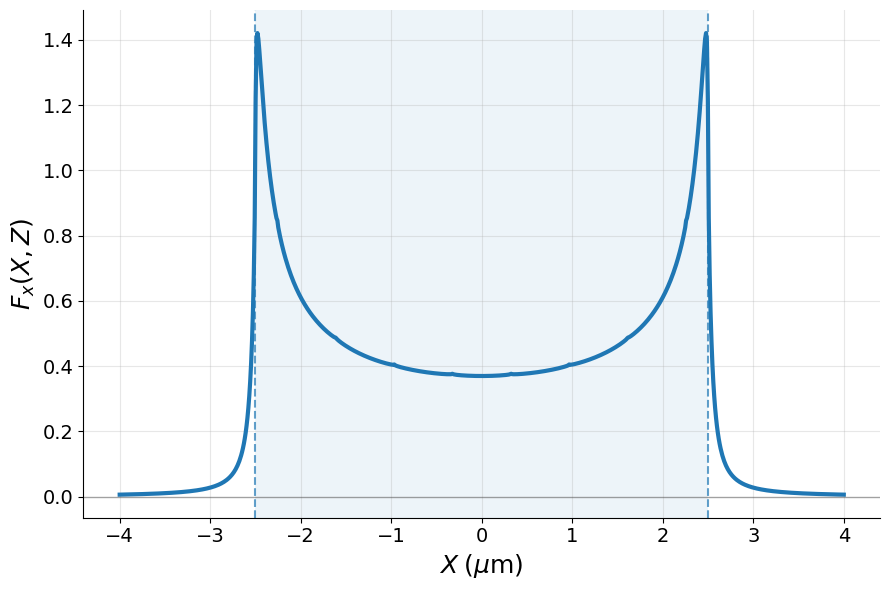

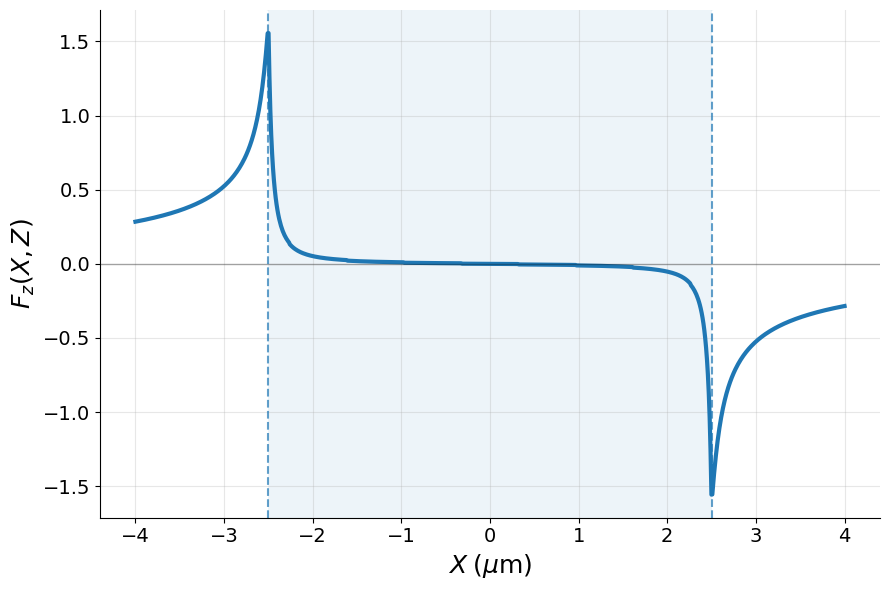

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e, physical_constants

n=1e-9
phi0 = h / (2 * e)

um = 1e-6

W_um=5
# Parameters in SI
I_SC = 1e3 * 1e-6      # A
lam = 0.07 * um        # m
b   = 0.1 * um         # m
W   = 5. * um         # m
gamma = 0.2236

mu_B = physical_constants['Bohr magneton'][0]  # A m^2
g = 1.0
mu_s = mu_B

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_SC) / (np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde)))

def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)
    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1.0)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (1 / np.sqrt(2 * lam_tilde)) * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

def compute_flux(X_vals_m, Z_m, Nu=6000):
    u = np.linspace(-1.0, 1.0, Nu)
    x_u = 0.5 * W * u
    J_ratio = J_SC(u) / I_SC

    dx = x_u[:, None] - X_vals_m[None, :]
    log_term = np.log((dx**2 + Z_m**2) / (dx**2 + (Z_m + b)**2))
    atan_term = np.arctan2(Z_m + b, dx) - np.arctan2(Z_m, dx)

    integral_fx = np.trapezoid(J_ratio[:, None] * log_term, u, axis=0)
    integral_fz = np.trapezoid(J_ratio[:, None] * atan_term, u, axis=0)

    Fx = -(g * mu_s * mu_0 * W / (8 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 * W / (4 * np.pi)) * integral_fz

    return Fx, Fz

Z_um = 0.00
Z_m = Z_um * um

X_um = np.linspace(-4.0, 4.0, 800)
X_m = X_um * um

Fx, Fz = compute_flux(X_m, Z_m, Nu=7000)

# in units of Phi0
Fx = Fx / (n*phi0)
Fz = Fz / (n*phi0)

plt.figure(figsize=(9, 6))
plt.plot(X_um, Fx, lw=3)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvline(W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvspan(-W_um/2, W_um/2, alpha=0.08)
plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_x(X,Z)$", fontsize=18)
#plt.title(rf"$F_x$ vs $X$ at fixed $Z={Z_um}\,\mu m}$", fontsize=20, pad=15)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(X_um, Fz, lw=3)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvline(W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvspan(-W_um/2, W_um/2, alpha=0.08)
plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_z(X,Z)$", fontsize=18)
#plt.title(rf"$F_z$ vs $X$ at fixed $Z={Z_um}\,\mu{\rm m}$", fontsize=20, pad=15)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

#Fast Henry Visualization


Analytical SC profile
---------------------
I_SC = 6.299510 nA

5x5 : I_profile = 1.419398e+23 nA, I_check = 6.300000 nA
15x5 : I_profile = 7.812718e+22 nA, I_check = 6.300000 nA
25x5 : I_profile = 5.472431e+22 nA, I_check = 6.300000 nA
35x5 : I_profile = 4.229782e+22 nA, I_check = 6.300000 nA
45x5 : I_profile = 3.443329e+22 nA, I_check = 6.300000 nA
50x5 : I_profile = 3.157783e+22 nA, I_check = 6.300000 nA


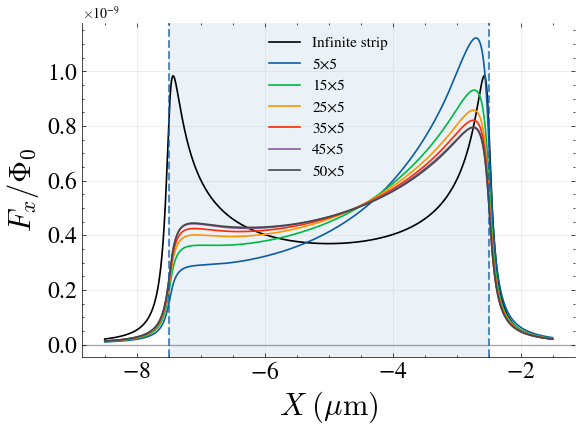

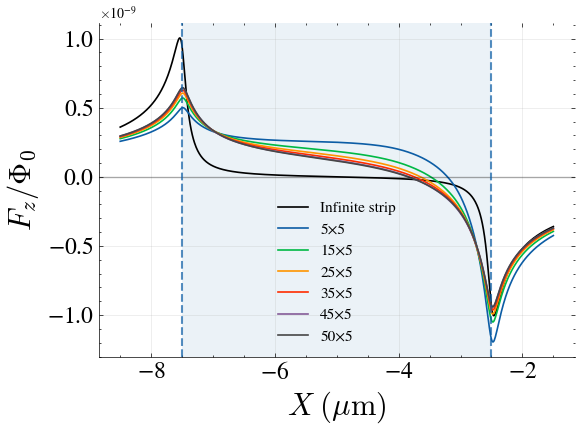

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d

# ============================================================
# Constants
# ============================================================

phi0 = h / (2 * e)
um = 1e-6

# ============================================================
# User parameters
# ============================================================

files = [5, 15, 25, 35, 45, 50]

I_target_nA = 6.3
I_target = I_target_nA * 1e-9  # A

b_um = 0.1
b = b_um * um

lam_um = 0.07
lam = lam_um * um

gamma = 0.2236
g = 1.0

mu_B = physical_constants['Bohr magneton'][0]
mu_s = mu_B

# Width of the strip represented by the profile
W_um = 5.0
W = W_um * um

# Center position of the strip
y_center_um = -5.0

# ============================================================
# Analytical superconducting current density
# ============================================================

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_target) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):

    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(
            -(1 - lam_tilde - au[edge])
            / (2 * lam_tilde)
        )
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

# ============================================================
# Build SC profile in physical coordinates
# ============================================================

u_sc = np.linspace(-1, 1, 7000)

eps = 1e-10
u_sc[np.abs(u_sc - 1) < eps] = 1 - eps
u_sc[np.abs(u_sc + 1) < eps] = -1 + eps

J_sc = J_SC(u_sc)

y_sc_m = (W / 2) * u_sc + y_center_um * um
y_sc_um = y_sc_m / um

I_sc = b * np.trapezoid(J_sc, y_sc_m)

print()
print("Analytical SC profile")
print("---------------------")
print(f"I_SC = {I_sc*1e9:.6f} nA")
print()

# ============================================================
# Helper: load and normalize one FastHenry profile
# ============================================================

def load_profile(file_id, y_min_um=-8.0, y_max_um=-2.0):

    d = np.loadtxt(f"files_FH/{file_id}x5_interp.mat")

    x_um = d[:, 0] * 1e6
    y_um = d[:, 1] * 1e6

    Jx = d[:, 3]
    Jy = d[:, 4]
    Jz = d[:, 5]

    Jmag_raw = np.sqrt(Jx**2 + Jy**2 + Jz**2)

    mask_y = (y_um >= y_min_um) & (y_um <= y_max_um)

    x1 = x_um[mask_y]
    y1 = y_um[mask_y]
    J1 = Jmag_raw[mask_y]

    x_unique = np.unique(x1)
    x0 = x_unique[np.argmin(np.abs(x_unique))]

    mask_x = np.isclose(x1, x0)

    y_cut_um = y1[mask_x]
    J_cut_raw = J1[mask_x]

    order = np.argsort(y_cut_um)

    y_cut_um = y_cut_um[order]
    J_cut_raw = J_cut_raw[order]

    y_cut_m = y_cut_um * um

    I_profile = b * np.trapezoid(
        J_cut_raw,
        y_cut_m
    )

    scale = I_target / I_profile

    J_cut_norm = J_cut_raw * scale

    J_cut_plot = J_cut_norm * 1e-3

    I_check_nA = (
        b_um
        * np.trapezoid(J_cut_plot, y_cut_um)
    )

    print(
        f"{file_id}x5 : "
        f"I_profile = {I_profile*1e9:.6e} nA, "
        f"I_check = {I_check_nA:.6f} nA"
    )

    return (
        y_cut_um,
        y_cut_m,
        J_cut_norm,
        J_cut_plot
    )

# ============================================================
# Flux calculator
# ============================================================

def compute_flux_from_profile(
    y_m,
    J_m2,
    I_reference,
    X_vals_m,
    Z_m,
    Nu=7000
):

    J_interp = interp1d(
        y_m,
        J_m2,
        kind="linear",
        bounds_error=False,
        fill_value=0.0
    )

    y_grid = np.linspace(
        y_m.min(),
        y_m.max(),
        Nu
    )

    J_y = J_interp(y_grid)

    J_ratio = J_y / I_reference

    dx = y_grid[:, None] - X_vals_m[None, :]

    log_term = np.log(
        (dx**2 + Z_m**2)
        /
        (dx**2 + (Z_m + b)**2)
    )

    atan_term = (
        np.arctan2(Z_m + b, dx)
        -
        np.arctan2(Z_m, dx)
    )

    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        y_grid,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        y_grid,
        axis=0
    )

    Fx = (
        -g * mu_s * mu_0
        / (4 * np.pi)
    ) * integral_fx

    Fz = (
        g * mu_s * mu_0
        / (2 * np.pi)
    ) * integral_fz

    return Fx, Fz

# ============================================================
# Geometry
# ============================================================

Z_um = 0.05
Z_m = Z_um * um

X_um = np.linspace(-8.5, -1.5, 800)
X_m = X_um * um

# ============================================================
# SC flux
# ============================================================

Fx_SC, Fz_SC = compute_flux_from_profile(
    y_m=y_sc_m,
    J_m2=J_sc,
    I_reference=I_target,
    X_vals_m=X_m,
    Z_m=Z_m,
    Nu=7000
)

Fx_SC /= phi0
Fz_SC /= phi0

# ============================================================
# FastHenry profiles
# ============================================================

results = {}

for n in files:

    y_um, y_m, J_norm_SI, J_plot = load_profile(n)

    Fx, Fz = compute_flux_from_profile(
        y_m=y_m,
        J_m2=J_norm_SI,
        I_reference=I_target,
        X_vals_m=X_m,
        Z_m=Z_m,
        Nu=7000
    )

    results[n] = {
        "Fx": Fx / phi0,
        "Fz": Fz / phi0,
        "J_plot": J_plot,
        "y_um": y_um,
    }

# ============================================================
# Fx plot
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    X_um,
    Fx_SC,
    color='k',
    lw=1.2,
    label='Infinite strip'
)

for n in files:

    plt.plot(
        X_um,
        results[n]["Fx"],
        lw=1.2,
        label=f"{n}×5"
    )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.axvline(
    y_center_um - W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvline(
    y_center_um + W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvspan(
    y_center_um - W_um/2,
    y_center_um + W_um/2,
    alpha=0.08
)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_x/\Phi_0$", fontsize=22)


plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fx.pdf")
plt.show()

# ============================================================
# Fz plot
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    X_um,
    Fz_SC,
    color='k',
    lw=1.2,
    label='Infinite strip'
)

for n in files:

    plt.plot(
        X_um,
        results[n]["Fz"],
        lw=1.2,
        label=f"{n}×5"
    )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.axvline(
    y_center_um - W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvline(
    y_center_um + W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvspan(
    y_center_um - W_um/2,
    y_center_um + W_um/2,
    alpha=0.08
)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_z/\Phi_0$", fontsize=22)


plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fz.pdf")
plt.show()


Analytical SC profile
---------------------
I_SC = 6.299510 nA

5x5 : I_profile = 1.419393e+23 nA, I_check = 6.300000 nA
15x5 : I_profile = 7.812718e+22 nA, I_check = 6.300000 nA
25x5 : I_profile = 5.472431e+22 nA, I_check = 6.300000 nA
35x5 : I_profile = 4.229782e+22 nA, I_check = 6.300000 nA
45x5 : I_profile = 3.443329e+22 nA, I_check = 6.300000 nA
50x5 : I_profile = 3.157783e+22 nA, I_check = 6.300000 nA


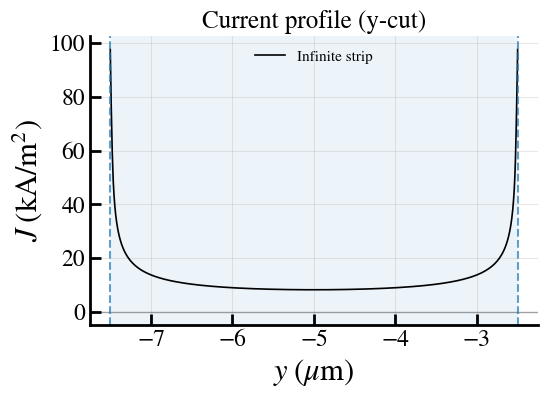

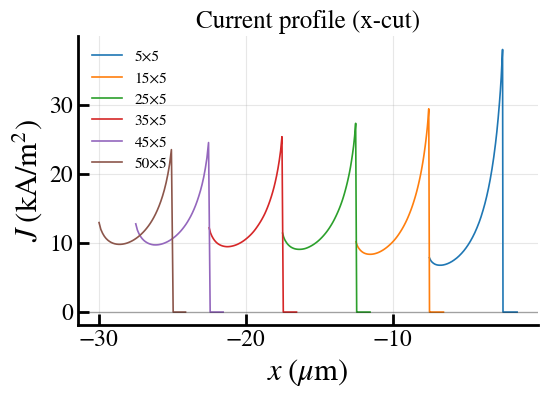

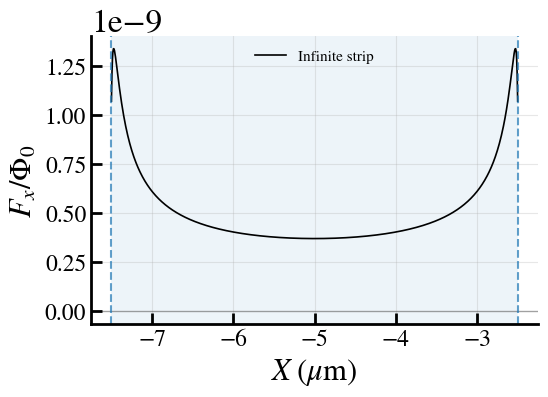

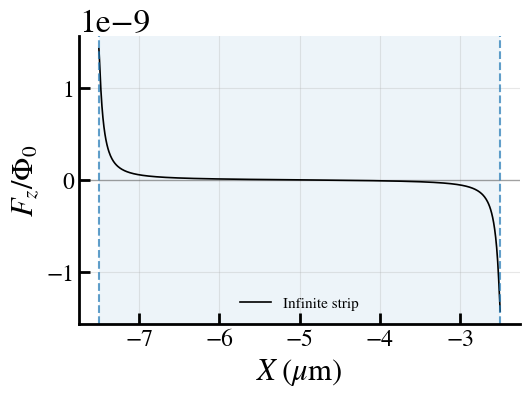

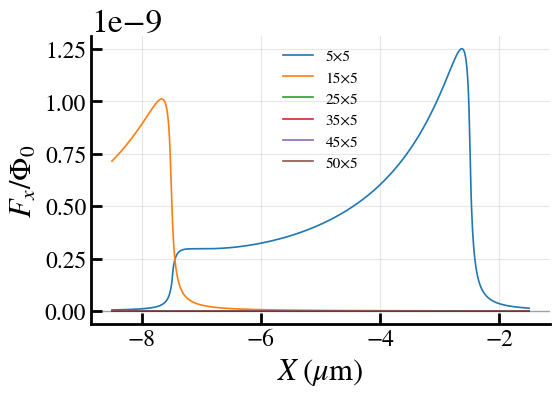

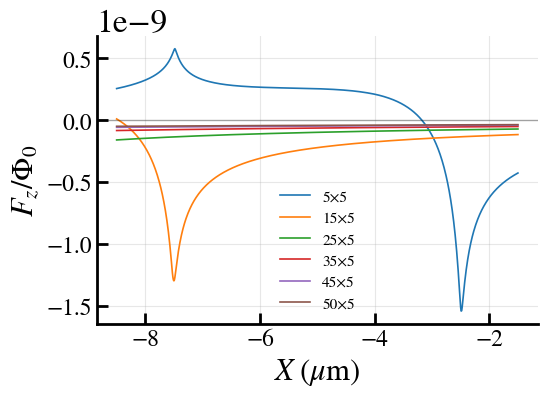

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d

# ============================================================
# Constants
# ============================================================

phi0 = h / (2 * e)
um = 1e-6

# ============================================================
# User parameters
# ============================================================

files = [5, 15, 25, 35, 45, 50]

I_target_nA = 6.3
I_target = I_target_nA * 1e-9  # A

b_um = 0.1
b = b_um * um

lam_um = 0.07
lam = lam_um * um

gamma = 0.2236
g = 1.0

mu_B = physical_constants['Bohr magneton'][0]
mu_s = mu_B

# Width of the strip represented by the profile
W_um = 5.0
W = W_um * um

# Center position of the strip
y_center_um = -5.0

# ============================================================
# Analytical superconducting current density
# ============================================================

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_target) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):

    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(
            -(1 - lam_tilde - au[edge])
            / (2 * lam_tilde)
        )
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

# ============================================================
# Build SC profile in physical coordinates
# ============================================================

u_sc = np.linspace(-1, 1, 7000)

eps = 1e-10
u_sc[np.abs(u_sc - 1) < eps] = 1 - eps
u_sc[np.abs(u_sc + 1) < eps] = -1 + eps

J_sc = J_SC(u_sc)

y_sc_m = (W / 2) * u_sc + y_center_um * um
y_sc_um = y_sc_m / um

I_sc = b * np.trapezoid(J_sc, y_sc_m)

print()
print("Analytical SC profile")
print("---------------------")
print(f"I_SC = {I_sc*1e9:.6f} nA")
print()

# ============================================================
# Helper: load and normalize one FastHenry profile
# ============================================================

def load_profile(file_id, y_min_um=-8.0, y_max_um=-2.0):

    d = np.loadtxt(f"files_FH/{file_id}x5_interp.mat")

    x_um = d[:, 0] * 1e6
    y_um = d[:, 1] * 1e6

    Jx = d[:, 2]
    Jy = d[:, 3]
    Jz = d[:, 4]

    Jmag_raw = np.sqrt(Jx**2 + Jy**2 + Jz**2)

    # ------------------------------------------------------------
    # y-cut: fixed x (closest unique x to 0), vertical profile J(y)
    # ------------------------------------------------------------

    mask_y = (y_um >= y_min_um) & (y_um <= y_max_um)

    x1 = x_um[mask_y]
    y1 = y_um[mask_y]
    J1 = Jmag_raw[mask_y]

    x_unique = np.unique(x1)
    x0 = x_unique[np.argmin(np.abs(x_unique))]

    mask_x = np.isclose(x1, x0)

    y_cut_um = y1[mask_x]
    J_cut_raw = J1[mask_x]

    order = np.argsort(y_cut_um)

    y_cut_um = y_cut_um[order]
    J_cut_raw = J_cut_raw[order]

    y_cut_m = y_cut_um * um

    I_profile = b * np.trapezoid(
        J_cut_raw,
        y_cut_m
    )

    scale = I_target / I_profile

    J_cut_norm = J_cut_raw * scale

    J_cut_plot = J_cut_norm * 1e-3

    I_check_nA = (
        b_um
        * np.trapezoid(J_cut_plot, y_cut_um)
    )

    print(
        f"{file_id}x5 : "
        f"I_profile = {I_profile*1e9:.6e} nA, "
        f"I_check = {I_check_nA:.6f} nA"
    )

    # ------------------------------------------------------------
    # x-cut: fixed y (closest unique y to 0), horizontal profile
    # J(x), x masked to a 7 um window (same width as the original
    # y_min_um..y_max_um span) centered at xcenter = -(n+5)/2.
    # ------------------------------------------------------------

    xcenter = -(file_id + 5) / 2

    mask_x_window = (
        (x_um >= xcenter - 3.5)
        & (x_um <= xcenter + 3.5)
    )

    x2 = x_um[mask_x_window]
    y2 = y_um[mask_x_window]
    J2 = Jmag_raw[mask_x_window]

    y_unique = np.unique(y2)
    y0 = y_unique[np.argmin(np.abs(y_unique))]

    mask_y_fixed = np.isclose(y2, y0)

    x_cut_um = x2[mask_y_fixed]
    J_xcut_raw = J2[mask_y_fixed]

    order_x = np.argsort(x_cut_um)

    x_cut_um = x_cut_um[order_x]
    J_xcut_raw = J_xcut_raw[order_x]

    x_cut_m = x_cut_um * um

    J_xcut_norm = J_xcut_raw * scale

    J_xcut_plot = J_xcut_norm * 1e-3

    return (
        y_cut_um,
        y_cut_m,
        J_cut_norm,
        J_cut_plot,
        x_cut_um,
        x_cut_m,
        J_xcut_norm,
        J_xcut_plot,
    )

# ============================================================
# Flux calculator
# ============================================================
#
# Fields F(X, Z) are evaluated pointwise given arrays of X and Z
# of the SAME length (i.e. it evaluates F along whatever 1D path
# (X_vals_m[i], Z_vals_m[i]) is passed in). This lets the same
# function be reused both for:
#   - a horizontal cut: X_vals_m = sweep, Z_vals_m = scalar (broadcast)
#   - a vertical cut:   X_vals_m = scalar (broadcast), Z_vals_m = sweep
# ============================================================

def compute_flux_from_profile(
    y_m,
    J_m2,
    I_reference,
    X_vals_m,
    Z_vals_m,
    Nu=7000
):

    X_vals_m = np.atleast_1d(np.asarray(X_vals_m, dtype=float))
    Z_vals_m = np.atleast_1d(np.asarray(Z_vals_m, dtype=float))

    # broadcast scalar-vs-vector combinations to a common length
    if X_vals_m.size == 1 and Z_vals_m.size > 1:
        X_vals_m = np.full_like(Z_vals_m, X_vals_m[0])
    elif Z_vals_m.size == 1 and X_vals_m.size > 1:
        Z_vals_m = np.full_like(X_vals_m, Z_vals_m[0])

    J_interp = interp1d(
        y_m,
        J_m2,
        kind="linear",
        bounds_error=False,
        fill_value=0.0
    )

    y_grid = np.linspace(
        y_m.min(),
        y_m.max(),
        Nu
    )

    J_y = J_interp(y_grid)

    J_ratio = J_y / I_reference

    dx = y_grid[:, None] - X_vals_m[None, :]
    Z_b = Z_vals_m[None, :]

    log_term = np.log(
        (dx**2 + Z_b**2)
        /
        (dx**2 + (Z_b + b)**2)
    )

    atan_term = (
        np.arctan2(Z_b + b, dx)
        -
        np.arctan2(Z_b, dx)
    )

    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        y_grid,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        y_grid,
        axis=0
    )

    Fx = (
        -g * mu_s * mu_0
        / (4 * np.pi)
    ) * integral_fx

    Fz = (
        g * mu_s * mu_0
        / (2 * np.pi)
    ) * integral_fz

    return Fx, Fz

# ============================================================
# Geometry
# ============================================================

Z_um = 0.005
Z_m = Z_um * um

X_um = np.linspace(-7.5, -2.5, 800)
X_m = X_um * um

# Second sweep, for the x-cut (J vs x at fixed y~0). Same width
# (7 um) as X_um, evaluated at the same fixed height Z_um.
X2_um = np.linspace(-8.5, -1.5, 800)
X2_m = X2_um * um

# ============================================================
# SC flux
# ============================================================

Fx_SC, Fz_SC = compute_flux_from_profile(
    y_m=y_sc_m,
    J_m2=J_sc,
    I_reference=I_target,
    X_vals_m=X_m,
    Z_vals_m=Z_m,
    Nu=7000
)

Fx_SC /= phi0
Fz_SC /= phi0

# SC current density in the same "plot" units as the FastHenry
# profiles (kA/m^2, i.e. raw SI * 1e-3), so it can be overlaid
# directly on the current-profile plots below.
J_sc_plot = J_sc * 1e-3

# ============================================================
# FastHenry profiles
# ============================================================

results = {}

for n in files:

    (
        y_um, y_m, J_norm_SI, J_plot,
        x_cut_um, x_cut_m, J_xcut_SI, J_xcut_plot,
    ) = load_profile(n)

    Fx, Fz = compute_flux_from_profile(
        y_m=y_m,
        J_m2=J_norm_SI,
        I_reference=I_target,
        X_vals_m=X_m,
        Z_vals_m=Z_m,
        Nu=7000
    )

    Fx_xcut, Fz_xcut = compute_flux_from_profile(
        y_m=x_cut_m,
        J_m2=J_xcut_SI,
        I_reference=I_target,
        X_vals_m=X2_m,
        Z_vals_m=Z_m,
        Nu=7000
    )

    results[n] = {
        "Fx": Fx / phi0,
        "Fz": Fz / phi0,
        "Fx_xcut": Fx_xcut / phi0,
        "Fz_xcut": Fz_xcut / phi0,
        "J_plot": J_plot,
        "y_um": y_um,
        "J_xcut_plot": J_xcut_plot,
        "x_cut_um": x_cut_um,
    }

# ============================================================
# Current profile plot (y-cut): J(y) used to compute Fx/Fz
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    y_sc_um,
    J_sc_plot,
    color='k',
    lw=1.2,
    label='Infinite strip'
)

# for n in files:

#     plt.plot(
#         results[n]["y_um"],
#         results[n]["J_plot"],
#         lw=1.2,
#         label=f"{n}×5"
#     )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.axvline(
    y_center_um - W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvline(
    y_center_um + W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvspan(
    y_center_um - W_um/2,
    y_center_um + W_um/2,
    alpha=0.08
)

plt.xlabel(r"$y\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$J\;({\rm kA/m^2})$", fontsize=22)
plt.title("Current profile (y-cut)", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("J_profile_ycut.pdf")
plt.show()

# ============================================================
# Current profile plot (x-cut): J(x) used to compute
# Fx_xcut/Fz_xcut
# ============================================================

plt.figure(figsize=(6, 4.5))

for n in files:

    plt.plot(
        results[n]["x_cut_um"],
        results[n]["J_xcut_plot"],
        lw=1.2,
        label=f"{n}×5"
    )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.xlabel(r"$x\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$J\;({\rm kA/m^2})$", fontsize=22)
plt.title("Current profile (x-cut)", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("J_profile_xcut.pdf")
plt.show()

# ============================================================
# Fx plot (horizontal cut, fixed Z)
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    X_um,
    Fx_SC,
    color='k',
    lw=1.2,
    label='Infinite strip'
)

# for n in files:

#     plt.plot(
#         X_um,
#         results[n]["Fx"],
#         lw=1.2,
#         label=f"{n}×5"
#     )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.axvline(
    y_center_um - W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvline(
    y_center_um + W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvspan(
    y_center_um - W_um/2,
    y_center_um + W_um/2,
    alpha=0.08
)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_x/\Phi_0$", fontsize=22)


plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fx.pdf")
plt.show()

# ============================================================
# Fz plot (horizontal cut, fixed Z)
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    X_um,
    Fz_SC,
    color='k',
    lw=1.2,
    label='Infinite strip'
)

# for n in files:

#     plt.plot(
#         X_um,
#         results[n]["Fz"],
#         lw=1.2,
#         label=f"{n}×5"
#     )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.axvline(
    y_center_um - W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvline(
    y_center_um + W_um/2,
    ls='--',
    lw=1.5,
    alpha=0.7
)

plt.axvspan(
    y_center_um - W_um/2,
    y_center_um + W_um/2,
    alpha=0.08
)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_z/\Phi_0$", fontsize=22)


plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fz.pdf")
plt.show()

# ============================================================
# Fx plot (x-cut: J vs x at fixed y~0)
# ============================================================

plt.figure(figsize=(6, 4.5))

for n in files:

    plt.plot(
        X2_um,#+(n+5)/2,
        results[n]["Fx_xcut"],
        lw=1.2,
        label=f"{n}×5"
    )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_x/\Phi_0$", fontsize=22)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fx_xcut.pdf")
plt.show()

# ============================================================
# Fz plot (x-cut: J vs x at fixed y~0)
# ============================================================

plt.figure(figsize=(6, 4.5))

for n in files:

    plt.plot(
        X2_um,#+(n+5)/2,
        results[n]["Fz_xcut"],
        lw=1.2,
        label=f"{n}×5"
    )

plt.axhline(0, color='k', lw=1, alpha=0.3)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=22)
plt.ylabel(r"$F_z/\Phi_0$", fontsize=22)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=17)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Fz_xcut.pdf")
plt.show()

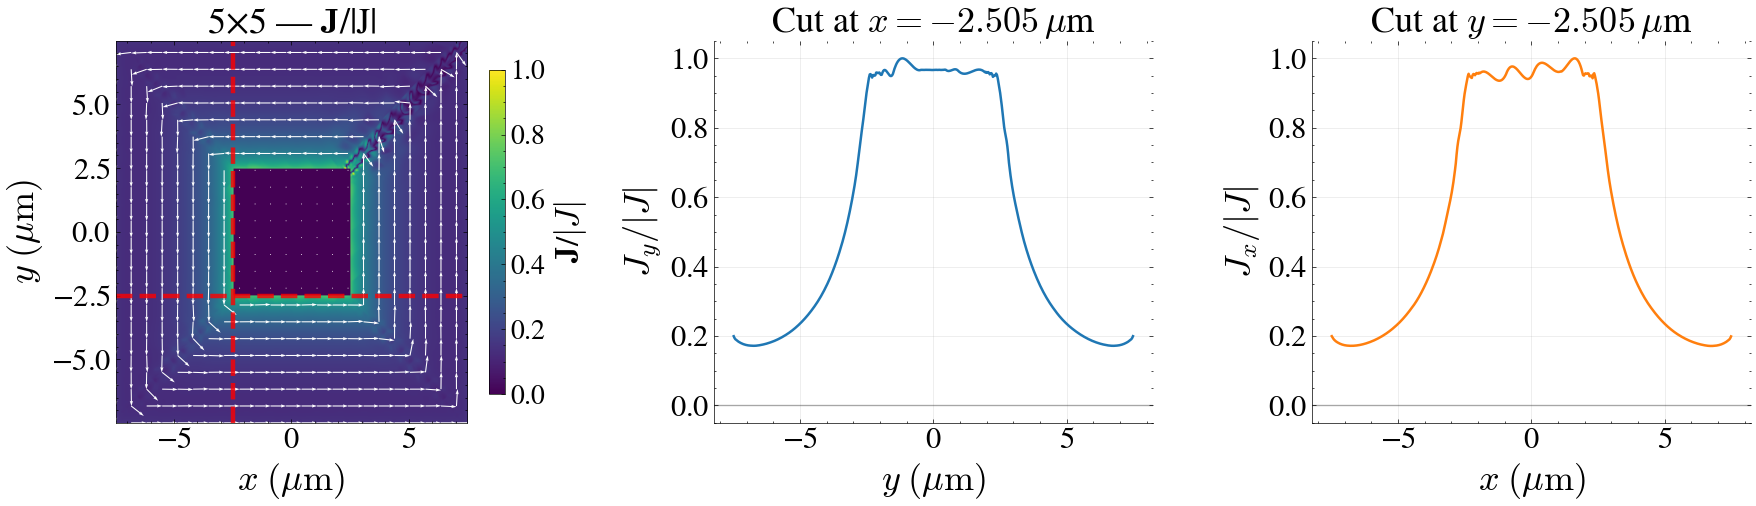

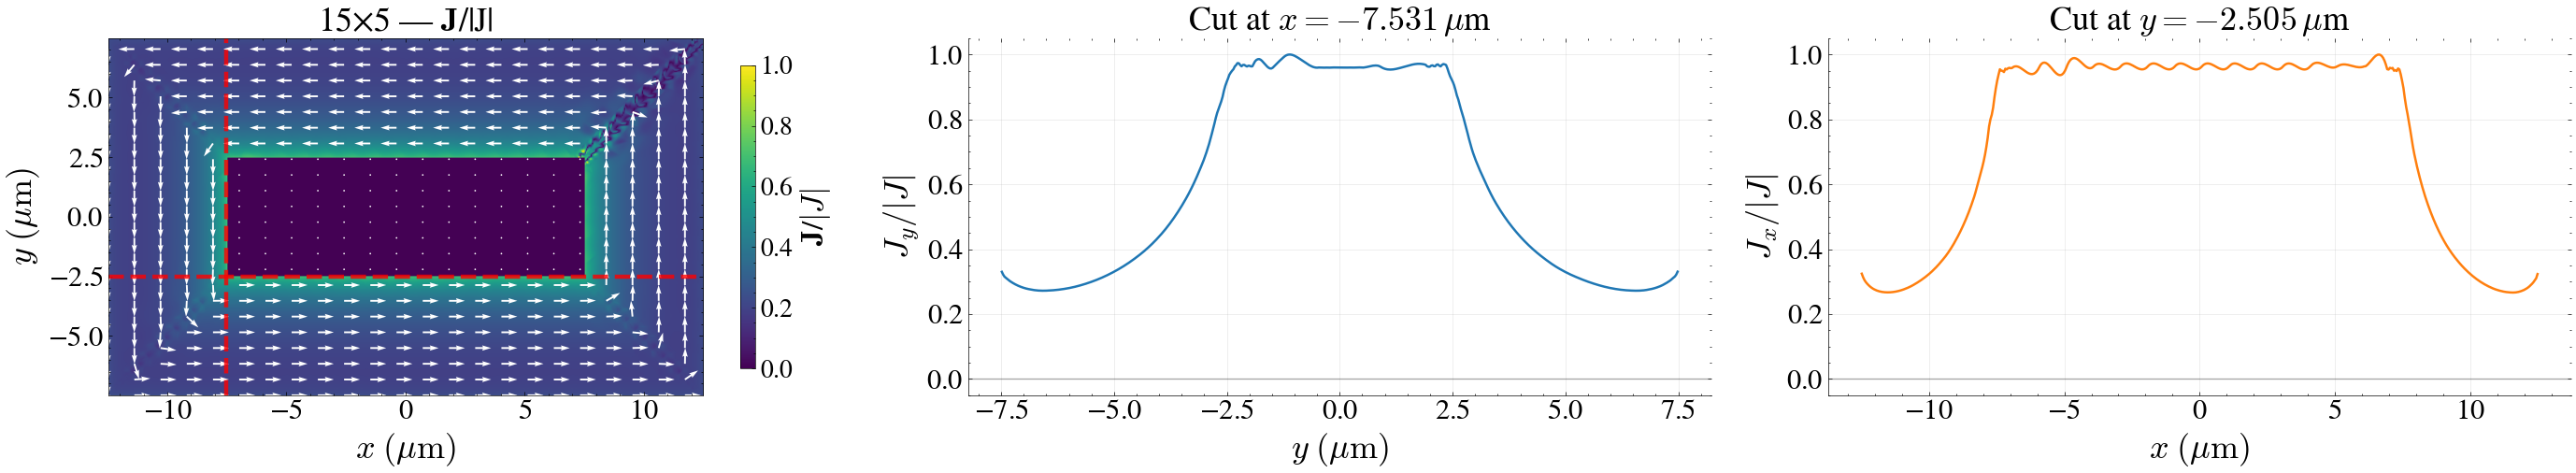

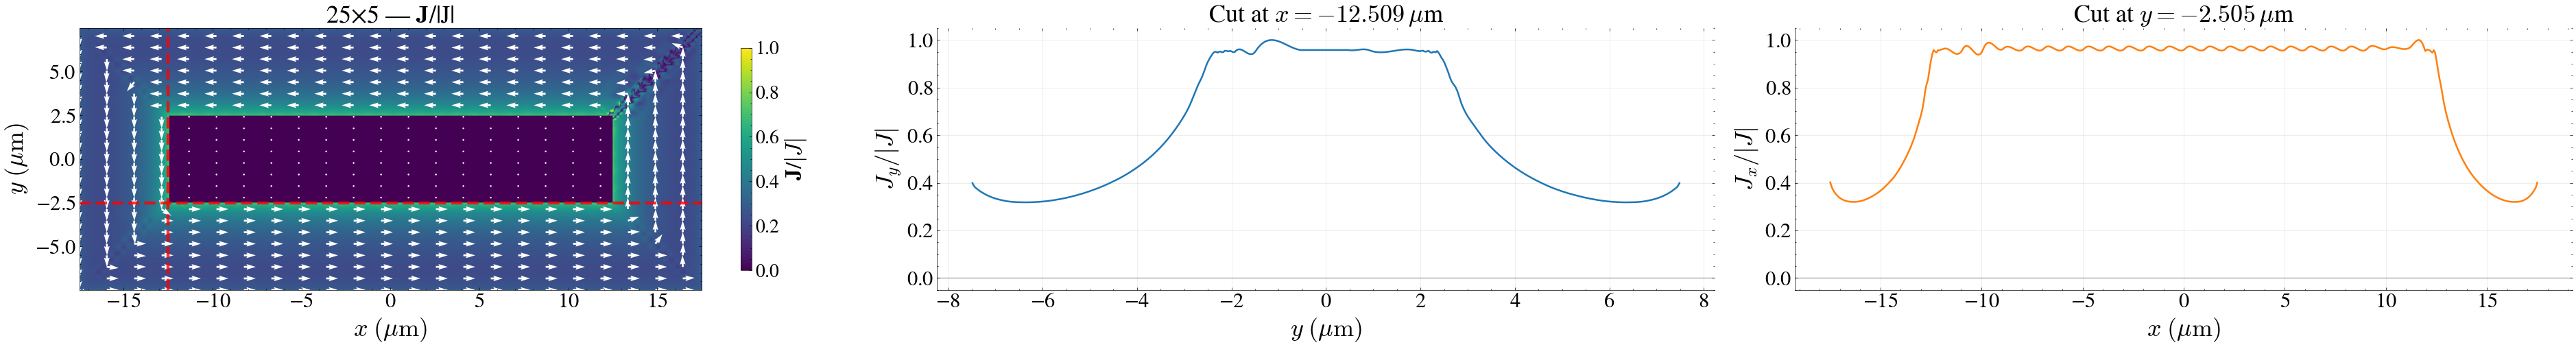

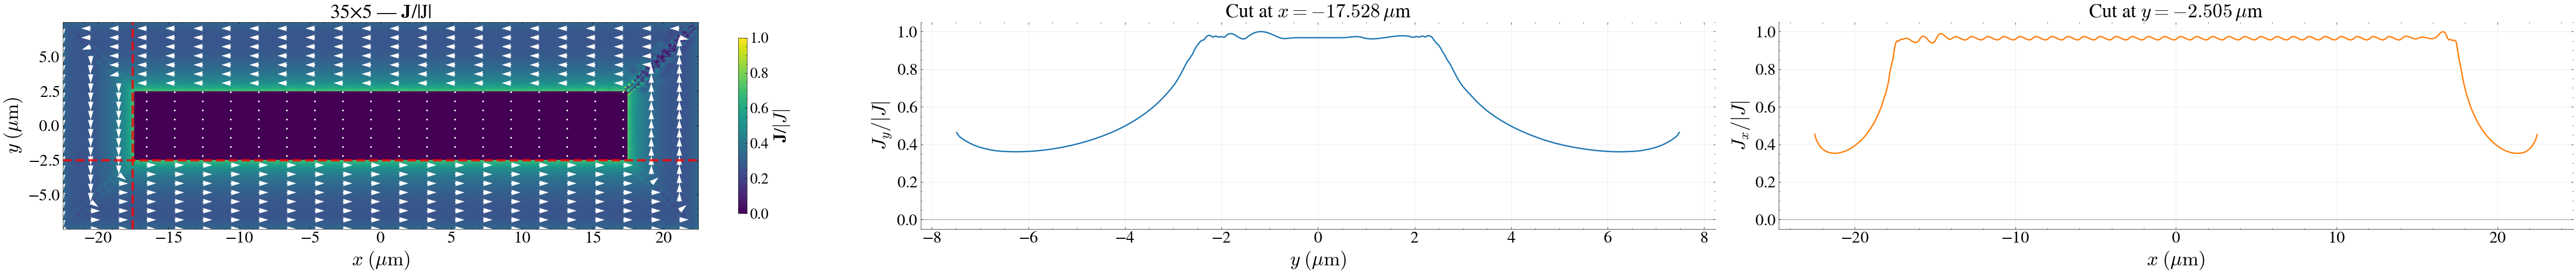

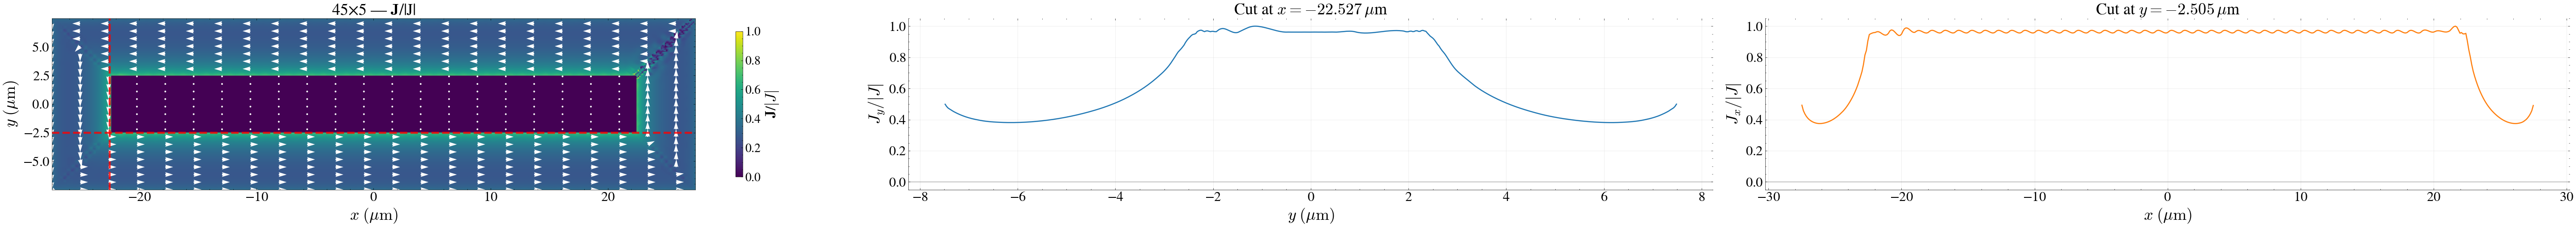

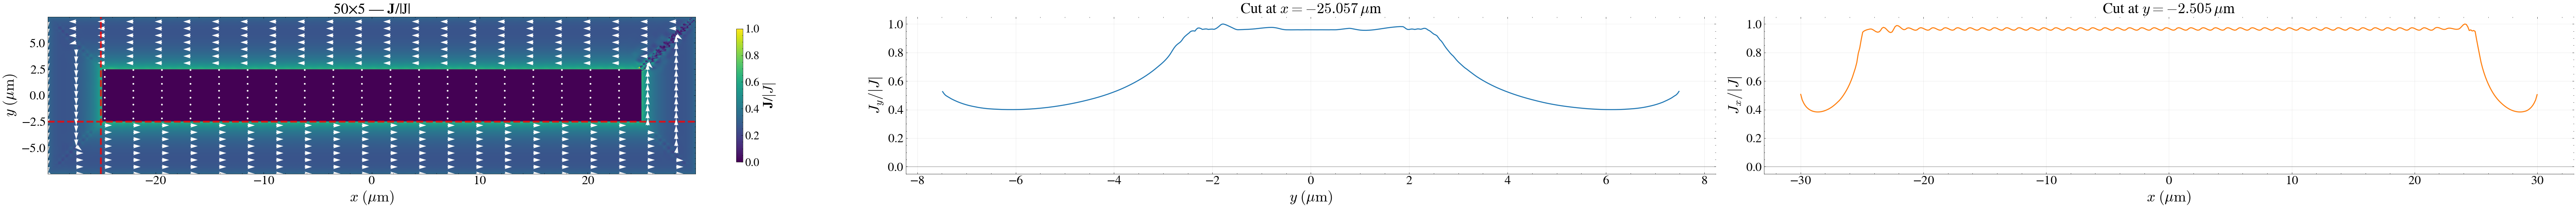

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Global font size settings
# ============================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 22,
})

TITLE_FS = 26
LABEL_FS = 26
TICK_FS = 22
CBAR_LABEL_FS = 24
CBAR_TICK_FS = 20

# ============================================================
# User parameters
# ============================================================

files = [5, 15, 25, 35, 45, 50]

y_fixed_um = -2.51


def x_cut_fixed_um(n):
    return -n / 2 - 0.01


# ============================================================
# Helper: load raw FastHenry data and build a regular grid
# ============================================================

def load_grid(file_id):

    d = np.loadtxt(f"files_FH/{file_id}x5_interp.mat")

    x_um = d[:, 0] * 1e6
    y_um = d[:, 1] * 1e6

    Jx = d[:, 2]
    Jy = d[:, 3]
    Jz = d[:, 4]

    Jmag = np.sqrt(Jx**2 + Jy**2 + Jz**2)

    x_unique = np.unique(x_um)
    y_unique = np.unique(y_um)

    nx = x_unique.size
    ny = y_unique.size

    # map each point to its grid index
    x_idx = np.searchsorted(x_unique, x_um)
    y_idx = np.searchsorted(y_unique, y_um)

    J_grid = np.full((ny, nx), np.nan)
    J_grid[y_idx, x_idx] = Jmag

    Jx_grid = np.full((ny, nx), np.nan)
    Jx_grid[y_idx, x_idx] = Jx

    Jy_grid = np.full((ny, nx), np.nan)
    Jy_grid[y_idx, x_idx] = Jy

    return x_unique, y_unique, J_grid, Jx_grid, Jy_grid


# ============================================================
# Helper: nearest-value cut along a regular grid
# ============================================================

def cut_along_x(x_unique, y_unique, J_grid, x_fixed_um):
    """Fix x (nearest available value), return J(y) at that x."""

    ix = np.argmin(np.abs(x_unique - x_fixed_um))
    x_used = x_unique[ix]

    J_line = J_grid[:, ix]

    return y_unique, J_line, x_used


def cut_along_y(x_unique, y_unique, J_grid, y_fixed_um):
    """Fix y (nearest available value), return J(x) at that y."""

    iy = np.argmin(np.abs(y_unique - y_fixed_um))
    y_used = y_unique[iy]

    J_line = J_grid[iy, :]

    return x_unique, J_line, y_used


# ============================================================
# Main loop: imshow + cuts for each profile
# ============================================================

for n in files:

    x_unique, y_unique, J_grid, Jx_grid, Jy_grid = load_grid(n)

    x_fixed_um = x_cut_fixed_um(n)

    y_vals, J_xline, x_used = cut_along_x(
        x_unique, y_unique, J_grid, x_fixed_um
    )

    x_vals, J_yline, y_used = cut_along_y(
        x_unique, y_unique, J_grid, y_fixed_um
    )

    extent = [
        x_unique.min(), x_unique.max(),
        y_unique.min(), y_unique.max(),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18+n-5, 5.5))

    # --- imshow ---
    ax = axes[0]

    im = ax.imshow(
        J_grid/J_grid.max(),
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="viridis",
    )
    #ax = axes[1]

    # Make a coarser grid for the arrows
    step = 10

    X, Y = np.meshgrid(x_unique, y_unique)
    Jmag_xy = np.sqrt(Jx_grid**2 + Jy_grid**2)

    Ux = Jx_grid / (Jmag_xy + 1e-30)
    Uy = Jy_grid / (Jmag_xy + 1e-30)

    step = 22

    ax.quiver(
        X[::step, ::step],
        Y[::step, ::step],
        Ux[::step, ::step],
        Uy[::step, ::step],
        color="white",
        angles="xy",
        scale_units="xy",
        scale=1.5,
        width=0.003,
    )

    ax.axvline(x_used, color="r", ls="--", lw=3.2, alpha=0.8)
    ax.axhline(y_used, color="r", ls="--", lw=3.2, alpha=0.8)

    ax.set_xlabel(r"$x\;(\mu{\rm m})$", fontsize=LABEL_FS)
    ax.set_ylabel(r"$y\;(\mu{\rm m})$", fontsize=LABEL_FS)
    ax.set_title(rf"{n}×5 — $\mathbf{{J}}$/|J|", fontsize=TITLE_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, label=r"$\mathbf{{J}}$/$|J|$")
    cbar.set_label(r"$\mathbf{{J}}$/$|J|$", fontsize=CBAR_LABEL_FS)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FS)

    # --- cut along y at fixed x ---
    ax = axes[1]

    ax.plot(y_vals, J_xline/J_xline.max(), lw=1.8, color="tab:blue")
    ax.axhline(0, color="k", lw=1, alpha=0.3)

    ax.set_xlabel(r"$y\;(\mu{\rm m})$", fontsize=LABEL_FS)
    ax.set_ylabel(r"$J_y/|J|$", fontsize=LABEL_FS)
    ax.set_title(f"Cut at $x={x_used:.3f}\\,\\mu$m", fontsize=TITLE_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

    ax.grid(True, alpha=0.3)

    # --- cut along x at fixed y ---
    ax = axes[2]

    ax.plot(x_vals, J_yline/J_yline.max(), lw=1.8, color="tab:orange")
    ax.axhline(0, color="k", lw=1, alpha=0.3)

    ax.set_xlabel(r"$x\;(\mu{\rm m})$", fontsize=LABEL_FS)
    ax.set_ylabel(r"$J_x/|J|$", fontsize=LABEL_FS)
    ax.set_title(f"Cut at $y={y_used:.3f}\\,\\mu$m", fontsize=TITLE_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

    ax.grid(True, alpha=0.3)

    for a in axes[1:]:
        for spine in ["top", "right"]:
            a.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"imshow_cuts_{n}x5.pdf")
    plt.show()

In [ ]:
# ============================================================
# Analytical superconducting current density
# ============================================================

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_target) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):

    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(
            -(1 - lam_tilde - au[edge])
            / (2 * lam_tilde)
        )
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J


# ------------------------------------------------------------
# Build J_SC on physical y-grid
# ------------------------------------------------------------

u_sc = np.linspace(-1, 1, 10000)

eps = 1e-8
u_sc[np.abs(u_sc - 1) < eps] = 1 - eps
u_sc[np.abs(u_sc + 1) < eps] = -1 + eps

J_sc_raw = J_SC(u_sc)

# physical coordinate
y_sc_m = (W / 2) * u_sc - 5 * um
y_sc_um = y_sc_m / um

# ------------------------------------------------------------
# Normalize exactly to I_target
# ------------------------------------------------------------

I_sc = b * np.trapezoid(J_sc_raw, y_sc_m)

J_sc_norm = J_sc_raw * (I_target / I_sc)

I_sc_check = b * np.trapezoid(J_sc_norm, y_sc_m)

print()
print("SC profile")
print("----------")
print(f"I_sc raw   = {I_sc*1e9:.6f} nA")
print(f"I_sc norm  = {I_sc_check*1e9:.6f} nA")
print()

# ------------------------------------------------------------
# Flux from SC profile
# ------------------------------------------------------------

Fx_SC, Fz_SC = compute_flux_from_profile(
    y_m=y_sc_m,
    J_m2=J_sc_norm,
    I_reference=I_target,
    X_vals_m=X_m,
    Z_m=Z_m,
    Nu=7000
)

Fx_SC /= phi0
Fz_SC /= phi0


SC profile
----------
I_sc raw   = 6.299629 nA
I_sc norm  = 6.300000 nA



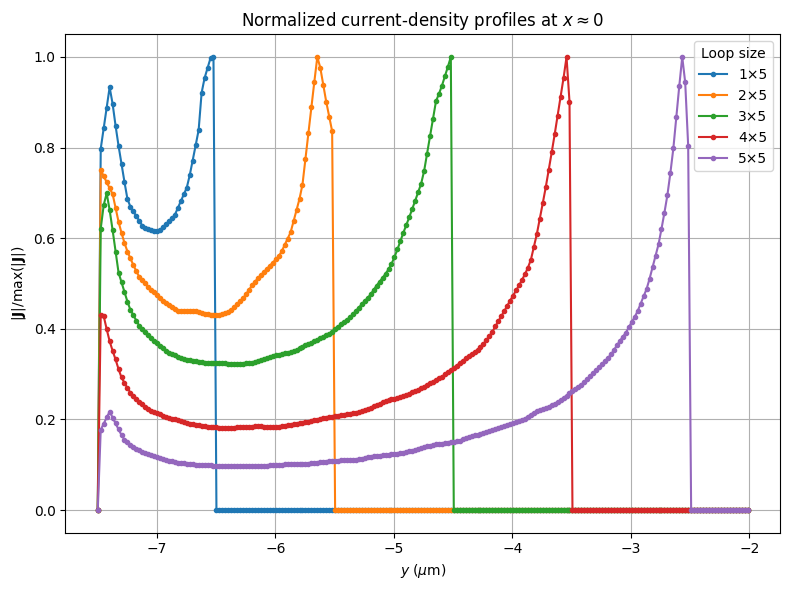

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================

#files = [5, 15, 25, 35, 45, 50]
files = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 6))

for n in files:

    # --------------------------------------------------------
    # Load superscreen data
    # --------------------------------------------------------
    data = np.load(f"files_width/loop_superscreen_n1_5x5_no_{n}w.npz")

    x = data["X"]          # μm
    y = data["Y"]          # μm

    Jx = data["Jx"]        # μA/μm
    Jy = data["Jy"]        # μA/μm

    # Current-density magnitude
    Jmag = np.sqrt(Jx**2 + Jy**2)

    # --------------------------------------------------------
    # Restrict y range
    # --------------------------------------------------------
    mask_y = (y >= -8) & (y <= -2)

    x1 = x[mask_y]
    y1 = y[mask_y]
    J1 = Jmag[mask_y]

    # --------------------------------------------------------
    # Find x slice closest to x = 0
    # --------------------------------------------------------
    x_unique = np.unique(x1)
    x0 = x_unique[np.argmin(np.abs(x_unique))]

    mask_x = np.isclose(x1, x0)

    y_cut = y1[mask_x]
    J_cut = J1[mask_x]

    # Sort by y
    order = np.argsort(y_cut)

    y_cut = y_cut[order]
    J_cut = J_cut[order]

    # Normalize by maximum
    J_cut = J_cut / np.max(J_cut)

    plt.plot(
        y_cut,
        J_cut,
        "-o",
        markersize=3,
        label=f"{n}×5"
    )

plt.xlabel(r"$y\;(\mu\mathrm{m})$")
plt.ylabel(r"$|\mathbf{J}|/\max(|\mathbf{J}|)$")
plt.title(r"Normalized current-density profiles at $x\approx0$")
plt.grid(True)
plt.legend(title="Loop size")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import superscreen as sc
from superscreen.geometry import box

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
L = 100.0          # strip length (um)  -> make this much larger than W
W = 10.0           # strip width  (um)
lam = 0.07         # London penetration depth (um)
thickness = 0.1    # film thickness (um)
I0 = 100.0         # transport current (uA)

# Mesh controls
max_edge_length = 0.8

# ------------------------------------------------------------
# DEVICE GEOMETRY
# ------------------------------------------------------------
layer = sc.Layer("base", london_lambda=lam, thickness=thickness, z0=0)

# Main superconducting strip
film = sc.Polygon("strip", layer="base", points=box(L, W))

# Narrow terminals on the left and right ends
# They must lie on the film boundary.
terminal_thickness = L / 100.0
source = sc.Polygon(
    "source",
    points=box(terminal_thickness, W, center=(-L / 2, 0.0))
)
drain = sc.Polygon(
    "drain",
    points=box(terminal_thickness, W, center=( L / 2, 0.0))
)

device = sc.Device(
    "long_strip",
    layers=[layer],
    films=[film],
    terminals={"strip": [source, drain]},
    length_units="um",
)

device.make_mesh(max_edge_length=max_edge_length, smooth=0)

# ------------------------------------------------------------
# SOLVE WITH TRANSPORT CURRENT
# ------------------------------------------------------------
terminal_currents = {
    "strip": {
        "source": f"{I0} uA",
        "drain": f"-{I0} uA",
    }
}

solution = sc.solve(
    device=device,
    applied_field=sc.sources.ConstantField(0),
    terminal_currents=terminal_currents,
    current_units="uA",
)[-1]

# ------------------------------------------------------------
# SAMPLE CROSS SECTION IN THE MIDDLE OF THE STRIP
# ------------------------------------------------------------
x0 = 0.0
y = np.linspace(-0.49 * W, 0.49 * W, 1200)
x = np.full_like(y, x0)
positions = np.column_stack([x, y])

J = solution.interp_current_density(
    positions,
    film="strip",
    units="uA/um",
    with_units=False,
)

Jx = J[:, 0]
Jy = J[:, 1]

# Check that the integrated profile gives the transport current
I_mid = np.trapz(Jx, y)
print(f"Integrated current across x = {x0:.2f} um: {I_mid:.6f} uA")

# Optional consistency check using the built-in path integral
path = np.array([[x0, -W / 2], [x0, W / 2]])
I_path = solution.current_through_path(
    path,
    film="strip",
    units="uA",
    with_units=False,
)
print(f"current_through_path result: {I_path:.6f} uA")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# Device mesh and terminals
device.plot_mesh(ax=ax[0], edge_color="k", show_sites=False)
device.plot_polygons(ax=ax[0], legend=True)
ax[0].set_title("Long superconducting strip")
ax[0].set_aspect("equal")

# Cross-section current density
ax[1].plot(y, Jx, lw=2, label=r"$J_x(y)$")
ax[1].plot(y, Jy, lw=1.5, label=r"$J_y(y)$")
ax[1].set_xlabel(r"$y\;(\mu m)$")
ax[1].set_ylabel(r"$J\;(\mu A/\mu m)$")
ax[1].set_title(rf"Cross section at $x={x0:.1f}\,\mu m$")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


Analytical SC profile
---------------------
I_SC = 6.299510 nA

0.014999218436873532 0.014999218436873532
5x5 : I_profile = 1.406758e+23 nA, I_check = 6.300000 nAI_check = 6.294398 nA
-0.025019238476953542 0.014999218436873532
15x5 : I_profile = 7.757082e+22 nA, I_check = 6.300000 nAI_check = 6.219339 nA
-0.03503927855711395 0.014999218436873532
25x5 : I_profile = 5.437083e+22 nA, I_check = 6.300000 nAI_check = 6.286914 nA
0.04505931863727267 0.014999218436873532
35x5 : I_profile = 4.203809e+22 nA, I_check = 6.300000 nAI_check = 6.233543 nA
-0.05507935871743478 0.014999218436873532
45x5 : I_profile = 3.423009e+22 nA, I_check = 6.300000 nAI_check = 6.245815 nA
-0.060089378757514134 0.014999218436873532
50x5 : I_profile = 3.139141e+22 nA, I_check = 6.300000 nAI_check = 6.165183 nA
5 x 5
-----------------------
1.7429329340609265e-11
2.4136739536249156e-11
-----------------------
7.932957053548858e-12
7.939579804450019e-12
0.9991658562462652
0.19624365442819894
0.1960799590096476
-------

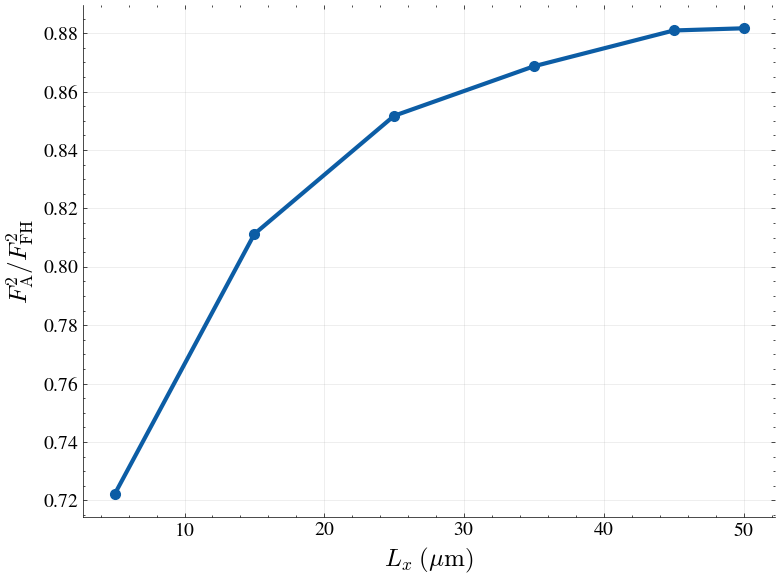

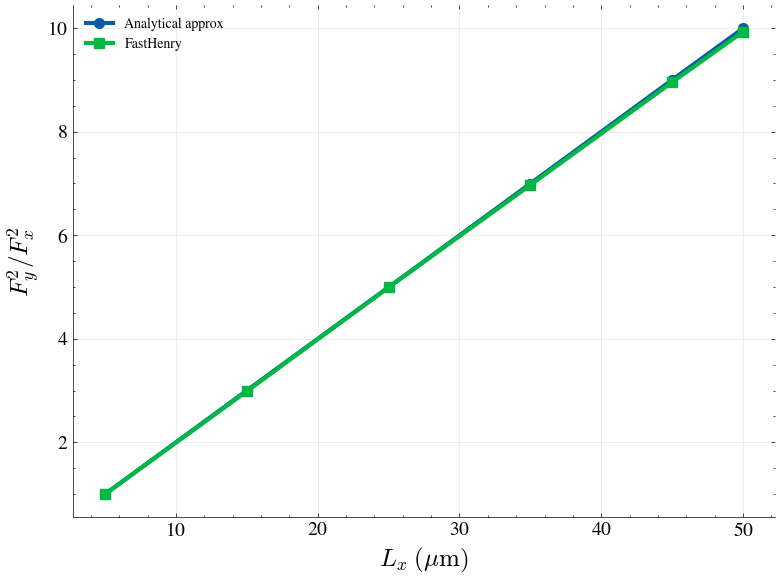

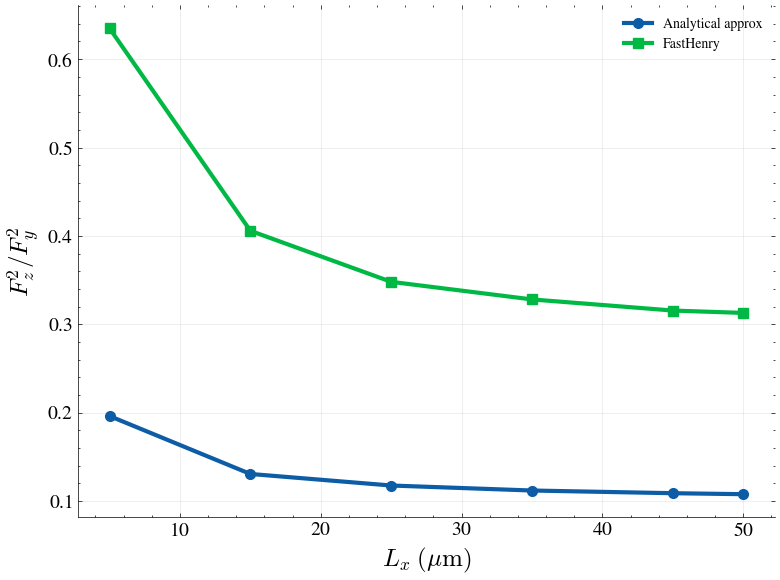

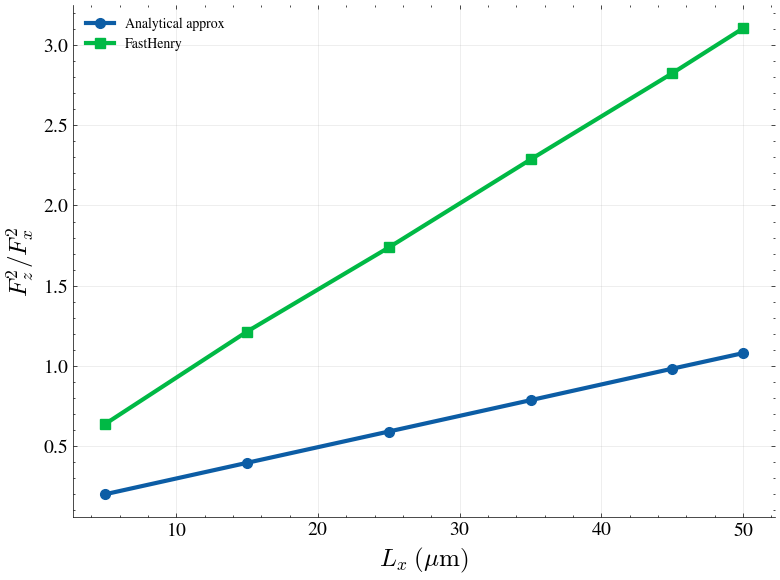

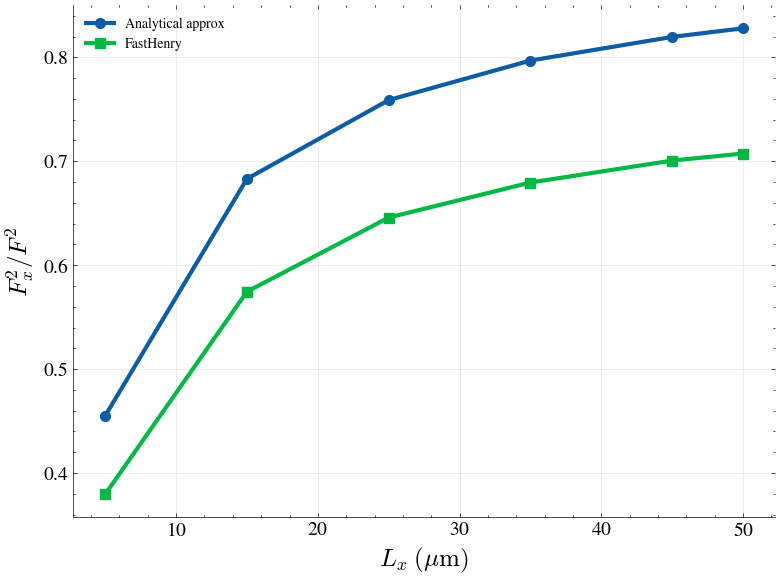

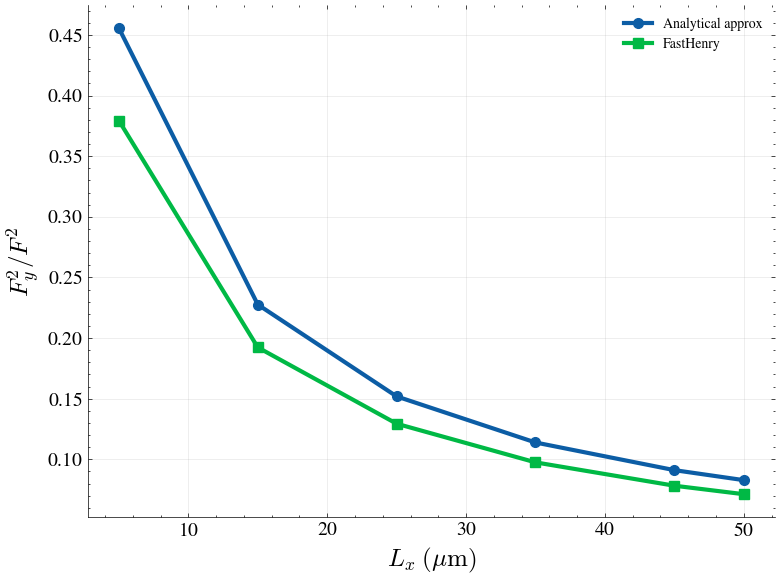

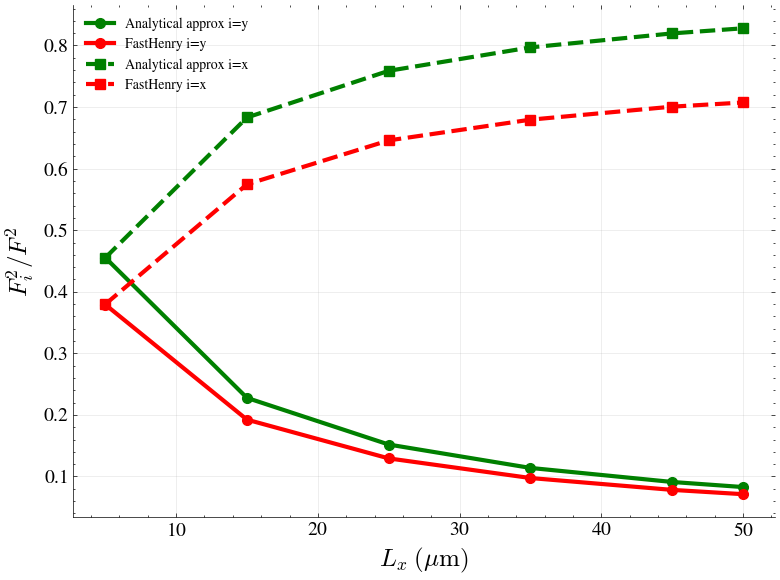

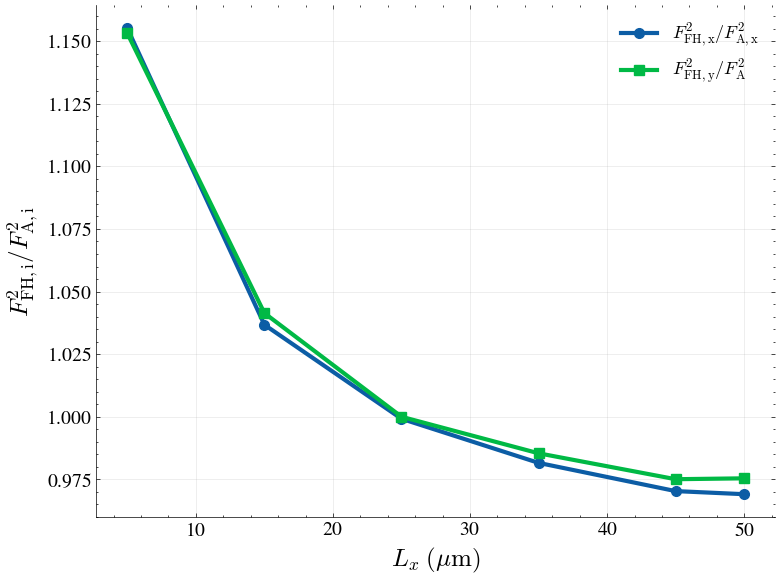

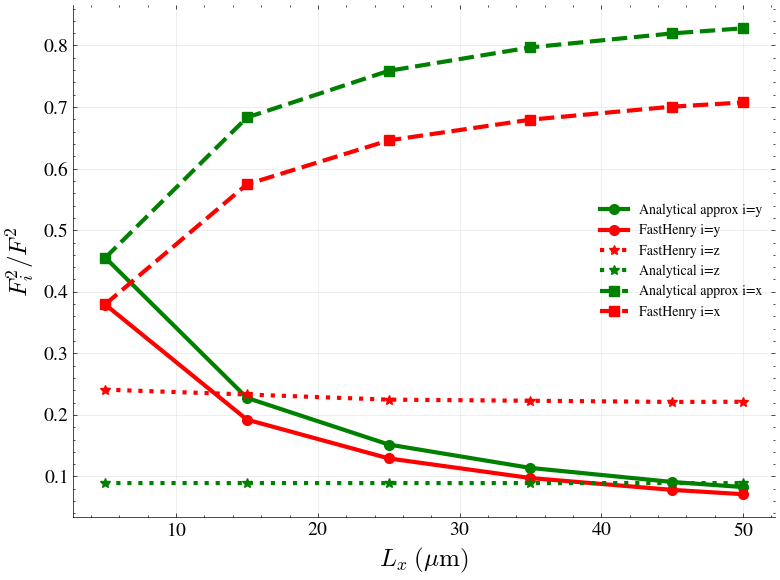

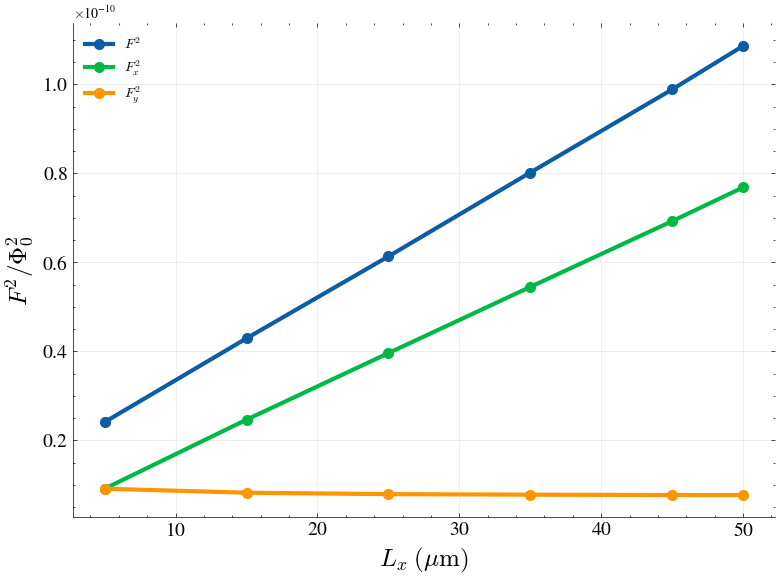

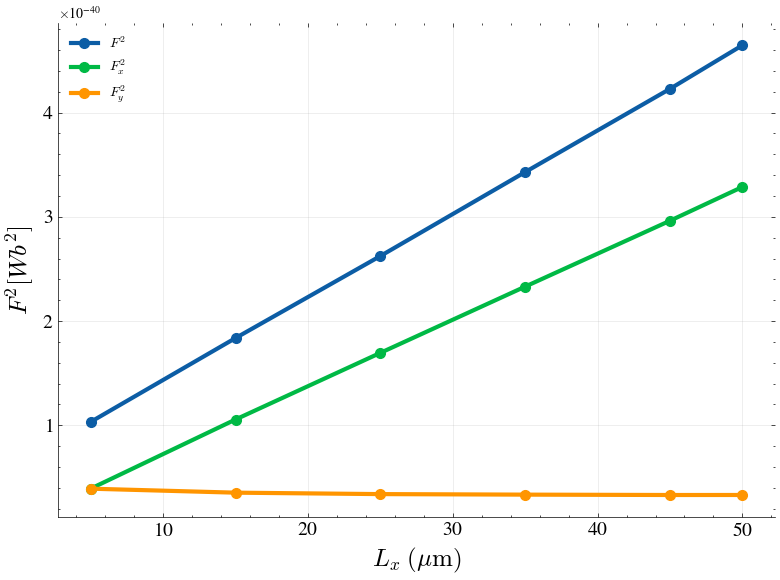

/tmp/ipykernel_1721/823546257.py:644: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


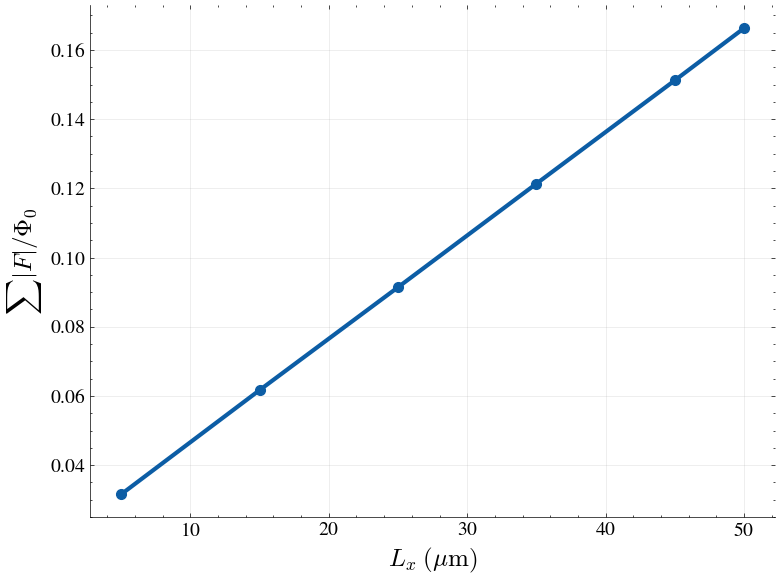

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d, CubicSpline


# ============================================================
# User parameters
# ============================================================

files = [5, 15, 25, 35, 45, 50]   # file names correspond to Lx x Ly, with Ly = 5


# FastHenry cut window
y_min_um = -7.5
y_max_um = -2.5
y_center_um = 0.5 * (y_min_um + y_max_um)

# SC width
W_um = 5.0
W = W_um * um

# Field observation height
Z_um = 0.005
Z_m = Z_um * um

# Monte Carlo / noise settings
sigma_m2 = 5e17
sigma_um2 = sigma_m2 * 1e-12
r_sample = 0.30
rng = np.random.default_rng(1234)

# Flux interpolator grid
Xmin_um = -W_um
Xmax_um = W_um
Nx_flux = 1200
Nu_flux = 7000

# ============================================================
# Analytical superconducting current density
# ============================================================

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_target) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

# SC profile centered at 0
u_sc = np.linspace(-1, 1, Nu_flux)
eps = 1e-10
u_sc[np.abs(u_sc - 1) < eps] = 1 - eps
u_sc[np.abs(u_sc + 1) < eps] = -1 + eps

J_sc = J_SC(u_sc)
y_sc_m = (W / 2) * u_sc

I_sc_check = b * np.trapezoid(J_sc, y_sc_m)
print()
print("Analytical SC profile")
print("---------------------")
print(f"I_SC = {I_sc_check*1e9:.6f} nA")
print()

# ============================================================
# Helper: load and normalize one FastHenry profile
# ============================================================

def load_profile(file_id, y_min_um=-7.5, y_max_um=-2.5):
    d = np.loadtxt(f"files_FH/{file_id}x5_interp.mat")
    x_min_um=-float(file_id)/2-W_um
    x_max_um=-float(file_id)/2
    x_center_um = 0.5 * (x_min_um + x_max_um)

    x_um = d[:, 0] * 1e6
    y_um = d[:, 1] * 1e6

    Jx = d[:, 2]
    Jy = d[:, 3]
    Jz = d[:, 4]

    Jmag_raw = np.sqrt(Jx**2 + Jy**2 + Jz**2)
    #Jmag_raw = d[:, 5]
    Jmag_raw = np.nan_to_num(Jmag_raw, nan=0.0)

    # Restrict y range
    mask_y = (y_um >= y_min_um) & (y_um <= y_max_um)
    mask_x = (x_um >= x_min_um) & (x_um <= x_max_um)

    x1 = x_um[mask_y]
    y1 = y_um[mask_y]
    J1 = Jmag_raw[mask_y]

    x2 = x_um[mask_x]
    y2 = y_um[mask_x]
    J2 = Jmag_raw[mask_x]

    # x slice closest to 0
    x_unique = np.unique(x1)
    x0 = x_unique[np.argmin(np.abs(x_unique))]
    mask_xx = np.isclose(x1, x0)

    y_unique = np.unique(y2)
    y0 = y_unique[np.argmin(np.abs(y_unique))]
    mask_yy = np.isclose(y2, y0)

    print(x0,y0)

    y_cut_um = y1[mask_xx]
    J_cut_raw = J1[mask_xx]

    x_cut_um = x2[mask_yy]
    J_cuty_raw = J2[mask_yy]

    # Sort by y
    order = np.argsort(y_cut_um)
    y_cut_um = y_cut_um[order]
    J_cut_raw = J_cut_raw[order]

    order = np.argsort(x_cut_um)
    x_cut_um = x_cut_um[order]
    J_cuty_raw = J_cuty_raw[order]

    # Center the profile to compare fairly with SC
    y_cut_centered_um = y_cut_um - y_center_um
    y_cut_centered_m = y_cut_centered_um * um

    x_cut_centered_um = x_cut_um - x_center_um
    x_cut_centered_m = x_cut_centered_um * um

    # Current from raw profile: I = b * ∫ J(y) dy
    I_profile = b * np.trapezoid(J_cut_raw, y_cut_um * um)   # A

    scale = I_target / I_profile
    J_cut_norm = J_cut_raw * scale                           # A/m^2
    J_cuty_norm = J_cuty_raw * scale                           # A/m^2

    # For plotting only: A/m^2 -> nA/μm^2
    J_cut_plot = J_cut_norm * 1e-3
    J_cuty_plot = J_cuty_norm * 1e-3

    # Check current in plotted units
    I_check_nA = b_um * np.trapezoid(J_cut_plot, y_cut_um)
    I_check_nAx = b_um * np.trapezoid(J_cuty_plot, x_cut_um)

    print(
        f"{file_id}x5 : "
        f"I_profile = {I_profile*1e9:.6e} nA, "
        f"I_check = {I_check_nA:.6f} nA"
        f"I_check = {I_check_nAx:.6f} nA"
    )

    return {
        "x_um": x_um,
        "y_um": y_cut_um,
        "y_centered_um": y_cut_centered_um,
        "y_centered_m": y_cut_centered_m,
        "x_centered_um": x_cut_centered_um,
        "x_centered_m": x_cut_centered_m,
        "J_norm_SI": J_cut_norm,
        "J_plot": J_cut_plot,
        "J_norm_SIx": J_cuty_norm,
        "J_plotx": J_cuty_plot,
        "I_profile": I_profile,
        "I_check_nA": I_check_nA,
        "I_check_nAx": I_check_nAx
    }

# ============================================================
# Flux calculation from an arbitrary normalized current profile
# ============================================================

def compute_flux_from_profile(y_m, J_m2, I_reference, X_vals_um, Z_m, Nu=7000):
    """
    y_m: coordinate across the strip in meters (centered)
    J_m2: normalized current density in A/m^2
    I_reference: total current in A used in normalization
    X_vals_um: observation x positions in micrometers
    Z_m: observation height in meters
    """
    X_vals_m = np.asarray(X_vals_um) * um

    J_interp = interp1d(
        y_m,
        J_m2,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    y_grid = np.linspace(y_m.min(), y_m.max(), Nu)
    J_y = J_interp(y_grid)

    # Ratio has units 1/m^2
    J_ratio = J_y / I_reference

    dx = y_grid[:, None] - X_vals_m[None, :]

    log_term = np.log(
        (dx**2 + Z_m**2) /
        (dx**2 + (Z_m + b)**2)
    )

    atan_term = (
        np.arctan2(Z_m + b, dx) -
        np.arctan2(Z_m, dx)
    )

    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        y_grid,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        y_grid,
        axis=0
    )

    Fx = -(g * mu_s * mu_0 / (4 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 / (2 * np.pi)) * integral_fz

    return Fx, Fz

# ============================================================
# Flux interpolator for fast Monte Carlo evaluation
# ============================================================

class FluxInterpolator:
    def __init__(
        self,
        y_m,
        J_m2,
        I_reference,
        Z_m,
        Xmin_um=-W_um,
        Xmax_um=W_um,
        Nx=Nx_flux,
        Nu=Nu_flux
    ):
        self.X_grid_um = np.linspace(Xmin_um, Xmax_um, Nx)

        Fx_grid, Fz_grid = compute_flux_from_profile(
            y_m=y_m,
            J_m2=J_m2,
            I_reference=I_reference,
            X_vals_um=self.X_grid_um,
            Z_m=Z_m,
            Nu=Nu
        )

        # Dimensionless fluxes normalized by phi0
        self.Fx_spline = CubicSpline(self.X_grid_um, Fx_grid / phi0)
        self.Fz_spline = CubicSpline(self.X_grid_um, Fz_grid / phi0)

    def __call__(self, X_um):
        X_um = np.asarray(X_um)
        return self.Fx_spline(X_um), self.Fz_spline(X_um)

# ============================================================
# Build SC and FastHenry flux interpolators
# ============================================================

flux_fun_SC = FluxInterpolator(
    y_m=y_sc_m,
    J_m2=J_sc,
    I_reference=I_target,
    Z_m=Z_m
)

profile_data = {}
flux_fun_mag_x = {}
flux_fun_mag_y = {}

for n in files:
    data = load_profile(n, y_min_um=y_min_um, y_max_um=y_max_um)
    profile_data[n] = data

    flux_fun_mag_x[n] = FluxInterpolator(
        y_m=data["y_centered_m"],
        J_m2=data["J_norm_SI"],
        I_reference=data["I_check_nA"]*1e-9,
        Z_m=Z_m
    )
    flux_fun_mag_y[n] = FluxInterpolator(
        y_m=data["x_centered_m"],
        J_m2=data["J_norm_SIx"],
        I_reference=data["I_check_nAx"]*1e-9,
        Z_m=Z_m
    )

# ============================================================
# Monte Carlo comparison for each file
# ============================================================

results_noise = []

for lx in files:
    ly = 5

    Ax = lx * W_um
    Ay = ly * W_um

    Nx = int(2 * Ax * sigma_um2)
    Ny = int(2 * Ay * sigma_um2)

    # If you want to avoid huge arrays, cap them here if needed:
    # Nx = min(Nx, 2_000_000)
    # Ny = min(Ny, 2_000_000)

    # Random positions in micrometers
    Xj_um = rng.uniform(-W_um / 2, W_um / 2, Ny)
    Yj_um = rng.uniform(-W_um / 2, W_um / 2, Nx)

    nY = max(1, int(r_sample * Ny))
    nX = max(1, int(r_sample * Nx))
    scale = 1 / r_sample

    # SC
    Fx_ySC, Fz_ySC = flux_fun_SC(Xj_um[:nY])
    Fy_xSC, Fz_xSC = flux_fun_SC(Yj_um[:nX])

    # FastHenry
    Fx_ymag, Fz_ymag = flux_fun_mag_y[lx](Xj_um[:nY])
    Fy_xmag, Fz_xmag = flux_fun_mag_x[lx](Yj_um[:nX])

    Fy=(Fx_ymag**2).sum()
    Fx=(Fy_xmag**2).sum()
    Fz1 = (Fz_xmag**2).sum()
    Fz2 = (Fz_ymag**2).sum()
    Fz=Fz1+Fz2
    F_flux = np.sqrt(Fx_ymag**2+Fz_ymag**2).sum()*scale+np.sqrt(Fy_xmag**2+Fz_xmag**2).sum()*scale

    Fy_SC=(Fx_ySC**2).sum()
    Fx_SC=(Fy_xSC**2).sum()
    Fz1_SC = (Fz_xSC**2).sum()
    Fz2_SC = (Fz_ySC**2).sum()
    Fz_SC=Fz1_SC+Fz2_SC

    # Noise-like sums
    total_SC = Fz2_SC*scale + Fz1_SC*scale + Fx_SC*scale + Fy_SC*scale
    total_FH = Fz2*scale + Fz1*scale + Fx*scale + Fy*scale

    # Requested Sx and Sy pieces
    Sx_SC = Fx_SC * scale
    Sx_MAG = Fx * scale

    Sy_SC = Fy_SC * scale
    Sy_MAG = Fy * scale

    Sz_SC = Fz_SC * scale
    Sz_MAG = Fz * scale

    xy_sc = Fx_SC / Fy_SC
    zx_sc = Fz_SC/Fx_SC#(Fz_xSC**2).sum() / Fx_SC
    zy_sc = Fz_SC/ Fy_SC

    xy_mag = Fx / Fy
    zx_mag = Fz/ Fx#(Fz_xmag**2).sum() / Fx
    zy_mag = Fz/Fy#(Fz_ymag**2).sum() / Fy

    results_noise.append({
        "lx": lx,
        "ly": ly,

        "SC": total_SC,
        "MAG": total_FH,
        "ratio": total_SC / total_FH,
        "flux": F_flux,

        "Sx_SC": Sx_SC,
        "Sx_MAG": Sx_MAG,
        "Sy_SC": Sy_SC,
        "Sy_MAG": Sy_MAG,
        "Sz_SC": Sz_SC,
        "Sz_MAG": Sz_MAG,

        "xy_SC": xy_sc,
        "zx_SC": zx_sc,
        "zy_SC": zy_sc,

        "xy_MAG": xy_mag,
        "zx_MAG": zx_mag,
        "zy_MAG": zy_mag,
    })

    print(f"{lx} x {ly}")
    print("-----------------------")
    print(total_SC)
    print(total_FH)
    print("-----------------------")
    print(Sx_SC)
    print(Sy_SC)
    print(xy_sc)
    print(zx_sc)
    print(zy_sc)
    print("-----------------------")
    print(Sx_MAG)
    print(Sy_MAG)
    print(xy_mag)
    print(zx_mag)
    print(zy_mag)
    print("-----------------------")
    print("x comparison", Sx_MAG / Sx_SC)
    print("y comparison", Sy_MAG / Sy_SC)
    print("MAG/SC", total_FH / total_SC)
    print()

# ============================================================
# Summary arrays
# ============================================================

lx_vals = np.array([r["lx"] for r in results_noise])

ratio_vals = np.array([r["ratio"] for r in results_noise])
mag_vals = np.array([r["MAG"] for r in results_noise])
fx_vals = np.array([r["Sx_MAG"] for r in results_noise])
fy_vals = np.array([r["Sy_MAG"] for r in results_noise])

xy_sc_vals = np.array([r["xy_SC"] for r in results_noise])
xy_mag_vals = np.array([r["xy_MAG"] for r in results_noise])

zx_sc_vals = np.array([r["zx_SC"] for r in results_noise])
zx_mag_vals = np.array([r["zx_MAG"] for r in results_noise])

zy_sc_vals = np.array([r["zy_SC"] for r in results_noise])
zy_mag_vals = np.array([r["zy_MAG"] for r in results_noise])

flux = np.array([r["flux"] for r in results_noise])

redx_sc_vals = np.array([r["Sx_SC"] / r["SC"] for r in results_noise])
redx_mag_vals = np.array([r["Sx_MAG"] / r["MAG"] for r in results_noise])

redy_sc_vals = np.array([r["Sy_SC"] / r["SC"] for r in results_noise])
redy_mag_vals = np.array([r["Sy_MAG"] / r["MAG"] for r in results_noise])

redz_sc_vals = np.array([r["Sz_SC"] / r["SC"] for r in results_noise])
redz_mag_vals = np.array([r["Sz_MAG"] / r["MAG"] for r in results_noise])

Sx_ratio = np.array([r["Sx_MAG"] / r["Sx_SC"] for r in results_noise])
Sy_ratio = np.array([r["Sy_MAG"] / r["Sy_SC"] for r in results_noise])

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, ratio_vals, "-o", lw=3, ms=7)
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_{\rm A}/F^2_{\rm FH}$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, xy_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, xy_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_y/F^2_x$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, zx_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, zx_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_z/F^2_y$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, zy_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, zy_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_z/F^2_x$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, redx_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, redx_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_x/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, redy_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, redy_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_y/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, redy_sc_vals, "o-", color="green", lw=3, ms=7, label="Analytical approx i=y")
plt.plot(lx_vals, redy_mag_vals, "o-", color="red", lw=3, ms=7, label="FastHenry i=y")
plt.plot(lx_vals, redx_sc_vals, "s--", color="green", lw=3, ms=7, label="Analytical approx i=x")
plt.plot(lx_vals, redx_mag_vals, "s--", color="red", lw=3, ms=7, label="FastHenry i=x")

plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_i/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# New requested comparison plots
plt.figure(figsize=(8, 6))
plt.plot(lx_vals, Sx_ratio, "-o", lw=3, ms=7, label=r"$F_{\rm FH,x}^2/F_{\rm A,x}^2$")
plt.plot(lx_vals, Sy_ratio, "-s", lw=3, ms=7, label=r"$F_{\rm FH,y}^2/F_{\rm A}^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_{\rm FH,i}^2/F_{\rm A,i}^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, redy_sc_vals, "o-", color="green", lw=3, ms=7, label="Analytical approx i=y")
plt.plot(lx_vals, redy_mag_vals, "o-", color="red", lw=3, ms=7, label="FastHenry i=y")
plt.plot(lx_vals, redz_mag_vals, "*:", color="red", lw=3, ms=7, label="FastHenry i=z")
plt.plot(lx_vals, redz_sc_vals, "*:", color="green", lw=3, ms=7, label="Analytical i=z")
plt.plot(lx_vals, redx_sc_vals, "s--", color="green", lw=3, ms=7, label="Analytical approx i=x")
plt.plot(lx_vals, redx_mag_vals, "s--", color="red", lw=3, ms=7, label="FastHenry i=x")

plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_i/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, mag_vals, "-o", lw=3, ms=7, label=r"$F^2$")
plt.plot(lx_vals, fx_vals, "-o", lw=3, ms=7, label=r"$F_x^2$")
plt.plot(lx_vals, fy_vals, "-o", lw=3, ms=7, label=r"$F_y^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2/\Phi_0^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, (3.3920534187343736e-40*mag_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F^2$")
plt.plot(lx_vals, (3.3920534187343736e-40*fx_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F_x^2$")
plt.plot(lx_vals, (3.3920534187343736e-40*fy_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F_y^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2[Wb^2]$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lx_vals, flux, "-o", lw=3, ms=7)
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$\sum|F|/\Phi_0$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

m0 shape = (120, 120, 3)
B shape = (120, 120, 3)
mask shape = (120, 120)
Saved plot to m_snapshots_loop.png


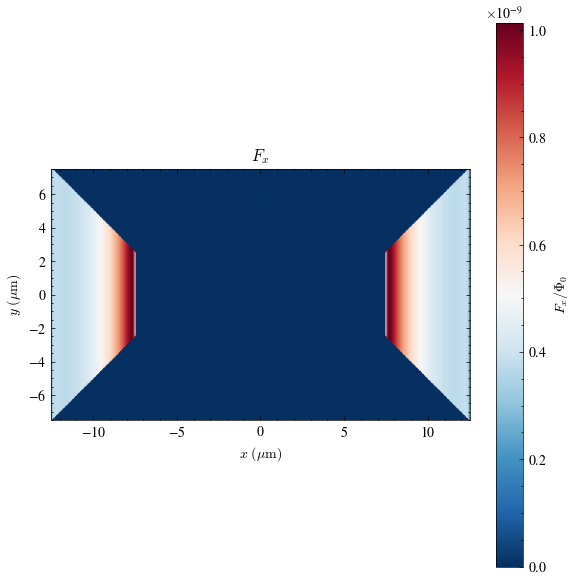

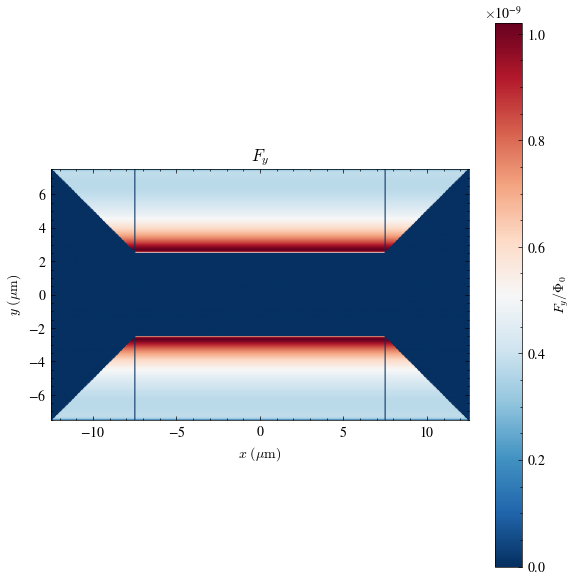

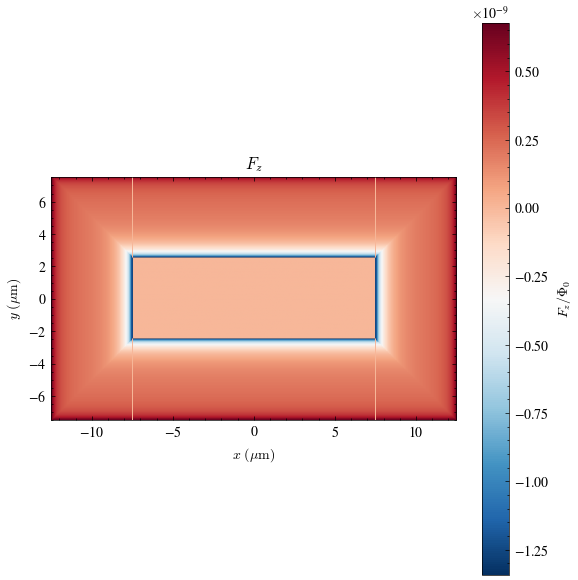

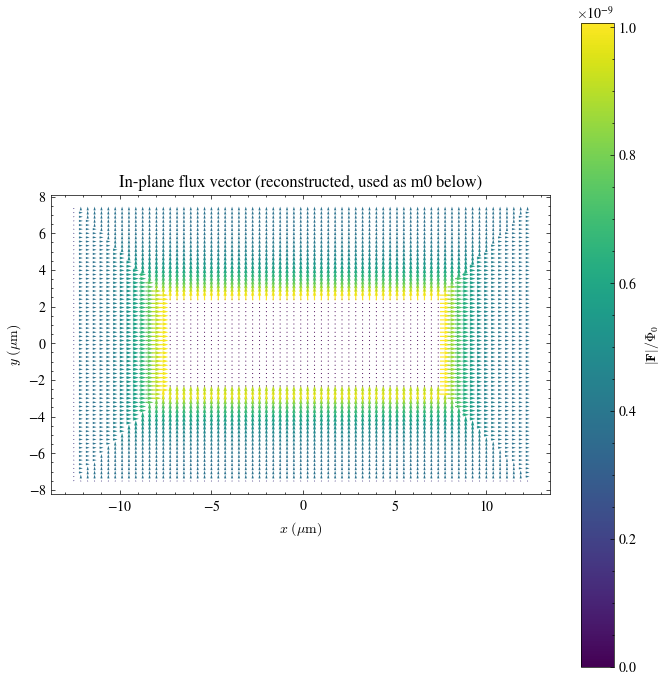

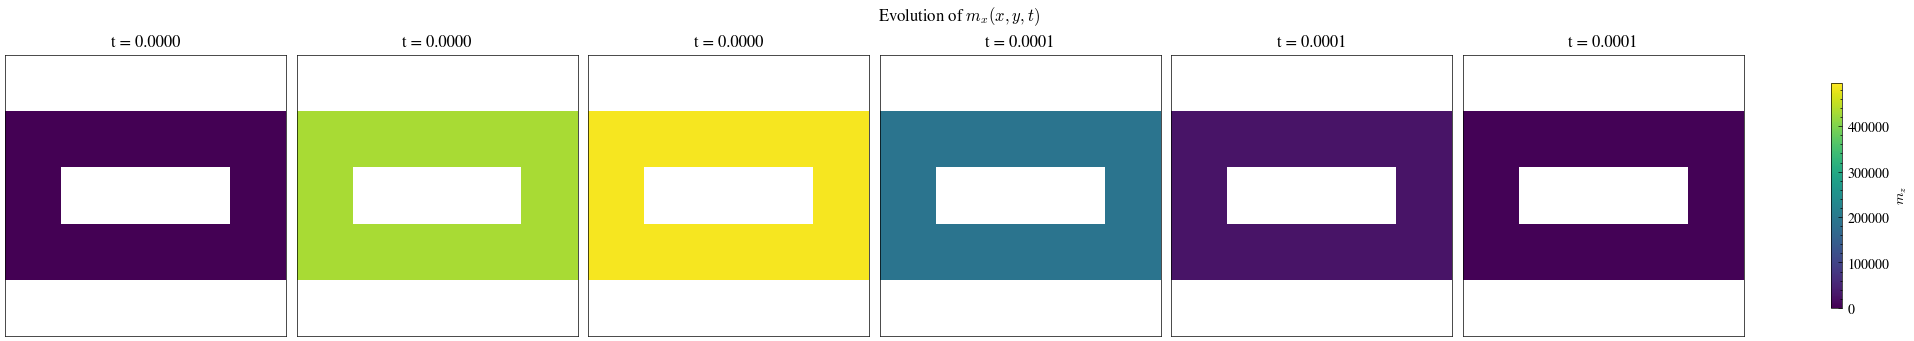

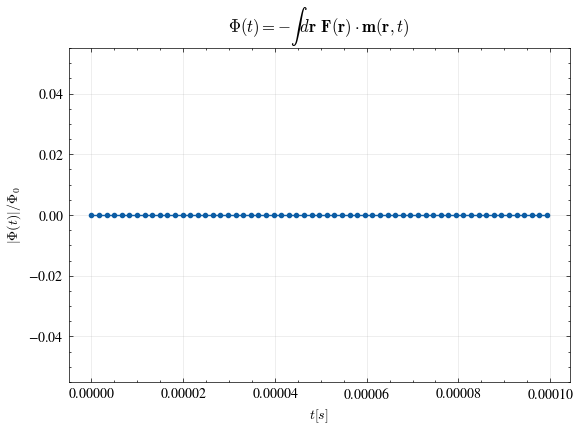

In [ ]:
# ============================================================
# PART 1: Reconstruct 2D flux field from strip profiles
# (unchanged from your original code — produces Fx, Fy, Fz
#  on grid X, Y with shape (Ny, Nx), meshgrid(x, y) 'xy' indexing)
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator

sigmam2=5e17#meters^-2
sigma=sigmam2*1e-12#micrometers^-2

W_um=5

# choose which geometry
Lx = 15          # one of the values in "files"
Ly = 5           # fixed

halfLx = Lx / 2
halfLy = Ly / 2

strip_width = W_um

# plotting domain
margin = W_um

Nx_flux, Ny_flux = 401, 401

x_flux = np.linspace(-halfLx - margin, halfLx + margin, Nx_flux)
y_flux = np.linspace(-halfLy - margin, halfLy + margin, Ny_flux)

X_flux, Y_flux = np.meshgrid(x_flux, y_flux)  # shape (Ny_flux, Nx_flux), 'xy' indexing

Fx = np.zeros_like(X_flux)
Fy = np.zeros_like(X_flux)
Fz = np.zeros_like(X_flux)

# ============================================================
# Masks defining the four strips
# (corners intentionally ignored)
# ============================================================

corner = strip_width / 2

mask_left = (
    (np.abs(X_flux + halfLx + strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_right = (
    (np.abs(X_flux - halfLx - strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_bottom = (
    (np.abs(Y_flux + halfLy + strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

mask_top = (
    (np.abs(Y_flux - halfLy - strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

# top and right must have a flip because current flows against the convention
# ============================================================
# LEFT ARM
# ============================================================

d = X_flux[mask_left] + halfLx + W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_left] = Fx_tmp
Fz[mask_left] = Fz_tmp

# ============================================================
# RIGHT ARM
# ============================================================

d = X_flux[mask_right] - halfLx - W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_right] = np.flip(Fx_tmp)
Fz[mask_right] = np.flip(Fz_tmp)

# ============================================================
# BOTTOM ARM
# ============================================================

d = Y_flux[mask_bottom] + halfLy + W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_bottom] = Fy_tmp
Fz[mask_bottom] = Fz_tmp

# ============================================================
# TOP ARM
# ============================================================

d = Y_flux[mask_top] - halfLy - W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_top] = np.flip(Fy_tmp)
Fz[mask_top] = np.flip(Fz_tmp)

# ============================================================
# Fill the four corners by interpolating from strip data
# ============================================================

mask_corner_bl = (X_flux < -halfLx) & (Y_flux < -halfLy)
mask_corner_br = (X_flux > halfLx) & (Y_flux < -halfLy)
mask_corner_tl = (X_flux < -halfLx) & (Y_flux > halfLy)
mask_corner_tr = (X_flux > halfLx) & (Y_flux > halfLy)

corner_masks = {
    "bottom_left": mask_corner_bl,
    "bottom_right": mask_corner_br,
    "top_left": mask_corner_tl,
    "top_right": mask_corner_tr,
}

data_mask = mask_left | mask_right | mask_top | mask_bottom
pts_known = np.column_stack([X_flux[data_mask], Y_flux[data_mask]])

for name, cmask in corner_masks.items():
    if not np.any(cmask):
        continue
    pts_query = np.column_stack([X_flux[cmask], Y_flux[cmask]])
    for field, arr in (("Fx", Fx), ("Fy", Fy), ("Fz", Fz)):
        vals_known = arr[data_mask]
        interp_vals = griddata(pts_known, vals_known, pts_query, method="nearest")
        nan_mask = np.isnan(interp_vals)
        if np.any(nan_mask):
            interp_vals[nan_mask] = griddata(
                pts_known, vals_known, pts_query[nan_mask], method="nearest"
            )
        arr[cmask] = interp_vals

# (Optional) diagnostic plots of Fx, Fy, Fz and the in-plane vector field
# — kept exactly as before, just wrapped so they don't block execution.

def _plot_field(field, name, symbol):
    plt.figure(figsize=(6, 6))
    plt.imshow(
        field, origin="lower",
        extent=[x_flux.min(), x_flux.max(), y_flux.min(), y_flux.max()],
        cmap="RdBu_r", aspect="equal",
    )
    plt.colorbar(label=rf"${symbol}/\Phi_0$")
    plt.xlabel(r"$x\ (\mu{\rm m})$")
    plt.ylabel(r"$y\ (\mu{\rm m})$")
    plt.title(rf"${symbol}$")
    plt.tight_layout()

_plot_field(Fx, "Fx", "F_x")
_plot_field(Fy, "Fy", "F_y")
_plot_field(Fz, "Fz", "F_z")

step = 6
plt.figure(figsize=(7, 7))
plt.quiver(
    X_flux[::step, ::step], Y_flux[::step, ::step],
    Fx[::step, ::step], Fy[::step, ::step],
    np.sqrt(Fx[::step, ::step] ** 2 + Fy[::step, ::step] ** 2),
    cmap="viridis", pivot="mid",
)
plt.gca().set_aspect("equal")
plt.xlabel(r"$x\ (\mu{\rm m})$")
plt.ylabel(r"$y\ (\mu{\rm m})$")
plt.title("In-plane flux vector (reconstructed, used as m0 below)")
plt.colorbar(label=r"$|\mathbf{F}|/\Phi_0$")
plt.tight_layout()


# ============================================================
# PART 2: 2D vector diffusion on a rectangular loop,
# initialized with m0 = (Fx, Fy, Fz) from Part 1
# ============================================================

from diffusion2d_complete import (
    build_rectangular_loop_mask,
    solve_diffusion_2d_loop,
    max_stable_dt,
)

Nx, Ny = 120, 120

# domain_size is set from the flux grid itself so both fields live on
# compatible (µm) coordinates and the interpolation in Part 1 -> Part 2
# actually overlaps.
domain_size = 2 * max(halfLx + margin, halfLy + margin)

x = np.linspace(-domain_size / 2, domain_size / 2, Nx)
y = np.linspace(-domain_size / 2, domain_size / 2, Ny)
dx, dy = x[1] - x[0], y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing="ij")  # shape (Nx, Ny), 'ij' indexing

Lx_outer, Ly_outer = Lx + 2 * W_um, Ly + 2 * W_um
mask = build_rectangular_loop_mask(X, Y, Lx_outer, Ly_outer, W_um)


# ------------------------------------------------------------
# Build m0 by interpolating the reconstructed (Fx, Fy, Fz) field
# from Part 1's grid (X_flux, Y_flux) onto Part 2's grid (X, Y).
#
# Part 1 used meshgrid(x_flux, y_flux) with default 'xy' indexing,
# so Fx/Fy/Fz have shape (Ny_flux, Nx_flux) and are indexed [row=y, col=x].
# RegularGridInterpolator wants strictly increasing axes in the order
# matching the array's own indexing, so we build it as (y_flux, x_flux) -> value,
# then query at each (X, Y) point of Part 2's grid, which uses 'ij' indexing
# (shape (Nx, Ny), indexed [x, y]).
# ------------------------------------------------------------

def interp_to_target_grid(field_xy_indexed, y_source, x_source, X_target, Y_target):
    """field_xy_indexed: array of shape (len(y_source), len(x_source))."""
    interpolator = RegularGridInterpolator(
        (y_source, x_source), field_xy_indexed,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    query_pts = np.column_stack([Y_target.ravel(), X_target.ravel()])
    return interpolator(query_pts).reshape(X_target.shape)

Fx_on_target = interp_to_target_grid(Fx, y_flux, x_flux, X, Y)
Fy_on_target = interp_to_target_grid(Fy, y_flux, x_flux, X, Y)
Fz_on_target = interp_to_target_grid(Fz, y_flux, x_flux, X, Y)
Fx_on_target = Fx_on_target*phi0*1e12#um units
Fy_on_target = Fy_on_target*phi0*1e12
Fz_on_target = Fz_on_target*phi0*1e12

B0 = 1000.0            # Gauss
B0 *= 1e-4            # Tesla

R_cm = 1.0

X_cm = X * 1e-4
Y_cm = Y * 1e-4

Bext_y = B0 * (
    (1.0 + (Y_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (Y_cm/R_cm + 0.5)**2)**(-1.5)
)

Bext_x = B0 * (
    (1.0 + (X_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (X_cm/R_cm + 0.5)**2)**(-1.5)
)


F = np.zeros((Nx, Ny, 3))
F[..., 0] = Fx_on_target#0.
F[..., 1] = Fy_on_target
F[..., 2] = Fz_on_target

Fmag=np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)

m0 = np.zeros((Nx, Ny, 3))
m0[..., 0] = 0#1*Fx_on_target#np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)
m0[..., 1] = 0#1*Fy_on_target#Fy_on_target
m0[..., 2] = 0#1*Fz_on_target#Fz_on_target
#m0[..., 0]=0.1

mu_B_nAum2 = 9.2740100657e-24 * 1e21
Ip_nA=6.3
B_static = np.zeros((Nx, Ny, 3))
# B_static[..., 0] = Fx_on_target*Ip_nA/mu_B_nAum2+Bext_x#0.
# B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.#+0.002
# B_static[..., 2] = Fz_on_target*Ip_nA/mu_B_nAum2

B_static[..., 0] = 0.2#Bext_x#0.
B_static[..., 1] = 0.#+0.002
B_static[..., 2] = 0.

#B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.002

Bmag=np.sqrt(B_static[..., 0]**2+B_static[..., 1]**2+B_static[..., 2]**2)
T1=10e-6*1
a=1.5
TD=T1/1
D, T = a**2/TD, 20e-3

# zero out m0 outside the loop material, so only the mask region carries
# the reconstructed field into the diffusion solve
m0[~mask, :] = 0.0

# NOTE: this replaces the original hot_spot initialization:
#   m0 = np.zeros((Nx, Ny, 3))
#   hot_spot = mask & (X < -Lx / 2 + W) & (np.abs(Y) < Ly / 4)
#   m0[hot_spot, 2] = 1.0
# If you want to keep a hot-spot seed *on top of* the reconstructed field,
# uncomment below:
# hot_spot = mask & (X < -Lx / 2 + W) & (np.abs(Y) < Ly / 4)
# m0[hot_spot, 2] += 1.0




dt = max_stable_dt(D, dx, dy, Bmax=np.max(Bmag), safety=.9)/4
#dt=1e-6

save_every = 150
n_steps = int(10*T1/dt)#11000

def B_func(t):
    return B_static*np.heaviside(-t+5*T1,0)

print("m0 shape =", m0.shape)
print("B shape =", B_func(0).shape)
print("mask shape =", mask.shape)

times, m_hist = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, dt, n_steps, save_every=save_every, T1=T1, gamma=1.76e11, diffusion=False, relaxation=True, N_ramp=int(T1/dt)
)

times, m_hist_both = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, dt, n_steps, save_every=save_every, T1=T1, gamma=1.76e11, diffusion=True, relaxation=False, N_ramp=int(T1/dt)
)

times, m_hist_dif = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, dt, n_steps, save_every=save_every, T1=T1, gamma=1.76e11, diffusion=True, relaxation=False, N_ramp=int(T1/dt)
)

# mask out non-material points as NaN so they show blank in the plot
m_hist_plot = m_hist.copy()*sigma_um2
m_hist_plot[:, ~mask, :] = np.nan

component = 0
n_panels = 6
idxs = np.linspace(0, len(times) - 1, n_panels).astype(int)

fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3.4), constrained_layout=True)

vmin = np.nanmin(m_hist_plot[..., component])
vmax = np.nanmax(m_hist_plot[..., component])

for ax, k in zip(axes, idxs):
    im = ax.pcolormesh(X, Y, m_hist_plot[k, ..., component], cmap="viridis",
                        vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(f"t = {times[k]:.4f}")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label=r"$m_z$")
fig.suptitle(r"Evolution of $m_x(x,y,t)$")

# fig.savefig("/mnt/user-data/outputs/m_snapshots_loop.png", dpi=150)
print("Saved plot to m_snapshots_loop.png")

# ============================================================
# PART 3: phi(t) = -\int dr  m0(r) . m(r, t)
# integral taken only over the "zone with data", i.e. the loop
# material defined by `mask` (m0 is zero outside it anyway, but
# we mask explicitly for clarity and to set the area element).
# ============================================================

cell_area = dx * dy

# dot product m0(r) . m(r,t) at every grid point and every saved time,
# broadcasting m0 (Nx,Ny,3) against m_hist (n_times,Nx,Ny,3)
dot = np.sum(F[None, ...] * m_hist, axis=-1)*sigma_um2  # shape (n_times, Nx, Ny)
dot_both = np.sum(F[None, ...] * m_hist_both, axis=-1)*sigma_um2  # shape (n_times, Nx, Ny)

# restrict the integral to the masked (data) region
dot_masked = np.where(mask[None, ...], dot, 0.0)
dot_masked_both = np.where(mask[None, ...], dot_both, 0.0)

phi = -cell_area * np.sum(dot_masked, axis=(1, 2))*1e-12 / phi0  # shape (n_times,)
phi_both = -cell_area * np.sum(dot_masked_both, axis=(1, 2))*1e-12 / phi0  # shape (n_times,)

plt.figure(figsize=(6, 4.5))
plt.plot(times, np.abs(phi_both), marker="o", ms=3)
plt.xlabel(r"$t[s]$")
plt.ylabel(r"$|\Phi(t)|/\Phi_0$")
plt.title(r"$\Phi(t) = -\int d\mathbf{r}\ \mathbf{F}(\mathbf{r})\cdot\mathbf{m}(\mathbf{r},t)$")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Equilibium magnetization

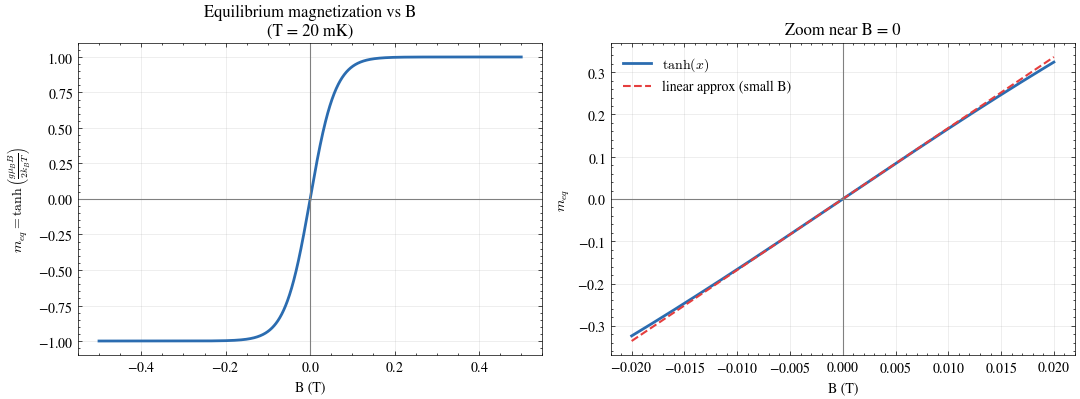

x(B0=0.1T) = 1.6792845390645992   m_eq(B0) = 0.9327686465638352


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_B = 9.2740100783e-24
k_B  = 1.380649e-23
g = 1.0

T = 20e-3  # K, matches your test

B = np.linspace(-0.5, 0.5, 2000)  # Tesla
x = g * mu_B * B / (2 * k_B * T)
m_eq = np.tanh(x)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Full range
axes[0].plot(B, m_eq, lw=2, color="#2b6cb0")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].axvline(0, color="gray", lw=0.8)
axes[0].set_xlabel("B (T)")
axes[0].set_ylabel(r"$m_{eq} = \tanh\left(\frac{g\mu_B B}{2k_BT}\right)$")
axes[0].set_title(f"Equilibrium magnetization vs B\n(T = {T*1e3:.0f} mK)")
axes[0].grid(alpha=0.3)

# Zoom near B=0, with linear approx overlay
B_small = np.linspace(-0.02, 0.02, 500)
x_small = g * mu_B * B_small / (2 * k_B * T)
m_eq_small = np.tanh(x_small)
linear_approx = x_small  # tanh(x) ~ x for small x

axes[1].plot(B_small, m_eq_small, lw=2, color="#2b6cb0", label=r"$\tanh(x)$")
axes[1].plot(B_small, linear_approx, "--", lw=1.5, color="#e53e3e", label="linear approx (small B)")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_xlabel("B (T)")
axes[1].set_ylabel(r"$m_{eq}$")
axes[1].set_title("Zoom near B = 0")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("meq_vs_B.png", dpi=140)
plt.show()

# Report the B0=0.1 T point used in your test
B0 = 0.1
x0 = g*mu_B*B0/(2*k_B*T)
print("x(B0=0.1T) =", x0, "  m_eq(B0) =", np.tanh(x0))

# fields

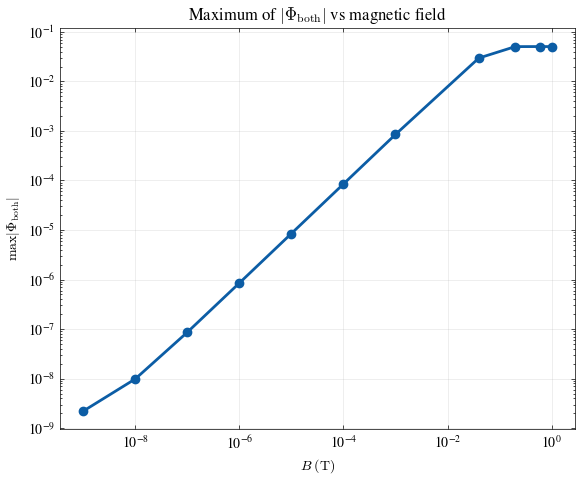

In [ ]:
# --------------------------------------------------
# Maximum of phi_both vs magnetic field
# --------------------------------------------------

B = []
phi_max = []

for d in datasets:
    B.append(d["B"])
    phi_max.append(np.max(d["both"]))

B = np.array(B)
phi_max = np.array(phi_max)

plt.figure(figsize=(6,5))

plt.plot(B, phi_max, "o-", lw=2, ms=6)

plt.xscale("log")      # remove if you prefer a linear B axis
plt.yscale("log")      # remove if you prefer a linear phi axis

plt.xlabel(r"$B\;(\mathrm{T})$")
plt.ylabel(r"$\max |\Phi_{\mathrm{both}}|$")
plt.title(r"Maximum of $|\Phi_{\mathrm{both}}|$ vs magnetic field")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gradient

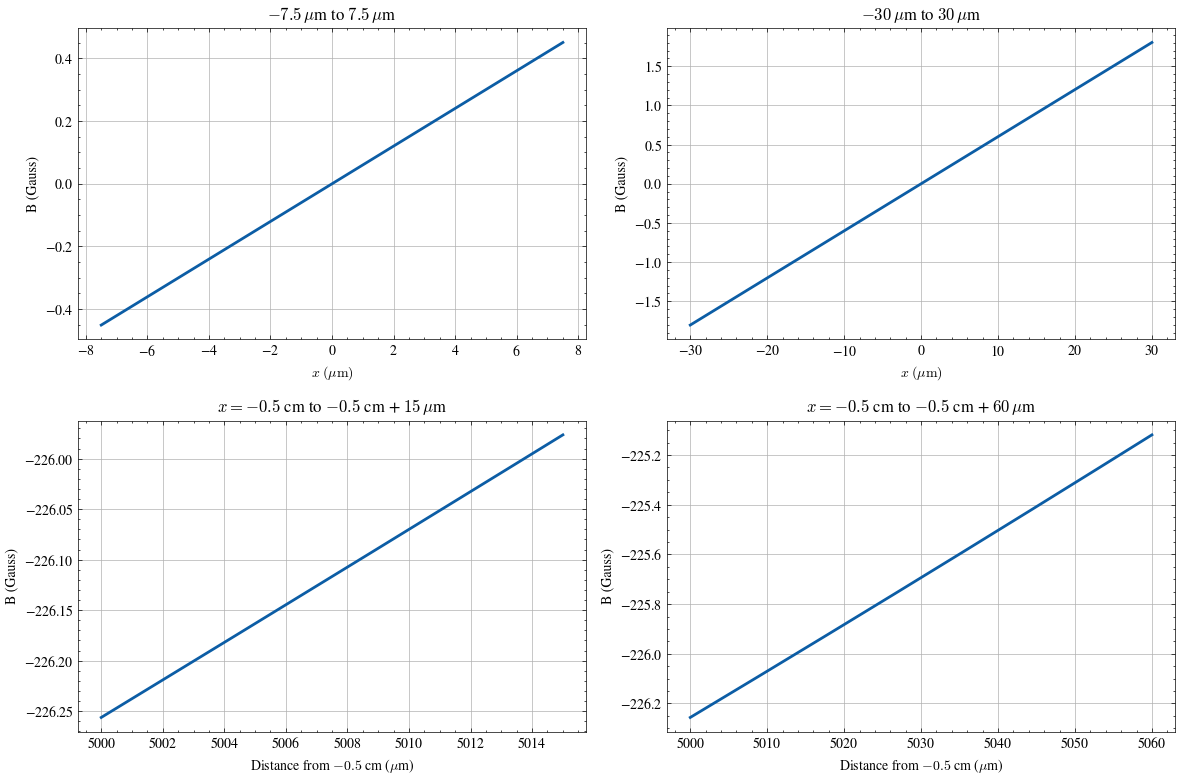

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
B0 = 350.0      # Gauss
R = 1.0         # cm

# Magnetic field function
def B(x):
    """
    x in cm
    returns B in Gauss
    """
    u = x / R
    return B0 * (
        (1 + (u - 0.5)**2)**(-1.5)
        - (1 + (u + 0.5)**2)**(-1.5)
    )

# Conversion factors
um_to_cm = 1e-4

# -----------------------------
# Plot settings
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

# --------------------------------------------------
# 1) Zoom: -7.5 um to 7.5 um
# --------------------------------------------------
x1_um = np.linspace(-7.5, 7.5, 2000)
x1_cm = x1_um * um_to_cm

axs[0].plot(x1_um, B(x1_cm), lw=2)
axs[0].set_title(r"$-7.5\,\mu$m to $7.5\,\mu$m")
axs[0].set_xlabel(r"$x\;(\mu\mathrm{m})$")
axs[0].set_ylabel("B (Gauss)")
axs[0].grid(True)

# --------------------------------------------------
# 2) Zoom: -30 um to 30 um
# --------------------------------------------------
x2_um = np.linspace(-30, 30, 3000)
x2_cm = x2_um * um_to_cm

axs[1].plot(x2_um, B(x2_cm), lw=2)
axs[1].set_title(r"$-30\,\mu$m to $30\,\mu$m")
axs[1].set_xlabel(r"$x\;(\mu\mathrm{m})$")
axs[1].set_ylabel("B (Gauss)")
axs[1].grid(True)

# --------------------------------------------------
# 3) Around x=-1 cm, extending 15 um to the right
# --------------------------------------------------
x3_cm = np.linspace(-.5, -.5 + 15*um_to_cm, 3000)

axs[2].plot((x3_cm + 1.0)/um_to_cm, B(x3_cm), lw=2)
axs[2].set_title(r"$x=-0.5$ cm to $-0.5$ cm + $15\,\mu$m")
axs[2].set_xlabel(r"Distance from $-0.5$ cm ($\mu$m)")
axs[2].set_ylabel("B (Gauss)")
axs[2].grid(True)

# --------------------------------------------------
# 4) Around x=-1 cm, extending 60 um to the right
# --------------------------------------------------
x4_cm = np.linspace(-.5, -.5 + 60*um_to_cm, 4000)

axs[3].plot((x4_cm + 1.0)/um_to_cm, B(x4_cm), lw=2)
axs[3].set_title(r"$x=-0.5$ cm to $-0.5$ cm + $60\,\mu$m")
axs[3].set_xlabel(r"Distance from $-0.5$ cm ($\mu$m)")
axs[3].set_ylabel("B (Gauss)")
axs[3].grid(True)

plt.tight_layout()
plt.show()

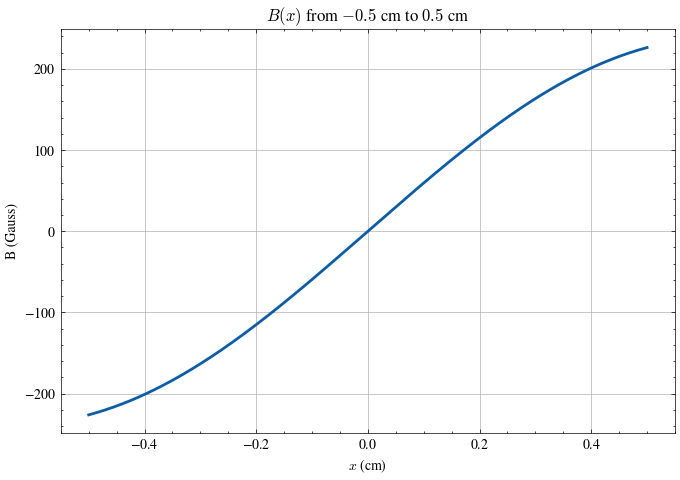

In [ ]:
x5_cm = np.linspace(-0.5, 0.5, 5000)

plt.figure(figsize=(7,5))
plt.plot(x5_cm, B(x5_cm), lw=2)

plt.title(r"$B(x)$ from $-0.5$ cm to $0.5$ cm")
plt.xlabel(r"$x$ (cm)")
plt.ylabel("B (Gauss)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Flux summary and Dynamics solver

The first cell loads the flux vector(thus field too) from FastHenry simulations, and next cell use this data to solve dynamics for a chosen size.


Analytical SC profile
---------------------
I_SC = 6.299510 nA

0.014999218436873532 0.014999218436873532
5x5 : I_profile = 1.406758e+23 nA, I_check = 6.300000 nAI_check = 6.294398 nA
-0.025019238476953542 0.014999218436873532
15x5 : I_profile = 7.757082e+22 nA, I_check = 6.300000 nAI_check = 6.219339 nA
-0.03503927855711395 0.014999218436873532
25x5 : I_profile = 5.437083e+22 nA, I_check = 6.300000 nAI_check = 6.286914 nA
0.04505931863727267 0.014999218436873532
35x5 : I_profile = 4.203809e+22 nA, I_check = 6.300000 nAI_check = 6.233543 nA
-0.05507935871743478 0.014999218436873532
45x5 : I_profile = 3.423009e+22 nA, I_check = 6.300000 nAI_check = 6.245815 nA
-0.060089378757514134 0.014999218436873532
50x5 : I_profile = 3.139141e+22 nA, I_check = 6.300000 nAI_check = 6.165183 nA
5 x 5
-----------------------
1.7429329340609265e-11
2.4136739536249156e-11
-----------------------
7.932957053548858e-12
7.939579804450019e-12
0.9991658562462652
0.19624365442819894
0.1960799590096476
-------

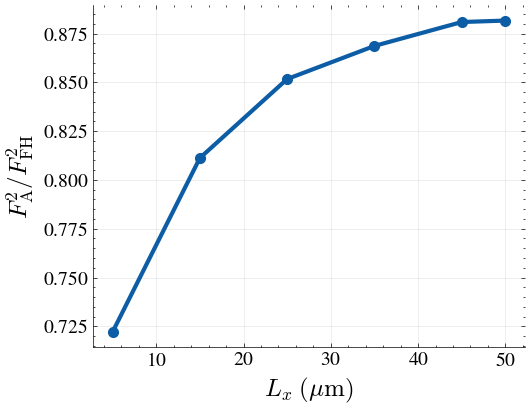

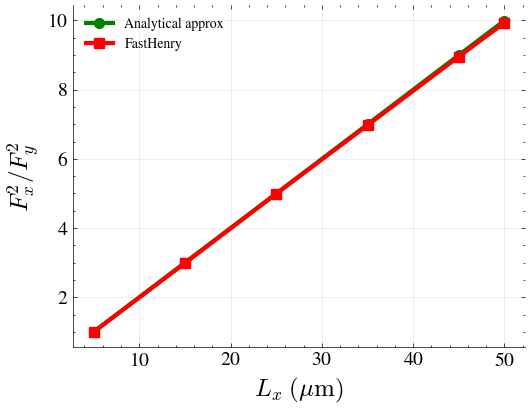

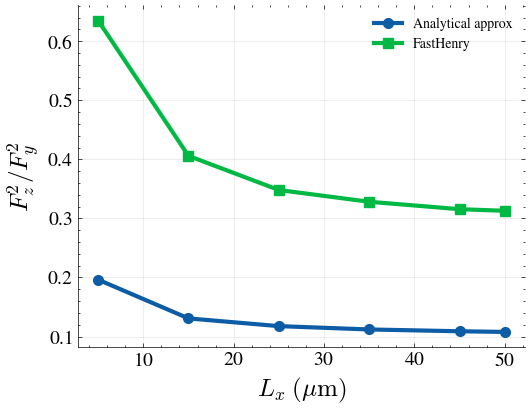

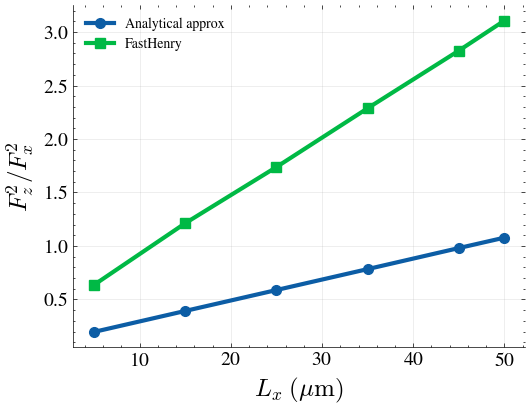

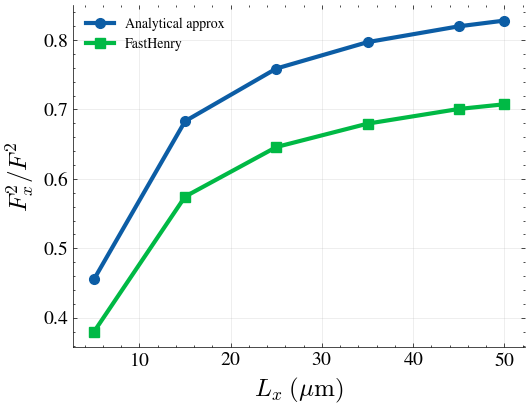

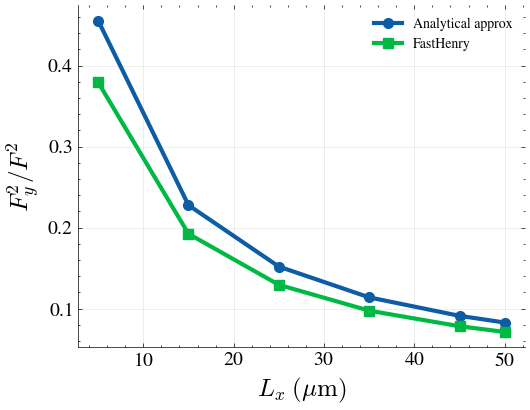

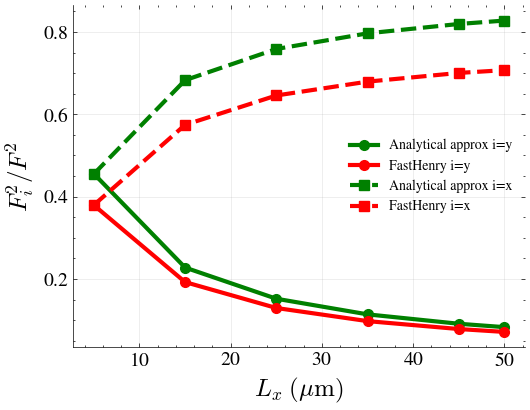

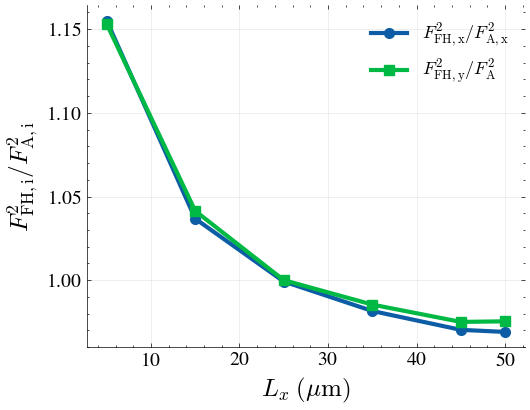

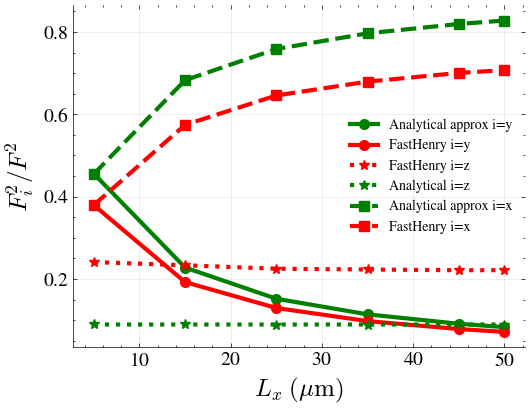

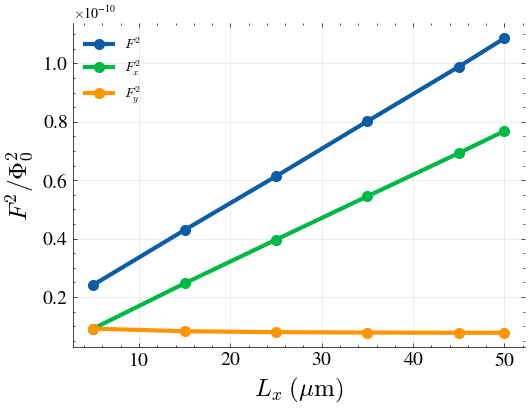

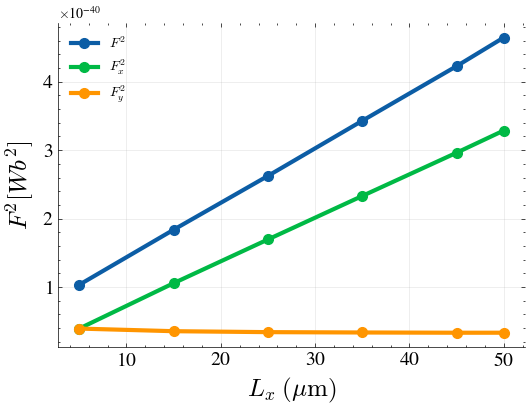

/tmp/ipykernel_2493/2662574907.py:610: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


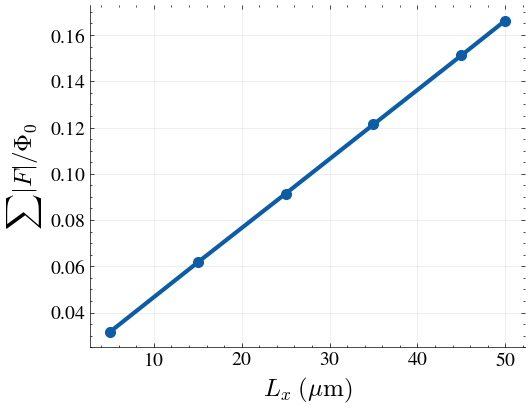

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d, CubicSpline

# ============================================================
# Constants
# ============================================================

files = [5, 15, 25, 35, 45, 50]   # file names correspond to Lx x Ly, with Ly = 5


# FastHenry cut window
y_min_um = -(Ly+W_um/2)
y_max_um = -W_um/2
y_center_um = 0.5 * (y_min_um + y_max_um)

# Flux interpolator grid
Xmin_um = -W_um
Xmax_um = W_um
Nx_flux = 1200
Nu_flux = 7000

# ============================================================
# Analytical superconducting current density
# ============================================================

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_target) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

# SC profile centered at 0
u_sc = np.linspace(-1, 1, Nu_flux)
eps = 1e-10
u_sc[np.abs(u_sc - 1) < eps] = 1 - eps
u_sc[np.abs(u_sc + 1) < eps] = -1 + eps

J_sc = J_SC(u_sc)
y_sc_m = (W / 2) * u_sc

I_sc_check = b * np.trapezoid(J_sc, y_sc_m)
print()
print("Analytical SC profile")
print("---------------------")
print(f"I_SC = {I_sc_check*1e9:.6f} nA")
print()

# ============================================================
# Helper: load and normalize one FastHenry profile
# ============================================================

def load_profile(file_id, y_min_um=-7.5, y_max_um=-2.5):
    d = np.loadtxt(f"files_FH/{file_id}x5_interp.mat")
    x_min_um=-float(file_id)/2-W_um
    x_max_um=-float(file_id)/2
    x_center_um = 0.5 * (x_min_um + x_max_um)

    x_um = d[:, 0] * 1e6
    y_um = d[:, 1] * 1e6

    Jx = d[:, 2]
    Jy = d[:, 3]
    Jz = d[:, 4]

    Jmag_raw = np.sqrt(Jx**2 + Jy**2 + Jz**2)
    #Jmag_raw = d[:, 5]
    Jmag_raw = np.nan_to_num(Jmag_raw, nan=0.0)

    # Restrict y range
    mask_y = (y_um >= y_min_um) & (y_um <= y_max_um)
    mask_x = (x_um >= x_min_um) & (x_um <= x_max_um)

    x1 = x_um[mask_y]
    y1 = y_um[mask_y]
    J1 = Jmag_raw[mask_y]

    x2 = x_um[mask_x]
    y2 = y_um[mask_x]
    J2 = Jmag_raw[mask_x]

    # x slice closest to 0
    x_unique = np.unique(x1)
    x0 = x_unique[np.argmin(np.abs(x_unique))]
    mask_xx = np.isclose(x1, x0)

    y_unique = np.unique(y2)
    y0 = y_unique[np.argmin(np.abs(y_unique))]
    mask_yy = np.isclose(y2, y0)

    print(x0,y0)

    y_cut_um = y1[mask_xx]
    J_cut_raw = J1[mask_xx]

    x_cut_um = x2[mask_yy]
    J_cuty_raw = J2[mask_yy]

    # Sort by y
    order = np.argsort(y_cut_um)
    y_cut_um = y_cut_um[order]
    J_cut_raw = J_cut_raw[order]

    order = np.argsort(x_cut_um)
    x_cut_um = x_cut_um[order]
    J_cuty_raw = J_cuty_raw[order]

    # Center the profile to compare fairly with SC
    y_cut_centered_um = y_cut_um - y_center_um
    y_cut_centered_m = y_cut_centered_um * um

    x_cut_centered_um = x_cut_um - x_center_um
    x_cut_centered_m = x_cut_centered_um * um

    # Current from raw profile: I = b * ∫ J(y) dy
    I_profile = b * np.trapezoid(J_cut_raw, y_cut_um * um)   # A

    scale = I_target / I_profile
    J_cut_norm = J_cut_raw * scale                           # A/m^2
    J_cuty_norm = J_cuty_raw * scale                           # A/m^2

    # For plotting only: A/m^2 -> nA/μm^2
    J_cut_plot = J_cut_norm * 1e-3
    J_cuty_plot = J_cuty_norm * 1e-3

    # Check current in plotted units
    I_check_nA = b_um * np.trapezoid(J_cut_plot, y_cut_um)
    I_check_nAx = b_um * np.trapezoid(J_cuty_plot, x_cut_um)

    print(
        f"{file_id}x5 : "
        f"I_profile = {I_profile*1e9:.6e} nA, "
        f"I_check = {I_check_nA:.6f} nA"
        f"I_check = {I_check_nAx:.6f} nA"
    )

    return {
        "x_um": x_um,
        "y_um": y_cut_um,
        "y_centered_um": y_cut_centered_um,
        "y_centered_m": y_cut_centered_m,
        "x_centered_um": x_cut_centered_um,
        "x_centered_m": x_cut_centered_m,
        "J_norm_SI": J_cut_norm,
        "J_plot": J_cut_plot,
        "J_norm_SIx": J_cuty_norm,
        "J_plotx": J_cuty_plot,
        "I_profile": I_profile,
        "I_check_nA": I_check_nA,
        "I_check_nAx": I_check_nAx
    }

# ============================================================
# Flux calculation from an arbitrary normalized current profile
# ============================================================

def compute_flux_from_profile(y_m, J_m2, I_reference, X_vals_um, Z_m, Nu=7000):
    """
    y_m: coordinate across the strip in meters (centered)
    J_m2: normalized current density in A/m^2
    I_reference: total current in A used in normalization
    X_vals_um: observation x positions in micrometers
    Z_m: observation height in meters
    """
    X_vals_m = np.asarray(X_vals_um) * um

    J_interp = interp1d(
        y_m,
        J_m2,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    y_grid = np.linspace(y_m.min(), y_m.max(), Nu)
    J_y = J_interp(y_grid)

    # Ratio has units 1/m^2
    J_ratio = J_y / I_reference

    dx = y_grid[:, None] - X_vals_m[None, :]

    log_term = np.log(
        (dx**2 + Z_m**2) /
        (dx**2 + (Z_m + b)**2)
    )

    atan_term = (
        np.arctan2(Z_m + b, dx) -
        np.arctan2(Z_m, dx)
    )

    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        y_grid,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        y_grid,
        axis=0
    )

    Fx = -(g * mu_s * mu_0 / (4 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 / (2 * np.pi)) * integral_fz

    return Fx, Fz

# ============================================================
# Flux interpolator for fast Monte Carlo evaluation
# ============================================================

class FluxInterpolator:
    def __init__(
        self,
        y_m,
        J_m2,
        I_reference,
        Z_m,
        Xmin_um=-W_um,
        Xmax_um=W_um,
        Nx=Nx_flux,
        Nu=Nu_flux
    ):
        self.X_grid_um = np.linspace(Xmin_um, Xmax_um, Nx)

        Fx_grid, Fz_grid = compute_flux_from_profile(
            y_m=y_m,
            J_m2=J_m2,
            I_reference=I_reference,
            X_vals_um=self.X_grid_um,
            Z_m=Z_m,
            Nu=Nu
        )

        # Dimensionless fluxes normalized by phi0
        self.Fx_spline = CubicSpline(self.X_grid_um, Fx_grid / phi0)
        self.Fz_spline = CubicSpline(self.X_grid_um, Fz_grid / phi0)

    def __call__(self, X_um):
        X_um = np.asarray(X_um)
        return self.Fx_spline(X_um), self.Fz_spline(X_um)

# ============================================================
# Build SC and FastHenry flux interpolators
# ============================================================

flux_fun_SC = FluxInterpolator(
    y_m=y_sc_m,
    J_m2=J_sc,
    I_reference=I_target,
    Z_m=Z_m
)

profile_data = {}
flux_fun_mag_x = {}
flux_fun_mag_y = {}

for n in files:
    data = load_profile(n, y_min_um=y_min_um, y_max_um=y_max_um)
    profile_data[n] = data

    flux_fun_mag_x[n] = FluxInterpolator(
        y_m=data["y_centered_m"],
        J_m2=data["J_norm_SI"],
        I_reference=data["I_check_nA"]*1e-9,
        Z_m=Z_m
    )
    flux_fun_mag_y[n] = FluxInterpolator(
        y_m=data["x_centered_m"],
        J_m2=data["J_norm_SIx"],
        I_reference=data["I_check_nAx"]*1e-9,
        Z_m=Z_m
    )

# ============================================================
# Monte Carlo comparison for each file
# ============================================================

results_noise = []

for lx in files:
    ly = 5

    Ax = lx * W_um
    Ay = ly * W_um

    Nx = int(2 * Ax * sigma_um2)
    Ny = int(2 * Ay * sigma_um2)

    # If you want to avoid huge arrays, cap them here if needed:
    # Nx = min(Nx, 2_000_000)
    # Ny = min(Ny, 2_000_000)

    # Random positions in micrometers
    Xj_um = rng.uniform(-W_um / 2, W_um / 2, Ny)
    Yj_um = rng.uniform(-W_um / 2, W_um / 2, Nx)

    nY = max(1, int(r_sample * Ny))
    nX = max(1, int(r_sample * Nx))
    scale = 1 / r_sample

    # SC
    Fx_ySC, Fz_ySC = flux_fun_SC(Xj_um[:nY])
    Fy_xSC, Fz_xSC = flux_fun_SC(Yj_um[:nX])

    # FastHenry
    Fx_ymag, Fz_ymag = flux_fun_mag_y[lx](Xj_um[:nY])
    Fy_xmag, Fz_xmag = flux_fun_mag_x[lx](Yj_um[:nX])

    Fy=(Fx_ymag**2).sum()
    Fx=(Fy_xmag**2).sum()
    Fz1 = (Fz_xmag**2).sum()
    Fz2 = (Fz_ymag**2).sum()
    Fz=Fz1+Fz2
    F_flux = np.sqrt(Fx_ymag**2+Fz_ymag**2).sum()*scale+np.sqrt(Fy_xmag**2+Fz_xmag**2).sum()*scale

    Fy_SC=(Fx_ySC**2).sum()
    Fx_SC=(Fy_xSC**2).sum()
    Fz1_SC = (Fz_xSC**2).sum()
    Fz2_SC = (Fz_ySC**2).sum()
    Fz_SC=Fz1_SC+Fz2_SC

    # Noise-like sums
    total_SC = Fz2_SC*scale + Fz1_SC*scale + Fx_SC*scale + Fy_SC*scale
    total_FH = Fz2*scale + Fz1*scale + Fx*scale + Fy*scale

    # Requested Sx and Sy pieces
    Sx_SC = Fx_SC * scale
    Sx_MAG = Fx * scale

    Sy_SC = Fy_SC * scale
    Sy_MAG = Fy * scale

    Sz_SC = Fz_SC * scale
    Sz_MAG = Fz * scale

    xy_sc = Fx_SC / Fy_SC
    zx_sc = Fz_SC/Fx_SC#(Fz_xSC**2).sum() / Fx_SC
    zy_sc = Fz_SC/ Fy_SC

    xy_mag = Fx / Fy
    zx_mag = Fz/ Fx#(Fz_xmag**2).sum() / Fx
    zy_mag = Fz/Fy#(Fz_ymag**2).sum() / Fy

    results_noise.append({
        "lx": lx,
        "ly": ly,

        "SC": total_SC,
        "MAG": total_FH,
        "ratio": total_SC / total_FH,
        "flux": F_flux,

        "Sx_SC": Sx_SC,
        "Sx_MAG": Sx_MAG,
        "Sy_SC": Sy_SC,
        "Sy_MAG": Sy_MAG,
        "Sz_SC": Sz_SC,
        "Sz_MAG": Sz_MAG,

        "xy_SC": xy_sc,
        "zx_SC": zx_sc,
        "zy_SC": zy_sc,

        "xy_MAG": xy_mag,
        "zx_MAG": zx_mag,
        "zy_MAG": zy_mag,
    })

    print(f"{lx} x {ly}")
    print("-----------------------")
    print(total_SC)
    print(total_FH)
    print("-----------------------")
    print(Sx_SC)
    print(Sy_SC)
    print(xy_sc)
    print(zx_sc)
    print(zy_sc)
    print("-----------------------")
    print(Sx_MAG)
    print(Sy_MAG)
    print(xy_mag)
    print(zx_mag)
    print(zy_mag)
    print("-----------------------")
    print("x comparison", Sx_MAG / Sx_SC)
    print("y comparison", Sy_MAG / Sy_SC)
    print("MAG/SC", total_FH / total_SC)
    print()

# ============================================================
# Summary arrays
# ============================================================

lx_vals = np.array([r["lx"] for r in results_noise])

ratio_vals = np.array([r["ratio"] for r in results_noise])
mag_vals = np.array([r["MAG"] for r in results_noise])
fx_vals = np.array([r["Sx_MAG"] for r in results_noise])
fy_vals = np.array([r["Sy_MAG"] for r in results_noise])

xy_sc_vals = np.array([r["xy_SC"] for r in results_noise])
xy_mag_vals = np.array([r["xy_MAG"] for r in results_noise])

zx_sc_vals = np.array([r["zx_SC"] for r in results_noise])
zx_mag_vals = np.array([r["zx_MAG"] for r in results_noise])

zy_sc_vals = np.array([r["zy_SC"] for r in results_noise])
zy_mag_vals = np.array([r["zy_MAG"] for r in results_noise])

flux = np.array([r["flux"] for r in results_noise])

redx_sc_vals = np.array([r["Sx_SC"] / r["SC"] for r in results_noise])
redx_mag_vals = np.array([r["Sx_MAG"] / r["MAG"] for r in results_noise])

redy_sc_vals = np.array([r["Sy_SC"] / r["SC"] for r in results_noise])
redy_mag_vals = np.array([r["Sy_MAG"] / r["MAG"] for r in results_noise])

redz_sc_vals = np.array([r["Sz_SC"] / r["SC"] for r in results_noise])
redz_mag_vals = np.array([r["Sz_MAG"] / r["MAG"] for r in results_noise])

Sx_ratio = np.array([r["Sx_MAG"] / r["Sx_SC"] for r in results_noise])
Sy_ratio = np.array([r["Sy_MAG"] / r["Sy_SC"] for r in results_noise])

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, ratio_vals, "-o", lw=3, ms=7)
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_{\rm A}/F^2_{\rm FH}$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, xy_sc_vals, "-o", color="green", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, xy_mag_vals, "-s", color="red", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_x/F^2_y$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("xy.pdf")
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, zx_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, zx_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_z/F^2_y$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, zy_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, zy_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_z/F^2_x$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, redx_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, redx_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_x/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, redy_sc_vals, "-o", lw=3, ms=7, label="Analytical approx")
plt.plot(lx_vals, redy_mag_vals, "-s", lw=3, ms=7, label="FastHenry")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_y/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, redy_sc_vals, "o-", color="green", lw=3, ms=7, label="Analytical approx i=y")
plt.plot(lx_vals, redy_mag_vals, "o-", color="red", lw=3, ms=7, label="FastHenry i=y")
plt.plot(lx_vals, redx_sc_vals, "s--", color="green", lw=3, ms=7, label="Analytical approx i=x")
plt.plot(lx_vals, redx_mag_vals, "s--", color="red", lw=3, ms=7, label="FastHenry i=x")

plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_i/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# New requested comparison plots
plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, Sx_ratio, "-o", lw=3, ms=7, label=r"$F_{\rm FH,x}^2/F_{\rm A,x}^2$")
plt.plot(lx_vals, Sy_ratio, "-s", lw=3, ms=7, label=r"$F_{\rm FH,y}^2/F_{\rm A}^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_{\rm FH,i}^2/F_{\rm A,i}^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, redy_sc_vals, "o-", color="green", lw=3, ms=7, label="Analytical approx i=y")
plt.plot(lx_vals, redy_mag_vals, "o-", color="red", lw=3, ms=7, label="FastHenry i=y")
plt.plot(lx_vals, redz_mag_vals, "*:", color="red", lw=3, ms=7, label="FastHenry i=z")
plt.plot(lx_vals, redz_sc_vals, "*:", color="green", lw=3, ms=7, label="Analytical i=z")
plt.plot(lx_vals, redx_sc_vals, "s--", color="green", lw=3, ms=7, label="Analytical approx i=x")
plt.plot(lx_vals, redx_mag_vals, "s--", color="red", lw=3, ms=7, label="FastHenry i=x")

plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2_i/F^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, mag_vals, "-o", lw=3, ms=7, label=r"$F^2$")
plt.plot(lx_vals, fx_vals, "-o", lw=3, ms=7, label=r"$F_x^2$")
plt.plot(lx_vals, fy_vals, "-o", lw=3, ms=7, label=r"$F_y^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2/\Phi_0^2$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, (3.3920534187343736e-40*mag_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F^2$")
plt.plot(lx_vals, (3.3920534187343736e-40*fx_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F_x^2$")
plt.plot(lx_vals, (3.3920534187343736e-40*fy_vals/7.931946813098828e-11), "-o", lw=3, ms=7, label=r"$F_y^2$")
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F^2[Wb^2]$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 4.3))
plt.plot(lx_vals, flux, "-o", lw=3, ms=7)
plt.xlabel(r"$L_x\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$\sum|F|/\Phi_0$", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Dynamics solver

With the next cell you can choose the external field of preference and simulate the dynamics with diffusion and/or relaxation.

m0 shape = (120, 120, 3)
B shape = (120, 120, 3)
mask shape = (120, 120)
Total internal steps: 2682
Saved plot to m_snapshots_loop.png


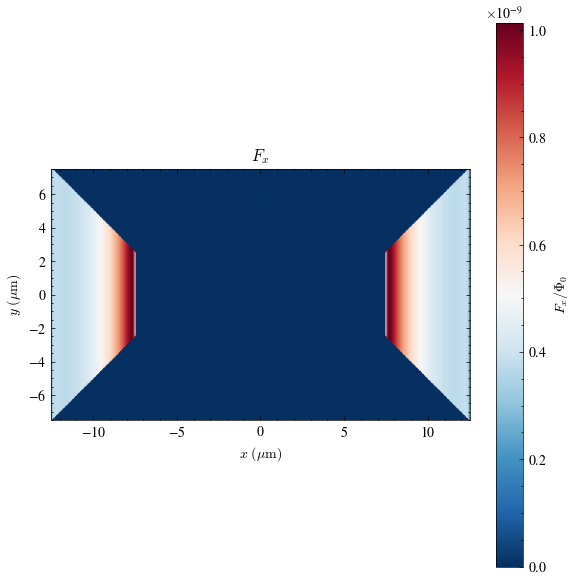

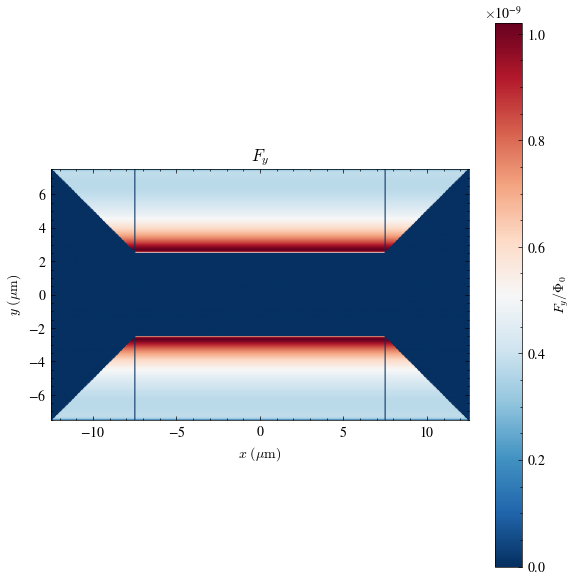

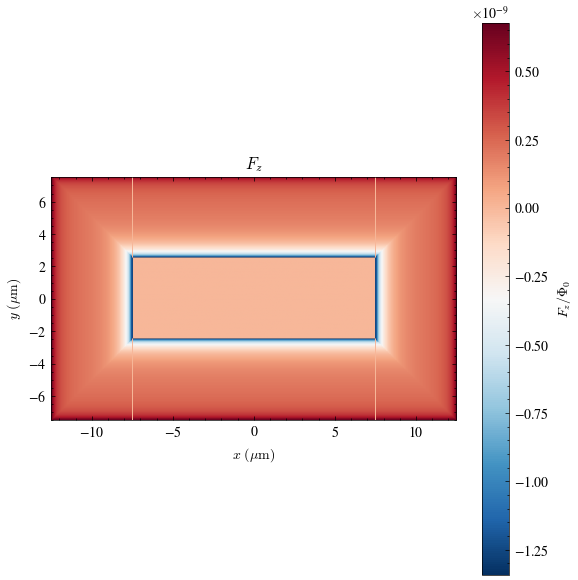

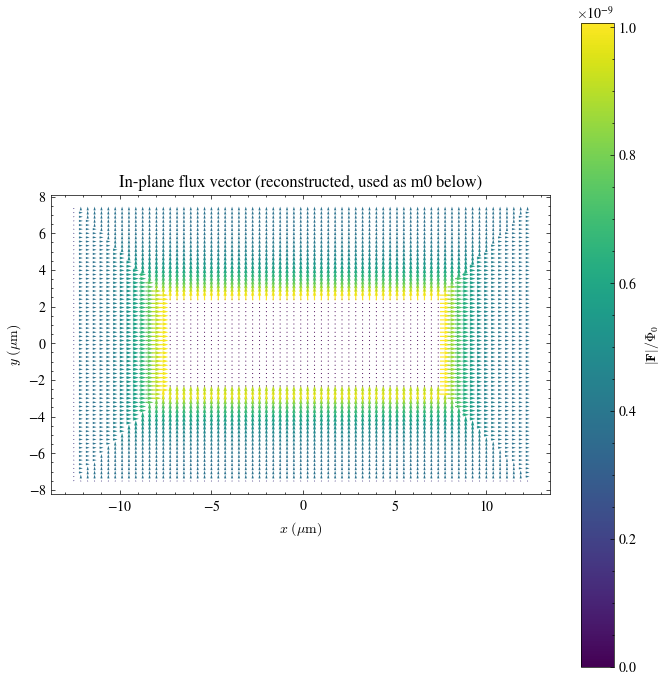

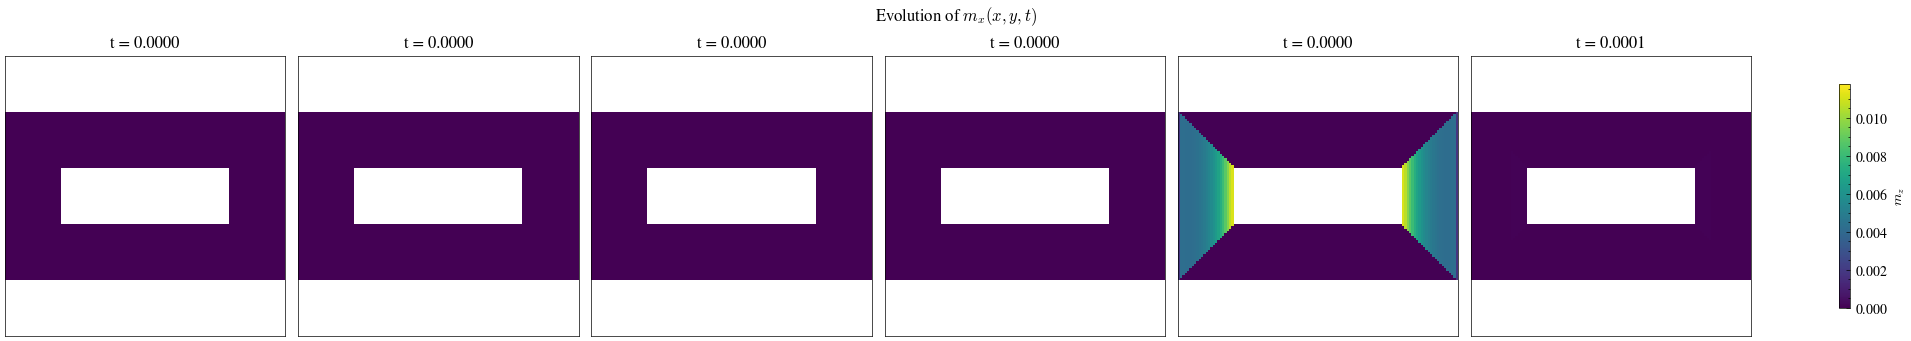

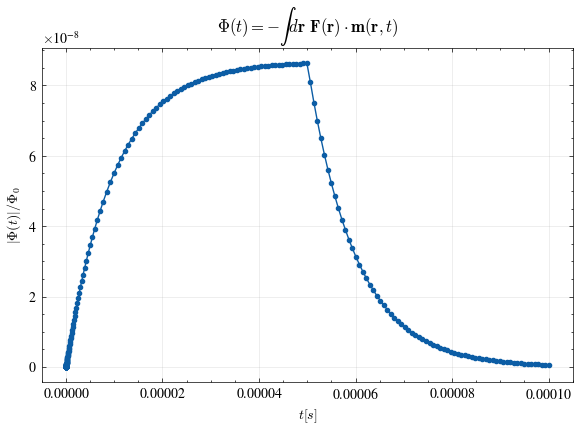

In [24]:
# ============================================================
# PART 1: Reconstruct 2D flux field from strip profiles
# (unchanged from your original code — produces Fx, Fy, Fz
#  on grid X, Y with shape (Ny, Nx), meshgrid(x, y) 'xy' indexing)
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator

sigmam2=5e17#meters^-2
sigma=sigmam2*1e-12#micrometers^-2
Ip_nA=6.3


# choose which geometry
Lx = 15          # one of the values in "files"

halfLx = Lx / 2
halfLy = Ly / 2

strip_width = W_um

# plotting domain
margin = W_um

Nx_flux, Ny_flux = 401, 401

x_flux = np.linspace(-halfLx - margin, halfLx + margin, Nx_flux)
y_flux = np.linspace(-halfLy - margin, halfLy + margin, Ny_flux)

X_flux, Y_flux = np.meshgrid(x_flux, y_flux)  # shape (Ny_flux, Nx_flux), 'xy' indexing

Fx = np.zeros_like(X_flux)
Fy = np.zeros_like(X_flux)
Fz = np.zeros_like(X_flux)

# ============================================================
# Masks defining the four strips
# (corners intentionally ignored)
# ============================================================

corner = strip_width / 2

mask_left = (
    (np.abs(X_flux + halfLx + strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_right = (
    (np.abs(X_flux - halfLx - strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_bottom = (
    (np.abs(Y_flux + halfLy + strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

mask_top = (
    (np.abs(Y_flux - halfLy - strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

# top and right must have a flip because current flows against the convention
# ============================================================
# LEFT ARM
# ============================================================

d = X_flux[mask_left] + halfLx + W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_left] = Fx_tmp
Fz[mask_left] = Fz_tmp

# ============================================================
# RIGHT ARM
# ============================================================

d = X_flux[mask_right] - halfLx - W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_right] = np.flip(Fx_tmp)
Fz[mask_right] = np.flip(Fz_tmp)

# ============================================================
# BOTTOM ARM
# ============================================================

d = Y_flux[mask_bottom] + halfLy + W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_bottom] = Fy_tmp
Fz[mask_bottom] = Fz_tmp

# ============================================================
# TOP ARM
# ============================================================

d = Y_flux[mask_top] - halfLy - W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_top] = np.flip(Fy_tmp)
Fz[mask_top] = np.flip(Fz_tmp)

# ============================================================
# Fill the four corners by interpolating from strip data
# ============================================================

mask_corner_bl = (X_flux < -halfLx) & (Y_flux < -halfLy)
mask_corner_br = (X_flux > halfLx) & (Y_flux < -halfLy)
mask_corner_tl = (X_flux < -halfLx) & (Y_flux > halfLy)
mask_corner_tr = (X_flux > halfLx) & (Y_flux > halfLy)

corner_masks = {
    "bottom_left": mask_corner_bl,
    "bottom_right": mask_corner_br,
    "top_left": mask_corner_tl,
    "top_right": mask_corner_tr,
}

data_mask = mask_left | mask_right | mask_top | mask_bottom
pts_known = np.column_stack([X_flux[data_mask], Y_flux[data_mask]])

for name, cmask in corner_masks.items():
    if not np.any(cmask):
        continue
    pts_query = np.column_stack([X_flux[cmask], Y_flux[cmask]])
    for field, arr in (("Fx", Fx), ("Fy", Fy), ("Fz", Fz)):
        vals_known = arr[data_mask]
        interp_vals = griddata(pts_known, vals_known, pts_query, method="nearest")
        nan_mask = np.isnan(interp_vals)
        if np.any(nan_mask):
            interp_vals[nan_mask] = griddata(
                pts_known, vals_known, pts_query[nan_mask], method="nearest"
            )
        arr[cmask] = interp_vals

# (Optional) diagnostic plots of Fx, Fy, Fz and the in-plane vector field
# — kept exactly as before, just wrapped so they don't block execution.

def _plot_field(field, name, symbol):
    plt.figure(figsize=(6, 6))
    plt.imshow(
        field, origin="lower",
        extent=[x_flux.min(), x_flux.max(), y_flux.min(), y_flux.max()],
        cmap="RdBu_r", aspect="equal",
    )
    plt.colorbar(label=rf"${symbol}/\Phi_0$")
    plt.xlabel(r"$x\ (\mu{\rm m})$")
    plt.ylabel(r"$y\ (\mu{\rm m})$")
    plt.title(rf"${symbol}$")
    plt.tight_layout()

_plot_field(Fx, "Fx", "F_x")
_plot_field(Fy, "Fy", "F_y")
_plot_field(Fz, "Fz", "F_z")

step = 6
plt.figure(figsize=(7, 7))
plt.quiver(
    X_flux[::step, ::step], Y_flux[::step, ::step],
    Fx[::step, ::step], Fy[::step, ::step],
    np.sqrt(Fx[::step, ::step] ** 2 + Fy[::step, ::step] ** 2),
    cmap="viridis", pivot="mid",
)
plt.gca().set_aspect("equal")
plt.xlabel(r"$x\ (\mu{\rm m})$")
plt.ylabel(r"$y\ (\mu{\rm m})$")
plt.title("In-plane flux vector (reconstructed, used as m0 below)")
plt.colorbar(label=r"$|\mathbf{F}|/\Phi_0$")
plt.tight_layout()


# ============================================================
# PART 2: 2D vector diffusion on a rectangular loop,
# initialized with m0 = (Fx, Fy, Fz) from Part 1
# ============================================================

from diffusion2d_complete import (
    build_rectangular_loop_mask,
    solve_diffusion_2d_loop,
    max_stable_dt, build_nonuniform_time_grid,
)

Nx, Ny = 120, 120

# domain_size is set from the flux grid itself so both fields live on
# compatible (µm) coordinates and the interpolation in Part 1 -> Part 2
# actually overlaps.
domain_size = 2 * max(halfLx + margin, halfLy + margin)

x = np.linspace(-domain_size / 2, domain_size / 2, Nx)
y = np.linspace(-domain_size / 2, domain_size / 2, Ny)
dx, dy = x[1] - x[0], y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing="ij")  # shape (Nx, Ny), 'ij' indexing

Lx_outer, Ly_outer = Lx + 2 * W_um, Ly + 2 * W_um
mask = build_rectangular_loop_mask(X, Y, Lx_outer, Ly_outer, W_um)


# ------------------------------------------------------------
# Build m0 by interpolating the reconstructed (Fx, Fy, Fz) field
# from Part 1's grid (X_flux, Y_flux) onto Part 2's grid (X, Y).
#
# Part 1 used meshgrid(x_flux, y_flux) with default 'xy' indexing,
# so Fx/Fy/Fz have shape (Ny_flux, Nx_flux) and are indexed [row=y, col=x].
# RegularGridInterpolator wants strictly increasing axes in the order
# matching the array's own indexing, so we build it as (y_flux, x_flux) -> value,
# then query at each (X, Y) point of Part 2's grid, which uses 'ij' indexing
# (shape (Nx, Ny), indexed [x, y]).
# ------------------------------------------------------------

def interp_to_target_grid(field_xy_indexed, y_source, x_source, X_target, Y_target):
    """field_xy_indexed: array of shape (len(y_source), len(x_source))."""
    interpolator = RegularGridInterpolator(
        (y_source, x_source), field_xy_indexed,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    query_pts = np.column_stack([Y_target.ravel(), X_target.ravel()])
    return interpolator(query_pts).reshape(X_target.shape)

Fx_on_target = interp_to_target_grid(Fx, y_flux, x_flux, X, Y)
Fy_on_target = interp_to_target_grid(Fy, y_flux, x_flux, X, Y)
Fz_on_target = interp_to_target_grid(Fz, y_flux, x_flux, X, Y)
Fx_on_target = Fx_on_target*phi0*1e12#um units
Fy_on_target = Fy_on_target*phi0*1e12
Fz_on_target = Fz_on_target*phi0*1e12

B0 = 200.0            # Gauss
B0 *= 1e-4            # Tesla

R_cm = .4

X_cm = X * 1e-4
Y_cm = Y * 1e-4

Bext_y = B0 * (
    (1.0 + (Y_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (Y_cm/R_cm + 0.5)**2)**(-1.5)
)

Bext_x = B0 * (
    (1.0 + (X_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (X_cm/R_cm + 0.5)**2)**(-1.5)
)


F = np.zeros((Nx, Ny, 3))
F[..., 0] = Fx_on_target#0.
F[..., 1] = Fy_on_target
F[..., 2] = Fz_on_target
mu_B_nAum2 = 9.2740100657e-24 * 1e21#this is a factor to have uniform units
Ip_nA=6.3

B_quibtx=Fx_on_target*Ip_nA/mu_B_nAum2
B_quibty=Fy_on_target*Ip_nA/mu_B_nAum2
B_quibtz=Fz_on_target*Ip_nA/mu_B_nAum2

Fmag=np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)

m0 = np.zeros((Nx, Ny, 3))
m0[..., 0] = 0#1*Fx_on_target#np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)
m0[..., 1] = 0#1*Fy_on_target#Fy_on_target
m0[..., 2] = 0#1*Fz_on_target#Fz_on_target
#m0[..., 0]=0.1


B_static = np.zeros((Nx, Ny, 3))
B_static[..., 0] = B_quibtx#+1e-6#Bext_x#0.
B_static[..., 1] = B_quibty+1e-7#+0.002
B_static[..., 2] = B_quibtz

# B_static[..., 0] = 0.04#Bext_x#0.
# B_static[..., 1] = 0.#+0.002
# B_static[..., 2] = 0.

#B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.002

Bmag=np.sqrt(B_static[..., 0]**2+B_static[..., 1]**2+B_static[..., 2]**2)
T1=10e-6*1
a=1.5
TD=T1/1
D, T = a**2/TD, 20e-3

# zero out m0 outside the loop material, so only the mask region carries
# the reconstructed field into the diffusion solve
m0[~mask, :] = 0.0




dt = max_stable_dt(D, dx, dy, Bmax=np.max(Bmag), safety=.9)/4
#dt=1e-6

save_every = 150
n_steps = int(10*T1/dt)#11000

# def B_func(t):#, t_off=5*T1, t_ramp=0.5*T1):
#     """
#     B field with linear ramp-up at turn-on and linear ramp-down at turn-off.

#     t_ramp : duration of the linear ramp (both up and down)
#     t_off  : time at which the field starts turning off (end of the 'on' plateau)
#     """
#     t_ramp = 2*T1
#     t_off = 5*T1
#     if t < 0:
#         return 0.0
#     elif t < t_ramp:
#         # linear ramp up
#         return B_static * (t / t_ramp)
#     elif t < t_off:
#         # steady plateau
#         return B_static
#     elif t < t_off + t_ramp:
#         # linear ramp down
#         return B_static * (1 - (t - t_off) / t_ramp)
#     else:
#         return np.zeros_like(B_static)

def B_func(t):
    return B_static*np.heaviside(-t+5*T1,0)

print("m0 shape =", m0.shape)
print("B shape =", B_func(0).shape)
print("mask shape =", mask.shape)

t_grid = build_nonuniform_time_grid(t_final=10*T1, T1=T1, n_points=500, n_frac_before_T1=0.75, t_min=1e-19)
total_substeps = sum(
    max(int(np.ceil((t_grid[n]-t_grid[n-1])/max_stable_dt(D, dx, dy, Bmax=np.max(Bmag), safety=.9))), 1)
    for n in range(1, len(t_grid))
)
print(f"Total internal steps: {total_substeps}")

times, m_hist = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, t_grid,
    T=20e-3, T1=T1, T2=np.inf,
    diffusion=False, relaxation=True, precession=False
)

times, m_hist_both = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, t_grid,
    T=20e-3, T1=T1, T2=np.inf,
    diffusion=True, relaxation=True, precession=False
)

times, m_hist_dif = solve_diffusion_2d_loop(
    m0, B_func, mask, D, dx, dy, t_grid,
    T=20e-3, T1=T1, T2=np.inf,
    diffusion=True, relaxation=False, precession=False
)

# mask out non-material points as NaN so they show blank in the plot
m_hist_plot = m_hist.copy()*sigma_um2
m_hist_plot[:, ~mask, :] = np.nan

component = 0
n_panels = 6
idxs = np.linspace(0, len(times) - 1, n_panels).astype(int)

fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3.4), constrained_layout=True)

vmin = np.nanmin(m_hist_plot[..., component])
vmax = np.nanmax(m_hist_plot[..., component])

for ax, k in zip(axes, idxs):
    im = ax.pcolormesh(X, Y, m_hist_plot[k, ..., component], cmap="viridis",
                        vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(f"t = {times[k]:.4f}")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label=r"$m_z$")
fig.suptitle(r"Evolution of $m_x(x,y,t)$")

# fig.savefig("/mnt/user-data/outputs/m_snapshots_loop.png", dpi=150)
print("Saved plot to m_snapshots_loop.png")

# ============================================================
# PART 3: phi(t) = -\int dr  m0(r) . m(r, t)
# integral taken only over the "zone with data", i.e. the loop
# material defined by `mask` (m0 is zero outside it anyway, but
# we mask explicitly for clarity and to set the area element).
# ============================================================

cell_area = dx * dy

#dot product m0(r) . m(r,t) at every grid point and every saved time,
# broadcasting m0 (Nx,Ny,3) against m_hist (n_times,Nx,Ny,3)
dot_both = np.sum(F[None, ...] * m_hist_both, axis=-1)*sigma_um2  # shape (n_times, Nx, Ny)

# restrict the integral to the masked (data) region
dot_masked_both = np.where(mask[None, ...], dot_both, 0.0)

phi_both = -cell_area * np.sum(dot_masked_both, axis=(1, 2))*1e-12 / phi0  # shape (n_times,)

# dot product m0(r) . m(r,t) at every grid point and every saved time,
# broadcasting m0 (Nx,Ny,3) against m_hist (n_times,Nx,Ny,3)
dot_dif = np.sum(F[None, ...] * m_hist_dif, axis=-1)*sigma_um2  # shape (n_times, Nx, Ny)

# restrict the integral to the masked (data) region
dot_masked_dif = np.where(mask[None, ...], dot_dif, 0.0)

phi_dif = -cell_area * np.sum(dot_masked_dif, axis=(1, 2))*1e-12 / phi0  # shape (n_times,)

dot_rel = np.sum(F[None, ...] * m_hist, axis=-1)*sigma_um2  # shape (n_times, Nx, Ny)

# restrict the integral to the masked (data) region
dot_masked_rel = np.where(mask[None, ...], dot_rel, 0.0)

phi_rel = -cell_area * np.sum(dot_masked_rel, axis=(1, 2))*1e-12 / phi0

plt.figure(figsize=(6, 4.5))
plt.plot(times, np.abs(phi_both), marker="o", ms=3)
plt.xlabel(r"$t[s]$")
plt.ylabel(r"$|\Phi(t)|/\Phi_0$")
plt.title(r"$\Phi(t) = -\int d\mathbf{r}\ \mathbf{F}(\mathbf{r})\cdot\mathbf{m}(\mathbf{r},t)$")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

This saves the flux computed for the three cases: only relaxation, only diffusion and both. Some naming convecntion examples are discussed in next section of analysis

In [25]:
#You can chose a convenction to save files and do data analysis afterwards
folder_name="flux_data"
field="field1e-7"#nofield1"#"By_grad_center"
Tstat="T1eTD"
np.save(f"{folder_name}/times_{field}_{Tstat}.npy", times)
np.save(f"{folder_name}/phirel_{field}_{Tstat}.npy", phi_rel)
np.save(f"{folder_name}/phidif_{field}_{Tstat}.npy", phi_dif)
np.save(f"{folder_name}/phiboth_{field}_{Tstat}.npy", phi_both)

### Analysys flux

The simulation data are stored using a systematic naming convention. The filename contains information about the magnetic-field configuration, the physical processes included in the simulation, and the relation between the relaxation time $T_1$ and the diffusion time $\tau_D$.

The files containing the flux-related quantity are named `phi`, followed by a label indicating the physical contribution:

- `rel` denotes relaxation only.
- `dif` denotes diffusion only.
- `both` denotes that both relaxation and diffusion are included.

The corresponding `times` files contain the time points used in the simulation. For example,

`phirel_nofield_T1eTD.npy`

contains the relaxation contribution $\phi_{\mathrm{rel}}(t)$, while

`times_nofield_T1eTD.npy`

contains the corresponding time array.

Magnetic-field convention:

For simulations without an external magnetic field, the label `nofield` is used. For example,

`phiboth_nofield_T1eTD.npy`

corresponds to a simulation with no external magnetic field, including both relaxation and diffusion.

For simulations with a uniform external magnetic field, the label `field` is followed by the field magnitude in tesla. For example,

`phiboth_field1e-7_T1eTD.npy`

corresponds to a uniform external field

$$
B_{\mathrm{ext}} = 10^{-7}\,\mathrm{T},
$$

with both relaxation and diffusion included.

Similarly, `field1e-9`, `field1e-8`, and `field1e-6` correspond to uniform external fields of $10^{-9}\,\mathrm{T}$, $10^{-8}\,\mathrm{T}$, and $10^{-6}\,\mathrm{T}$, respectively.

For the Anti-Helmholtz gradient-field simulations, the label `grad` is followed by the amplitude of the gradient field in gauss. For example,

`phiboth_grad350_T1eTD.npy`

corresponds to an Anti-Helmholtz gradient field with amplitude

$$
B_{\mathrm{grad}} = 350\,\mathrm{G},
$$

with both relaxation and diffusion included. Thus, `grad350` refers to a gradient-field configuration and should not be interpreted as a uniform magnetic field of $350\,\mathrm{G}$.

#### Relaxation and diffusion time scales

The suffix `T1eTD` indicates that the relaxation time and diffusion time are equal:

$$
T_1 = \tau_D.
$$

Thus, for example,

`phidif_nofield_T1eTD.npy`

represents a no-field simulation including diffusion only, with

$$
T_1 = \tau_D.
$$

When the ratio $T_1/\tau_D$ is varied, the ratio is encoded directly in the filename and without the suffix. For example,

`phirel_nofield3.npy`

corresponds to

$$
T_1 = 3\tau_D,
$$

while

`phirel_nofield05.npy`

corresponds to

$$
T_1 = 0.5\tau_D.
$$

In these simulations, $\tau_D$ is kept fixed while $T_1$ is changed.

Therefore, a filename can be read from left to right. For example,

`phiboth_grad350_T1eTD.npy`

can be decoded as follows:

- `phi` $\rightarrow$ flux-related quantity;
- `both` $\rightarrow$ relaxation and diffusion are both included;
- `grad350` $\rightarrow$ Anti-Helmholtz gradient field with amplitude $350\,\mathrm{G}$;
- `T1eTD` $\rightarrow$ $T_1=\tau_D$.

The power-law analysis performed looks for a time dependence of the form

$$
\phi(t) = A t^n.
$$

The exponent $n$ is obtained from a linear fit in log-log space,

$$
\ln\phi(t) = \ln A + n\ln t,
$$

using only points for which $\phi(t)>0$.

In addition to a global power-law fit at early times, the local power-law exponent is calculated directly from the numerical data,

$$
n_{\mathrm{local}}(t)
=
\frac{d\ln|\phi(t)|}{d\ln t}.
$$

A region where $n_{\mathrm{local}}(t)$ is approximately constant indicates a time interval in which $\phi(t)$ behaves approximately as a power law. The value of this plateau can then be compared with the exponent $n$ obtained from the global fit.

Found 5 dataset(s) in /content/flux_data:
  - nofield      B=0.0        label=$B=0$
  - field1e-9    B=1e-09      label=$B=10^{-9}$
  - field1e-8    B=1e-08      label=$B=10^{-8}$
  - field1e-7    B=1e-07      label=$B=10^{-7}$
  - field1e-6    B=1e-06      label=$B=10^{-6}$


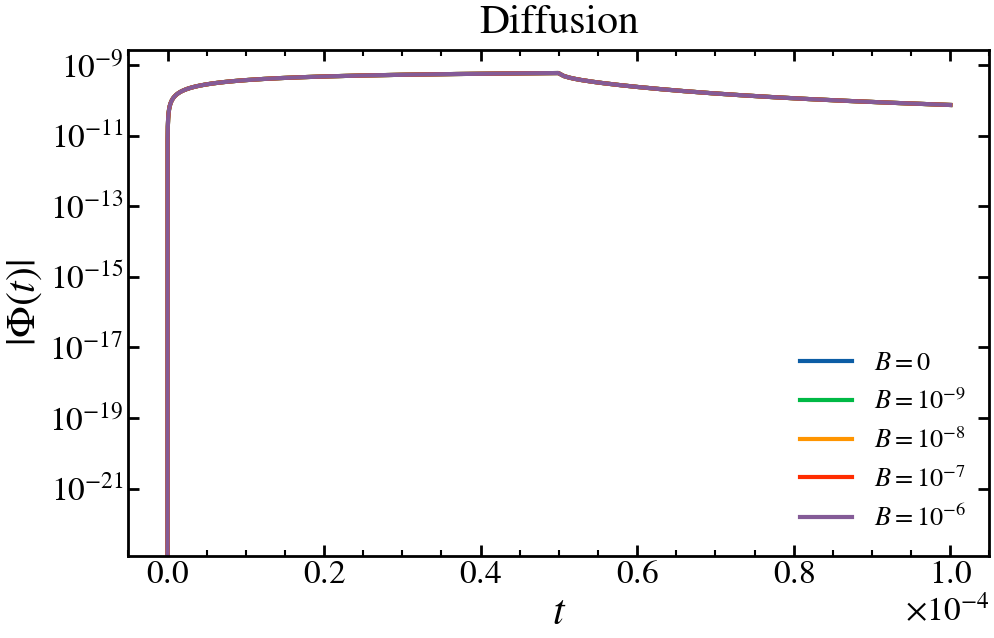

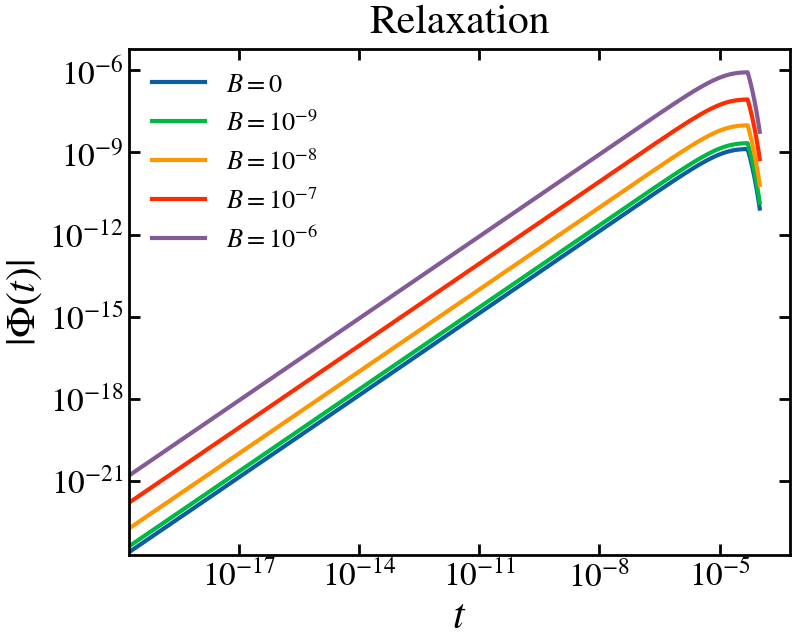

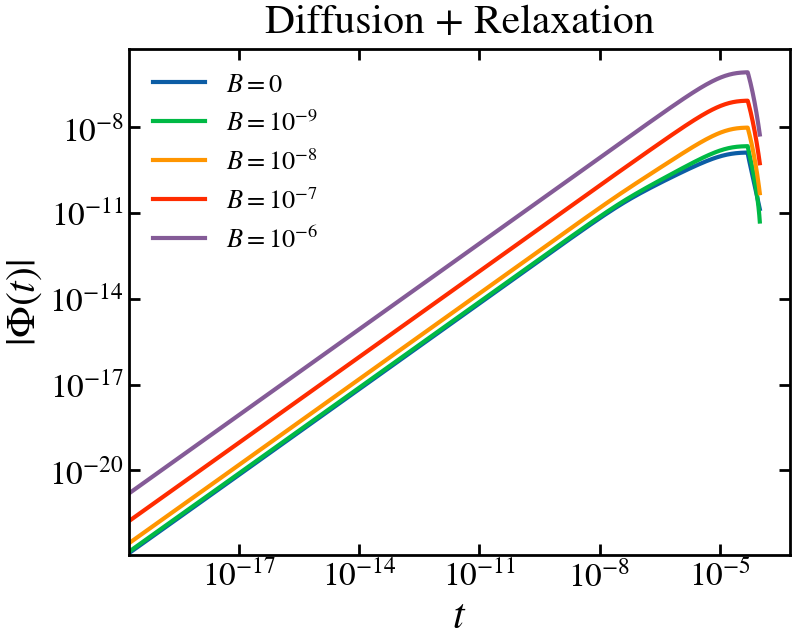

In [29]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ============================================================
# >>> EDIT THIS <<<
# ============================================================

FOLDER = "flux_data"   # <-- put the path to your data folder here, e.g. "data/run3"   # <-- put the path to your data folder here, e.g. "data/run3"

# ============================================================
# Naming convention
# ============================================================
# times_nofield_T1eTD.npy
# phidif_nofield_T1eTD.npy
# phirel_nofield_T1eTD.npy
# phiboth_nofield_T1eTD.npy
#
# times_field1e-9_T1eTD.npy
# phidif_field1e-9_T1eTD.npy
# phirel_field1e-9_T1eTD.npy
# phiboth_field1e-9_T1eTD.npy

SUFFIX = "T1eTD"  # change here if the trailing tag in filenames changes

data_dir = Path(FOLDER).expanduser().resolve()

TIMES_RE = re.compile(rf"^times_(?P<fieldtag>nofield|field.+)_{SUFFIX}\.npy$")


# ============================================================
# Discover datasets in FOLDER
# ============================================================

datasets = {}

for f in sorted(data_dir.glob(f"times_*_{SUFFIX}.npy")):
    m = TIMES_RE.match(f.name)
    if not m:
        continue
    fieldtag = m.group("fieldtag")

    if fieldtag == "nofield":
        B = 0.0
        label = r"$B=0$"
    else:
        value_str = fieldtag[len("field"):]
        try:
            B = float(value_str)
        except ValueError:
            print(f"  [warn] could not parse field value from '{fieldtag}', skipping {f.name}")
            continue
        exponent = round(np.log10(B)) if B > 0 else None
        if exponent is not None and np.isclose(B, 10.0 ** exponent, rtol=1e-6):
            label = rf"$B=10^{{{exponent}}}$"
        else:
            mantissa, exp = f"{B:.1e}".split("e")
            label = rf"$B={mantissa}\times10^{{{int(exp)}}}$"

    datasets[fieldtag] = {
        "fieldtag": fieldtag,
        "B": B,
        "label": label,
        "times": f,
        "phidif": None,
        "phirel": None,
        "phiboth": None,
    }

for prefix in ("phidif", "phirel", "phiboth"):
    for fieldtag, entry in datasets.items():
        candidate = data_dir / f"{prefix}_{fieldtag}_{SUFFIX}.npy"
        if candidate.exists():
            entry[prefix] = candidate
        else:
            print(f"  [warn] missing {candidate.name} for dataset '{fieldtag}'")

datasets = sorted(datasets.values(), key=lambda d: d["B"])

print(f"Found {len(datasets)} dataset(s) in {data_dir}:")
for d in datasets:
    print(f"  - {d['fieldtag']:<12} B={d['B']:<10} label={d['label']}")


# ============================================================
# Plot style
# ============================================================

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 19,

    "axes.linewidth": 2.0,

    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "legend.frameon": False,

    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})


# ============================================================
# Helper function
# ============================================================

def finish_plot(ax, title):

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$|\Phi(t)|$")
    ax.set_title(title, pad=12)

    formatter_x = ScalarFormatter(useMathText=True)
    formatter_x.set_scientific(True)
    formatter_x.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter_x)

    formatter_y = ScalarFormatter(useMathText=True)
    formatter_y.set_scientific(True)
    formatter_y.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter_y)

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=8,
        width=2,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=4,
        width=1.5,
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(
        fontsize=19,
        frameon=False
    )

    plt.tight_layout()


# ============================================================
# 1. DIFFUSION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

for entry in datasets:
    if entry["phidif"] is None:
        continue
    times = np.load(entry["times"])
    phi = np.load(entry["phidif"])
    ax.plot(times, np.abs(phi), lw=3, label=entry["label"])

finish_plot(ax, "Diffusion")
ax.semilogy()

plt.savefig(data_dir / "diffusion_constant.pdf")
plt.show()


# ============================================================
# 2. RELAXATION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for entry in datasets:
    if entry["phirel"] is None:
        continue
    times = np.load(entry["times"])
    phi = np.load(entry["phirel"])
    ax.plot(times, np.abs(phi), lw=3, label=entry["label"])

finish_plot(ax, "Relaxation")
ax.loglog()

plt.savefig(data_dir / "relaxation_constant.pdf")
plt.show()


# ============================================================
# 3. DIFFUSION + RELAXATION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for entry in datasets:
    if entry["phiboth"] is None:
        continue
    times = np.load(entry["times"])
    phi = np.load(entry["phiboth"])
    ax.plot(times, np.abs(phi), lw=3, label=entry["label"])

finish_plot(ax, "Diffusion + Relaxation")
ax.loglog()

plt.savefig(data_dir / "both_constant.pdf")
plt.show()

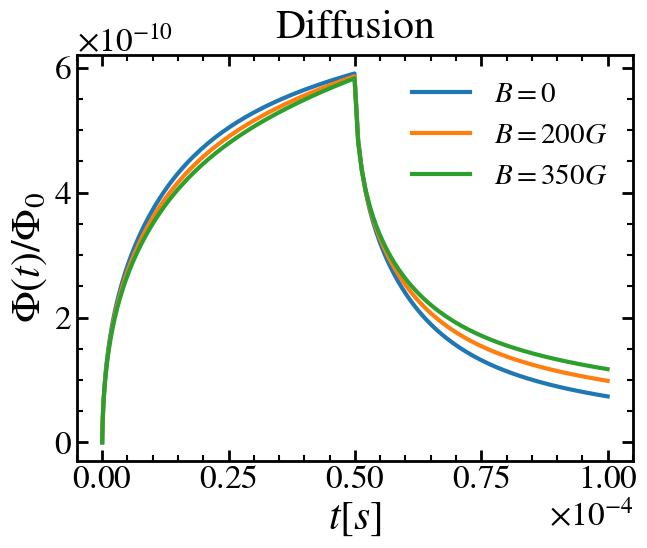

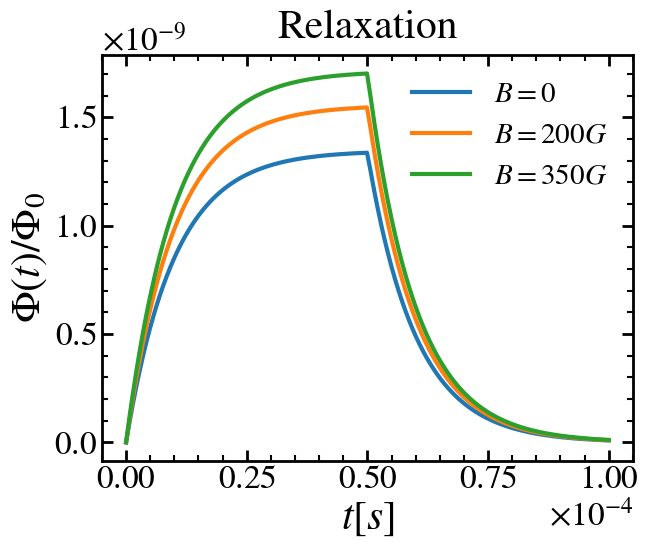

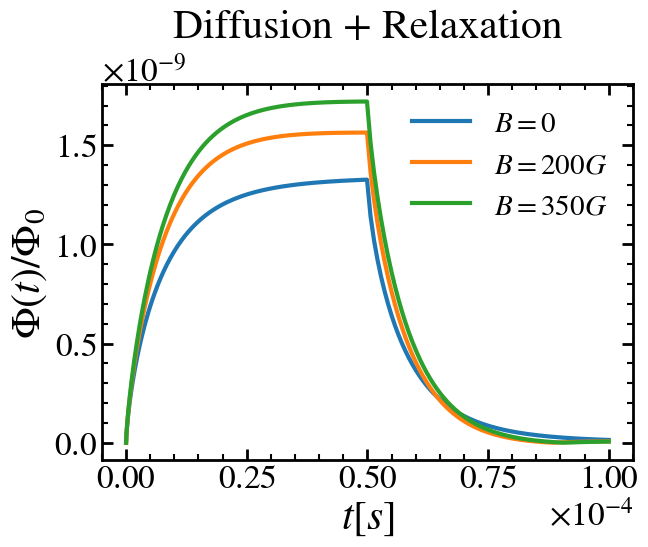

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ============================================================
# Load data
# ============================================================

times_nof = np.load("times_nofield_T1eTD.npy")
phi_dif_nof = np.load("phidif_nofield_T1eTD.npy")
phi_rel_nof = np.load("phirel_nofield_T1eTD.npy")
phi_both_nof = np.load("phiboth_nofield_T1eTD.npy")

times350 = np.load("times_grad350_T1eTD.npy")
phi_dif350 = np.load("phidif_grad350_T1eTD.npy")
phi_rel350 = np.load("phirel_grad350_T1eTD.npy")
phi_both350 = np.load("phiboth_grad350_T1eTD.npy")

times200 = np.load("times_grad200_T1eTD.npy")
phi_dif200 = np.load("phidif_grad200_T1eTD.npy")
phi_rel200 = np.load("phirel_grad200_T1eTD.npy")
phi_both200 = np.load("phiboth_grad200_T1eTD.npy")


# ============================================================
# Plot style
# ============================================================

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 21,

    "axes.linewidth": 2.0,

    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "legend.frameon": False,

    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})


def finish_plot(ax, title):

    ax.set_xlabel(r"$t[s]$")
    ax.set_ylabel(r"$\Phi(t)/\Phi_0$")
    ax.set_title(title, pad=12)

    # Scientific notation on x-axis
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    ax.xaxis.set_major_formatter(formatter)

    # Scientific notation on y-axis too if necessary
    formatter_y = ScalarFormatter(useMathText=True)
    formatter_y.set_scientific(True)
    formatter_y.set_powerlimits((0, 0))

    ax.yaxis.set_major_formatter(formatter_y)

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()
    ax.legend()
    plt.savefig(f"{title}.pdf")

    plt.tight_layout()


# ============================================================
# 1. DIFFUSION
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    times_nof, np.abs(phi_dif_nof),
    lw=3,
    label=r"$B=0$"
)

ax.plot(
    times200, np.abs(phi_dif200),
    lw=3,
    label=r"$B=200G$"
)

ax.plot(
    times350, np.abs(phi_dif350),
    lw=3,
    label=r"$B=350G$"
)

finish_plot(ax, "Diffusion")

plt.show()


# ============================================================
# 2. RELAXATION
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    times_nof, np.abs(phi_rel_nof),
    lw=3,
    label=r"$B=0$"
)

ax.plot(
    times200, np.abs(phi_rel200),
    lw=3,
    label=r"$B=200G$"
)

ax.plot(
    times350, np.abs(phi_rel350),
    lw=3,
    label=r"$B=350G$"
)

finish_plot(ax, "Relaxation")

plt.show()


# ============================================================
# 3. DIFFUSION + RELAXATION
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    times_nof, np.abs(phi_both_nof),
    lw=3,
    label=r"$B=0$"
)

ax.plot(
    times200, np.abs(phi_both200),
    lw=3,
    label=r"$B=200G$"
)

ax.plot(
    times350, np.abs(phi_both350),
    lw=3,
    label=r"$B=350G$"
)

finish_plot(ax, "Diffusion + Relaxation")

plt.show()

In [31]:
"""
Power-law fit of phi(t) = A * t^n for nofield relaxation/diffusion runs.

Expected file naming convention in `data_dir`:
    phi{kind}_nofield{ratio}_T1eTD.npy
    times_nofield{ratio}_T1eTD.npy

where:
    kind  in {"rel", "dif", "both"}
    ratio encodes T1/TD, e.g.:
        "nofield3"   -> T1 = 3   * TD
        "nofield05"  -> T1 = 0.5 * TD
        "nofield15"  -> T1 = 1.5 * TD   (ambiguous case, see _parse_ratio)

TD is fixed (see TD below). Adjust _parse_ratio if your convention for
leading-zero / multi-digit ratios differs from what's assumed here.

Fit window: t in (0, T1/7], using log-log linear regression
    ln(phi) = ln(A) + n * ln(t)
restricted to points where phi > 0 (power law fit is undefined/invalid
for phi <= 0). If too few valid points remain, that (kind, ratio) is
skipped with a printed warning.

In addition to the phi(t) log-log fit plots, this script also produces,
for each ratio, a plot of the numerical logarithmic derivative

    n_local(t) = d(ln|phi|) / d(ln t)

on a log-x scale. This is the "local" power-law exponent computed
directly from the data (via a centered finite difference in log-log
space), without assuming a single global power law. It's useful to see
where/if phi(t) actually behaves as a clean power law (n_local should be
roughly flat there) and to compare that plateau against the fitted n
from fit_power_law.
"""

import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration - edit these
# ============================================================

data_dir = "./flux_data"          # folder containing the .npy files
TD = 1e-5                    # fixed diffusion time constant
KINDS = ["rel", "dif", "both"]
KIND_LABELS = {"rel": "relaxation", "dif": "diffusion", "both": "both"}
MIN_POINTS_FOR_FIT = 4        # minimum number of points required to attempt a fit
m=15

out_dir = "./fit_plots"
os.makedirs(out_dir, exist_ok=True)

deriv_out_dir = "./fit_plots/log_derivative"
os.makedirs(deriv_out_dir, exist_ok=True)


# ============================================================
# Ratio parsing from filename fragment, e.g. "3" -> 3.0, "05" -> 0.5
# ============================================================

def _parse_ratio(ratio_str):
    """
    Convert the numeric fragment in the filename to a float T1/TD ratio.

    Convention assumed:
        - If the string starts with '0' and has length > 1, it is
          interpreted as a decimal: '05' -> 0.5, '025' -> 0.25.
        - Otherwise it's a plain integer/float string: '3' -> 3.0,
          '15' -> 15.0.

    IMPORTANT: if your convention differs (e.g. '15' should mean 1.5,
    not 15), edit this function accordingly -- this is inherently
    ambiguous without seeing your actual filenames.
    """
    if ratio_str.startswith("0") and len(ratio_str) > 1:
        # treat as decimal fraction: 0.<digits>
        return float("0." + ratio_str[1:])
    return float(ratio_str)


# ============================================================
# Discover files
# ============================================================

def discover_ratios(data_dir, kinds):
    """
    Scan data_dir for phi{kind}_nofield{ratio}_T1eTD.npy files and
    return a sorted list of unique ratio strings found (across all kinds),
    plus a dict: ratio_str -> {kind: phi_path}, and ratio_str -> times_path.
    """
    pattern = re.compile(r"^phi(" + "|".join(kinds) + r")_field([0-9]+)\.npy$")

    ratio_to_kind_files = {}
    ratio_to_times = {}

    for fpath in glob.glob(os.path.join(data_dir, "phi*_field*.npy")):
        fname = os.path.basename(fpath)
        m = pattern.match(fname)
        if not m:
            continue
        kind, ratio_str = m.group(1), m.group(2)
        ratio_to_kind_files.setdefault(ratio_str, {})[kind] = fpath

    for fpath in glob.glob(os.path.join(data_dir, "times_field*.npy")):
        fname = os.path.basename(fpath)
        m = re.match(r"^times_field([0-9]+)\.npy$", fname)
        if not m:
            continue
        ratio_str = m.group(1)
        ratio_to_times[ratio_str] = fpath

    ratio_strs = sorted(
        set(ratio_to_kind_files.keys()) & set(ratio_to_times.keys()),
        key=_parse_ratio
    )

    missing_times = set(ratio_to_kind_files.keys()) - set(ratio_to_times.keys())
    if missing_times:
        print(f"[warn] ratios with phi files but no matching times file, skipped: {sorted(missing_times)}")

    return ratio_strs, ratio_to_kind_files, ratio_to_times


# ============================================================
# Power-law fit: phi(t) = A * t^n  via log-log linear regression
# ============================================================

def fit_power_law(t, phi, t_max, T1):
    """
    Fit |phi| = A * t^n using points with 0 < t <= t_max and phi != 0.
    Returns (n, A, sign, mask_used).
    """
    tau=(T1+TD)/2
    mask = (t > 1e-2*min(T1,TD)) & (t <= t_max) & (phi != 0)

    if mask.sum() < MIN_POINTS_FOR_FIT:
        return None, None, None, mask

    phi_masked = np.abs(phi[mask])

    signs = np.sign(phi_masked)
    if not np.all(signs == signs[0]):
        print("[warn] phi changes sign within fit window; power-law fit "
              "on |phi| may not be meaningful here")
    sign = signs[0]

    logt = np.log(t[mask])
    logphi = np.log(np.abs(phi_masked))

    n, logA = np.polyfit(logt, logphi, 1)
    A = np.exp(logA)

    return n, A, sign, mask


# ============================================================
# Numerical logarithmic derivative: n_local(t) = d(ln|phi|)/d(ln t)
# ============================================================

def local_log_derivative(t, phi, t_min_cut):
    """
    Compute n_local(t) = d(ln|phi|)/d(ln t) via a centered finite
    difference on the (ln t, ln|phi|) curve.

    Only points with t > t_min_cut and phi != 0 are used (same spirit
    as the mask in fit_power_law, to avoid the noisy/singular region
    near t=0). Points are sorted by t before differentiating, and
    np.gradient is used so the derivative is defined at every kept
    point (forward/backward difference at the edges, centered inside).

    Returns (t_used, n_local) both sorted by increasing t. If fewer
    than 3 usable points remain, returns empty arrays.
    """
    mask = (t > t_min_cut) & (phi != 0)
    if mask.sum() < 3:
        return np.array([]), np.array([])

    t_m = t[mask]
    phi_m = phi[mask]

    order = np.argsort(t_m)
    t_m = t_m[order]
    phi_m = phi_m[order]

    logt = np.log(t_m)
    logphi = np.log(np.abs(phi_m))

    n_local = np.gradient(logphi, logt)

    return t_m, n_local


# ============================================================
# Main
# ============================================================

def main():
    ratio_strs, ratio_to_kind_files, ratio_to_times = discover_ratios(data_dir, KINDS)

    if not ratio_strs:
        print(f"No matching files found in {data_dir}. Check data_dir and naming convention.")
        return

    results = {kind: {"ratio": [], "n": [], "A": []} for kind in KINDS}

    for ratio_str in ratio_strs:
        ratio = _parse_ratio(ratio_str)
        T1 = ratio * TD
        t_max = T1 / m
        t_min_cut = 1e-5*TD

        times_path = ratio_to_times[ratio_str]
        t = np.load(times_path)

        kind_files = ratio_to_kind_files[ratio_str]

        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        any_plotted = False

        fig_d, ax_d = plt.subplots(figsize=(6.5, 4.5))
        any_deriv_plotted = False

        for kind in KINDS:
            if kind not in kind_files:
                continue

            phi = np.load(kind_files[kind])

            if phi.shape != t.shape:
                print(f"[warn] shape mismatch for ratio={ratio_str}, kind={kind}: "
                      f"phi {phi.shape} vs times {t.shape}, skipping")
                continue

            n, A, sign, mask = fit_power_law(t, phi, t_max, T1)

            ax.plot(t[t>1e-2*min(T1,TD)], np.abs(phi[t>1e-2*min(T1,TD)]), ".", ms=3, alpha=0.5, label=f"{KIND_LABELS[kind]} data")

            if n is not None:
                t_fit = t[mask]
                phi_fit = sign * A * t_fit**n
                ax.plot(t_fit, phi_fit, "-", lw=2, label=f"{KIND_LABELS[kind]} fit: n={n:.3f}")

                results[kind]["ratio"].append(ratio)
                results[kind]["n"].append(n)
                results[kind]["A"].append(A)
                any_plotted = True
            else:
                print(f"[warn] fit failed (not enough valid points) for "
                      f"ratio={ratio_str}, kind={kind}")

            # --- numerical log-log derivative (local exponent) ---
            t_d, n_local = local_log_derivative(t, phi, t_min_cut)
            if t_d.size > 0:
                ax_d.plot(t_d[t_d<4.9*T1], n_local[t_d<4.9*T1], ".-", ms=3, lw=1, alpha=0.8,
                          label=f"{KIND_LABELS[kind]} n_local(t)")
                if n is not None:
                    ax_d.axhline(n, color=ax_d.lines[-1].get_color(), ls="--", lw=1, alpha=0.6,
                                 label=f"{KIND_LABELS[kind]} fit n={n:.3f}")
                any_deriv_plotted = True
            else:
                print(f"[warn] not enough points for local derivative for "
                      f"ratio={ratio_str}, kind={kind}")

        ax.axvline(t_max, color="k", ls=":", lw=1, label=f"T1/{m:.0f} = {t_max:.2e}")
        ax.set_xlabel("t")
        ax.set_ylabel(r"$\phi(t)$")
        ax.set_title(f"T1/TD = {ratio}  (T1 = {T1:.2e})")
        ax.legend(fontsize=8)
        ax.loglog()
        ax.grid(alpha=0.3)

        if any_plotted:
            fig.tight_layout()
            fig.savefig(os.path.join(out_dir, f"fit_ratio_{ratio_str}.png"), dpi=140)
        plt.close(fig)

        # --- finalize numerical derivative plot for this ratio ---
        #ax_d.axvline(t_max, color="k", ls=":", lw=1, label=f"T1/{m:.0f} = {t_max:.2e}")
        ax_d.set_xlabel("t")
        ax_d.set_ylabel(r"$n_{\rm local}(t) = d\ln|\phi| / d\ln t$")
        ax_d.set_title(f"Local log-log slope of |phi(t)|,  T1/TD = {ratio}  (T1 = {T1:.2e})")
        ax_d.set_xscale("log")
        ax_d.legend(fontsize=7)
        ax_d.grid(alpha=0.3)

        if any_deriv_plotted:
            fig_d.tight_layout()
            fig_d.savefig(os.path.join(deriv_out_dir, f"logderiv_ratio_{ratio_str}.png"), dpi=140)
        plt.close(fig_d)

    # --------------------------------------------------------
    # Summary plot: n vs T1/TD, one curve per kind
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for kind in KINDS:
        r = np.array(results[kind]["ratio"])
        n_vals = np.array(results[kind]["n"])
        if len(r) == 0:
            continue
        order = np.argsort(r)
        ax.plot(r[order], n_vals[order], "o-", label=KIND_LABELS[kind])

    ax.set_xlabel(r"$T_1/T_D$")
    ax.set_ylabel("power-law exponent n")
    ax.set_title("Fitted exponent vs T1/TD")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "summary_n_vs_ratio.png"), dpi=140)
    plt.close(fig)

    print(f"Done. Per-ratio plots saved in: {out_dir}")
    print(f"Local log-log derivative plots saved in: {deriv_out_dir}")


if __name__ == "__main__":
    main()

[warn] ratios with phi files but no matching times file, skipped: ['5']
Done. Per-ratio plots saved in: ./fit_plots
Local log-log derivative plots saved in: ./fit_plots/log_derivative


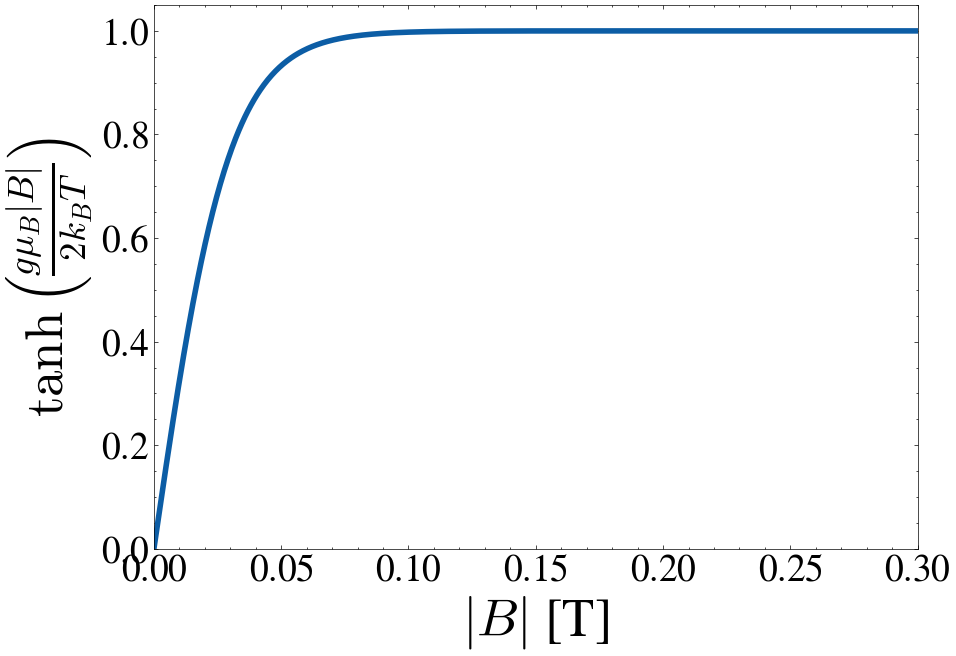

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k

# Parameters
T = 20e-3      # 20 mK
g = 2.0

# Magnetic field in Tesla
B = np.linspace(0, .3, 1000)

# Function
f = np.tanh(g * mu_B * np.abs(B) / (2 * k * T))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(B, f, linewidth=4)

ax.set_xlabel(r"$|B|$ [T]", fontsize=38)
ax.set_ylabel(
    r"$\tanh\left(\frac{g\mu_B |B|}{2k_B T}\right)$",
    fontsize=38
)

ax.tick_params(axis="both", which="major", labelsize=27)
ax.tick_params(axis="both", which="minor", labelsize=24)

ax.minorticks_on()

ax.set_xlim(0, 0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("eq.pdf")
plt.show()

### Analysis of power law and dynamics for different T1 and TD cases

In [ ]:
"""
Power-law fit of phi(t) = A * t^n for nofield relaxation/diffusion runs.

Expected file naming convention in `data_dir`:
    phi{kind}_nofield{ratio}_T1eTD.npy
    times_nofield{ratio}_T1eTD.npy

where:
    kind  in {"rel", "dif", "both"}
    ratio encodes T1/TD, e.g.:
        "nofield3"   -> T1 = 3   * TD
        "nofield05"  -> T1 = 0.5 * TD
        "nofield15"  -> T1 = 1.5 * TD   (ambiguous case, see _parse_ratio)

TD is fixed (see TD below). Adjust _parse_ratio if your convention for
leading-zero / multi-digit ratios differs from what's assumed here.

Fit window: t in (0, T1/7], using log-log linear regression
    ln(phi) = ln(A) + n * ln(t)
restricted to points where phi > 0 (power law fit is undefined/invalid
for phi <= 0). If too few valid points remain, that (kind, ratio) is
skipped with a printed warning.

In addition to the phi(t) log-log fit plots, this script also produces,
for each ratio, a plot of the numerical logarithmic derivative

    n_local(t) = d(ln|phi|) / d(ln t)

on a log-x scale. This is the "local" power-law exponent computed
directly from the data (via a centered finite difference in log-log
space), without assuming a single global power law. It's useful to see
where/if phi(t) actually behaves as a clean power law (n_local should be
roughly flat there) and to compare that plateau against the fitted n
from fit_power_law.

--------------------------------------------------------------------
Additional outputs produced by this version of the script:

1. Diffusion-only log-log derivative data (t, n_local) is saved to
   .npy files (one pair per ratio) under `dif_deriv_out_dir`, since
   this is the only kind whose local-derivative data gets persisted.

2. Overlay plot #1 ("rel_and_dif4" overlay): the diffusion curve for
   the T1 = 4*TD ratio (if that ratio exists among the "dif" files) is
   plotted together with *all* "rel"-only ratios in a single figure.
   Each rel ratio gets a vertical line at its own T1 (up to 4.9*T1),
   drawn in the same color as its curve. The diffusion T1=4TD curve
   does NOT get a vline. Produced for both phi(t) and the local
   log-log derivative.

3. Overlay plot #2 ("all_both" overlay): all "both"-kind ratios are
   plotted together in a single figure, each with a vline at its own
   T1 (up to 4.9*T1) in the same color as its curve. Produced for both
   phi(t) and the local log-log derivative.

Both overlay plots are saved under `overlay_out_dir` (./fit_plots/overlays).
"""

import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration - edit these
# ============================================================

data_dir = "./flux_data"          # folder containing the .npy files
TD = 1e-5                    # fixed diffusion time constant
KINDS = ["rel", "dif", "both"]
KIND_LABELS = {"rel": "relaxation", "dif": "diffusion", "both": "both"}
MIN_POINTS_FOR_FIT = 4        # minimum number of points required to attempt a fit
m=15

out_dir = "./fit_plots"
os.makedirs(out_dir, exist_ok=True)

deriv_out_dir = "./fit_plots/log_derivative"
os.makedirs(deriv_out_dir, exist_ok=True)

# diffusion-only local-derivative data (t, n_local) saved here as .npy
dif_deriv_out_dir = "./fit_plots/log_derivative/dif_data"
os.makedirs(dif_deriv_out_dir, exist_ok=True)

# new combined overlay plots (rel+dif4, and all-both)
overlay_out_dir = "./fit_plots/overlays"
os.makedirs(overlay_out_dir, exist_ok=True)

# T1/TD ratio (as a plain float) to use for the single diffusion curve
# overlaid on top of all the relaxation-only ratios.
DIF_OVERLAY_RATIO = 4.0

# ============================================================
# Plot style - bigger figures, bigger fonts (style-only settings)
# ============================================================

FIGSIZE = (6, 5)

plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "font.size": 16,
    "axes.titlesize": 17,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})


# ============================================================
# Ratio parsing from filename fragment, e.g. "3" -> 3.0, "05" -> 0.5
# ============================================================

def _parse_ratio(ratio_str):
    """
    Convert the numeric fragment in the filename to a float T1/TD ratio.

    Convention assumed:
        - If the string starts with '0' and has length > 1, it is
          interpreted as a decimal: '05' -> 0.5, '025' -> 0.25.
        - Otherwise it's a plain integer/float string: '3' -> 3.0,
          '15' -> 15.0.

    IMPORTANT: if your convention differs (e.g. '15' should mean 1.5,
    not 15), edit this function accordingly -- this is inherently
    ambiguous without seeing your actual filenames.
    """
    if ratio_str.startswith("0") and len(ratio_str) > 1:
        # treat as decimal fraction: 0.<digits>
        return float("0." + ratio_str[1:])
    return float(ratio_str)


# ============================================================
# Discover files
# ============================================================

def discover_ratios(data_dir, kinds):
    """
    Scan data_dir for phi{kind}_nofield{ratio}_T1eTD.npy files and
    return a sorted list of unique ratio strings found (across all kinds),
    plus a dict: ratio_str -> {kind: phi_path}, and ratio_str -> times_path.
    """
    pattern = re.compile(r"^phi(" + "|".join(kinds) + r")_field([0-9]+)\.npy$")

    ratio_to_kind_files = {}
    ratio_to_times = {}

    for fpath in glob.glob(os.path.join(data_dir, "phi*_field*.npy")):
        fname = os.path.basename(fpath)
        m = pattern.match(fname)
        if not m:
            continue
        kind, ratio_str = m.group(1), m.group(2)
        ratio_to_kind_files.setdefault(ratio_str, {})[kind] = fpath

    for fpath in glob.glob(os.path.join(data_dir, "times_field*.npy")):
        fname = os.path.basename(fpath)
        m = re.match(r"^times_field([0-9]+)\.npy$", fname)
        if not m:
            continue
        ratio_str = m.group(1)
        ratio_to_times[ratio_str] = fpath

    ratio_strs = sorted(
        set(ratio_to_kind_files.keys()) & set(ratio_to_times.keys()),
        key=_parse_ratio
    )

    missing_times = set(ratio_to_kind_files.keys()) - set(ratio_to_times.keys())
    if missing_times:
        print(f"[warn] ratios with phi files but no matching times file, skipped: {sorted(missing_times)}")

    return ratio_strs, ratio_to_kind_files, ratio_to_times


# ============================================================
# Power-law fit: phi(t) = A * t^n  via log-log linear regression
# ============================================================

def fit_power_law(t, phi, t_max, T1):
    """
    Fit |phi| = A * t^n using points with 0 < t <= t_max and phi != 0.
    Returns (n, A, sign, mask_used).
    """
    tau=(T1+TD)/2
    mask = (t > 1e-2*min(T1,TD)) & (t <= t_max) & (phi != 0)

    if mask.sum() < MIN_POINTS_FOR_FIT:
        return None, None, None, mask

    phi_masked = np.abs(phi[mask])

    signs = np.sign(phi_masked)
    if not np.all(signs == signs[0]):
        print("[warn] phi changes sign within fit window; power-law fit "
              "on |phi| may not be meaningful here")
    sign = signs[0]

    logt = np.log(t[mask])
    logphi = np.log(np.abs(phi_masked))

    n, logA = np.polyfit(logt, logphi, 1)
    A = np.exp(logA)

    return n, A, sign, mask


# ============================================================
# Numerical logarithmic derivative: n_local(t) = d(ln|phi|)/d(ln t)
# ============================================================

def local_log_derivative(t, phi, t_min_cut):
    """
    Compute n_local(t) = d(ln|phi|)/d(ln t) via a centered finite
    difference on the (ln t, ln|phi|) curve.

    Only points with t > t_min_cut and phi != 0 are used (same spirit
    as the mask in fit_power_law, to avoid the noisy/singular region
    near t=0). Points are sorted by t before differentiating, and
    np.gradient is used so the derivative is defined at every kept
    point (forward/backward difference at the edges, centered inside).

    Returns (t_used, n_local) both sorted by increasing t. If fewer
    than 3 usable points remain, returns empty arrays.
    """
    mask = (t > t_min_cut) & (phi != 0)
    if mask.sum() < 3:
        return np.array([]), np.array([])

    t_m = t[mask]
    phi_m = phi[mask]

    order = np.argsort(t_m)
    t_m = t_m[order]
    phi_m = phi_m[order]

    logt = np.log(t_m)
    logphi = np.log(np.abs(phi_m))

    n_local = np.gradient(logphi, logt)

    return t_m, n_local


# ============================================================
# Main
# ============================================================

def main():
    ratio_strs, ratio_to_kind_files, ratio_to_times = discover_ratios(data_dir, KINDS)

    if not ratio_strs:
        print(f"No matching files found in {data_dir}. Check data_dir and naming convention.")
        return

    results = {kind: {"ratio": [], "n": [], "A": []} for kind in KINDS}

    # --------------------------------------------------------
    # Storage for the new overlay plots, populated during the
    # per-ratio loop below.
    #   rel_overlay_data[ratio_str] = dict(t, phi, T1, t_d, n_local)
    #   dif4_overlay_data = dict(t, phi, T1, t_d, n_local)  (single ratio)
    #   both_overlay_data[ratio_str] = dict(t, phi, T1, t_d, n_local)
    # --------------------------------------------------------
    rel_overlay_data = {}
    dif4_overlay_data = None
    both_overlay_data = {}

    for ratio_str in ratio_strs:
        ratio = _parse_ratio(ratio_str)
        T1 = ratio * TD
        t_max = T1 / m
        t_min_cut = 1e-5*TD

        times_path = ratio_to_times[ratio_str]
        t = np.load(times_path)

        kind_files = ratio_to_kind_files[ratio_str]

        fig, ax = plt.subplots(figsize=FIGSIZE)
        any_plotted = False

        fig_d, ax_d = plt.subplots(figsize=FIGSIZE)
        any_deriv_plotted = False

        for kind in KINDS:
            if kind not in kind_files:
                continue

            phi = np.load(kind_files[kind])

            if phi.shape != t.shape:
                print(f"[warn] shape mismatch for ratio={ratio_str}, kind={kind}: "
                      f"phi {phi.shape} vs times {t.shape}, skipping")
                continue

            n, A, sign, mask = fit_power_law(t, phi, t_max, T1)

            ax.plot(t[t>1e-2*min(T1,TD)], np.abs(phi[t>1e-2*min(T1,TD)]), ".", ms=3, alpha=0.5, label=f"{KIND_LABELS[kind]} data")

            if n is not None:
                t_fit = t[mask]
                phi_fit = sign * A * t_fit**n
                ax.plot(t_fit, phi_fit, "-", lw=2, label=f"{KIND_LABELS[kind]} fit: n={n:.3f}")

                results[kind]["ratio"].append(ratio)
                results[kind]["n"].append(n)
                results[kind]["A"].append(A)
                any_plotted = True
            else:
                print(f"[warn] fit failed (not enough valid points) for "
                      f"ratio={ratio_str}, kind={kind}")

            # --- numerical log-log derivative (local exponent) ---
            t_d, n_local = local_log_derivative(t, phi, t_min_cut)
            if t_d.size > 0:
                ax_d.plot(t_d[t_d<4.9*T1], n_local[t_d<4.9*T1], ".-", ms=3, lw=1, alpha=0.8,
                          label=f"{KIND_LABELS[kind]} n_local(t)")
                if n is not None:
                    ax_d.axhline(n, color=ax_d.lines[-1].get_color(), ls="--", lw=1, alpha=0.6,
                                 label=f"{KIND_LABELS[kind]} fit n={n:.3f}")
                any_deriv_plotted = True
            else:
                print(f"[warn] not enough points for local derivative for "
                      f"ratio={ratio_str}, kind={kind}")

            # --- stash data for overlay plots below ---
            if kind == "rel":
                rel_overlay_data[ratio_str] = dict(
                    t=t, phi=phi, T1=T1, t_d=t_d, n_local=n_local
                )
            elif kind == "dif":
                # save diffusion-only local-derivative data to .npy
                np.save(os.path.join(dif_deriv_out_dir, f"tderiv_dif_ratio_{ratio_str}.npy"), t_d)
                np.save(os.path.join(dif_deriv_out_dir, f"nlocal_dif_ratio_{ratio_str}.npy"), n_local)

                if np.isclose(ratio, DIF_OVERLAY_RATIO):
                    dif4_overlay_data = dict(
                        t=t, phi=phi, T1=T1, t_d=t_d, n_local=n_local
                    )
            elif kind == "both":
                both_overlay_data[ratio_str] = dict(
                    t=t, phi=phi, T1=T1, t_d=t_d, n_local=n_local
                )

        ax.axvline(t_max, color="k", ls=":", lw=1, label=f"T1/{m:.0f} = {t_max:.2e}")
        ax.set_xlabel("t")
        ax.set_ylabel(r"$\phi(t)$")
        ax.set_title(f"T1/TD = {ratio}  (T1 = {T1:.2e})")
        ax.legend(fontsize=12)
        ax.loglog()
        ax.grid(alpha=0.3)

        if any_plotted:
            fig.tight_layout()
            fig.savefig(os.path.join(out_dir, f"fit_ratio_{ratio_str}.png"), dpi=140)
        plt.close(fig)

        # --- finalize numerical derivative plot for this ratio ---
        #ax_d.axvline(t_max, color="k", ls=":", lw=1, label=f"T1/{m:.0f} = {t_max:.2e}")
        ax_d.set_xlabel("t")
        ax_d.set_ylabel(r"$n_{\rm local}(t) = d\ln|\phi| / d\ln t$")
        ax_d.set_title(f"Local log-log slope of |phi(t)|,  T1/TD = {ratio}  (T1 = {T1:.2e})")
        ax_d.set_xscale("log")
        ax_d.legend(fontsize=12)
        ax_d.grid(alpha=0.3)

        if any_deriv_plotted:
            fig_d.tight_layout()
            fig_d.savefig(os.path.join(deriv_out_dir, f"logderiv_ratio_{ratio_str}.png"), dpi=140)
        plt.close(fig_d)

    # --------------------------------------------------------
    # Summary plot: n vs T1/TD, one curve per kind
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for kind in KINDS:
        r = np.array(results[kind]["ratio"])
        n_vals = np.array(results[kind]["n"])
        if len(r) == 0:
            continue
        order = np.argsort(r)
        ax.plot(r[order], n_vals[order], "o-", label=KIND_LABELS[kind])

    ax.set_xlabel(r"$T_1/T_D$")
    ax.set_ylabel("power-law exponent n")
    ax.set_title("Fitted exponent vs T1/TD")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "summary_n_vs_ratio.png"), dpi=140)
    plt.close(fig)

    # ==========================================================
    # Overlay plot #1: diffusion T1=4*TD (no vline) + ALL relaxation
    # ratios (each with its own vline, same color as its curve).
    # One figure for phi(t), one for the local log-log derivative.
    # ==========================================================
    if not rel_overlay_data and dif4_overlay_data is None:
        print("[warn] no 'rel' ratios and no dif T1=4*TD found; skipping rel+dif4 overlay plots")
    else:
        rel_ratio_strs_sorted = sorted(rel_overlay_data.keys(), key=_parse_ratio)

        # --- phi(t) overlay ---
        fig, ax = plt.subplots(figsize=FIGSIZE)

        if dif4_overlay_data is not None:
            d = dif4_overlay_data
            t_, phi_, T1_ = d["t"], d["phi"], d["T1"]
            sel = t_ < 4.9 * T1_
            ax.plot(t_[sel], np.abs(phi_[sel]), "-", lw=2, alpha=0.8,
                    label=f"Diffusion")

        for ratio_str in rel_ratio_strs_sorted:
            d = rel_overlay_data[ratio_str]
            t_, phi_, T1_ = d["t"], d["phi"], d["T1"]
            sel = t_ < 4.9 * T1_
            line, = ax.plot(t_[sel], np.abs(phi_[sel]), "-", lw=1.5, alpha=0.8,
                             label=rf"Relaxation $T_1/\tau_D$={_parse_ratio(ratio_str):g}")
            ax.axvline(T1_, color=line.get_color(), ls="--", lw=1, alpha=0.7)

        ax.set_xlabel("t")
        ax.set_ylabel(r"$|\phi(t)|$")
        #ax.set_title(f"Diffusion + all relaxation ratios")
        ax.loglog()
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(overlay_out_dir, "overlay_rel_and_dif4_phi.png"), dpi=140)
        plt.close(fig)

        # --- local log-log derivative overlay ---
        fig, ax = plt.subplots(figsize=FIGSIZE)

        if dif4_overlay_data is not None:
            d = dif4_overlay_data
            t_d, n_local, T1_ = d["t_d"], d["n_local"], d["T1"]
            if t_d.size > 0:
                sel = t_d < 4.9 * T1_
                ax.plot(t_d[sel], n_local[sel], ".-", ms=3, lw=1, alpha=0.8,
                        label=f"diffusion")

        for ratio_str in rel_ratio_strs_sorted:
            d = rel_overlay_data[ratio_str]
            t_d, n_local, T1_ = d["t_d"], d["n_local"], d["T1"]
            if t_d.size == 0:
                continue
            sel = t_d < 4.9 * T1_
            line, = ax.plot(t_d[sel], n_local[sel], ".-", ms=3, lw=1, alpha=0.8,
                             label=rf"Relaxation $T_1/\tau_D$={_parse_ratio(ratio_str):g}")
            ax.axvline(T1_, color=line.get_color(), ls="--", lw=1, alpha=0.7)

        ax.set_xlabel("t[s]")
        ax.set_ylabel(r"$p_{\rm local}(t) = d\ln|\phi| / d\ln t$")
        #ax.set_title(f"Local slope: diffusion + all relaxation ratios")
        ax.set_xscale("log")
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(overlay_out_dir, "overlay_rel_and_dif4_logderiv.png"), dpi=140)
        plt.close(fig)

    # ==========================================================
    # Overlay plot #2: ALL "both"-kind ratios in one plot, each with
    # its own vline at T1 (same color as its curve). One figure for
    # phi(t), one for the local log-log derivative.
    # ==========================================================
    if not both_overlay_data:
        print("[warn] no 'both' ratios found; skipping all-both overlay plots")
    else:
        both_ratio_strs_sorted = sorted(both_overlay_data.keys(), key=_parse_ratio)

        # --- phi(t) overlay ---
        fig, ax = plt.subplots(figsize=FIGSIZE)
        for ratio_str in both_ratio_strs_sorted:
            d = both_overlay_data[ratio_str]
            t_, phi_, T1_ = d["t"], d["phi"], d["T1"]
            sel = t_ < 4.9 * T1_
            line, = ax.plot(t_[sel], np.abs(phi_[sel]), "-", lw=1.5, alpha=0.8,
                             label=f"both T1/TD={_parse_ratio(ratio_str):g}")
            ax.axvline(T1_, color=line.get_color(), ls="--", lw=1, alpha=0.7)

        ax.set_xlabel("t")
        ax.set_ylabel(r"$|\phi(t)|$")
        #ax.set_title("All 'both' ratios overlaid")
        ax.loglog()
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(overlay_out_dir, "overlay_all_both_phi.png"), dpi=140)
        plt.close(fig)

        # --- local log-log derivative overlay ---
        fig, ax = plt.subplots(figsize=FIGSIZE)
        for ratio_str in both_ratio_strs_sorted:
            d = both_overlay_data[ratio_str]
            t_d, n_local, T1_ = d["t_d"], d["n_local"], d["T1"]
            if t_d.size == 0:
                continue
            sel = t_d < 4.9 * T1_
            line, = ax.plot(t_d[sel], n_local[sel], ".-", ms=3, lw=1, alpha=0.8,
                             label=rf"Both $T_1/\tau_D$={_parse_ratio(ratio_str):g}")
            ax.axvline(T1_, color=line.get_color(), ls="--", lw=1, alpha=0.7)

        ax.set_xlabel("t[s]")
        ax.set_ylabel(r"$p_{\rm local}(t) = d\ln|\phi| / d\ln t$")
        #ax.set_title("Local slope: all 'both' ratios overlaid")
        ax.set_xscale("log")
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(overlay_out_dir, "overlay_all_both_logderiv.png"), dpi=140)
        plt.close(fig)

    print(f"Done. Per-ratio plots saved in: {out_dir}")
    print(f"Local log-log derivative plots saved in: {deriv_out_dir}")
    print(f"Diffusion-only local-derivative .npy data saved in: {dif_deriv_out_dir}")
    print(f"Overlay plots saved in: {overlay_out_dir}")


if __name__ == "__main__":
    main()

[warn] ratios with phi files but no matching times file, skipped: ['5']
Done. Per-ratio plots saved in: ./fit_plots
Local log-log derivative plots saved in: ./fit_plots/log_derivative
Diffusion-only local-derivative .npy data saved in: ./fit_plots/log_derivative/dif_data
Overlay plots saved in: ./fit_plots/overlays


#Solomon final

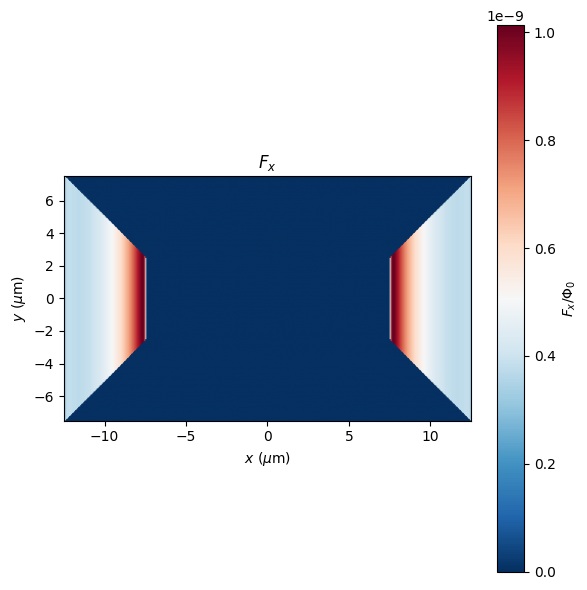

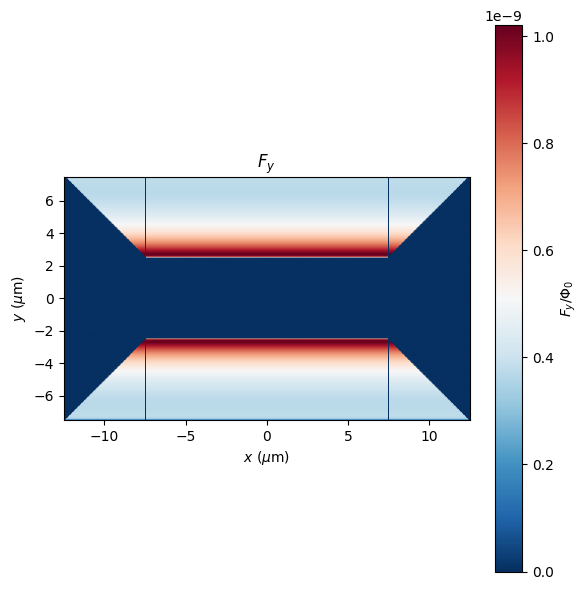

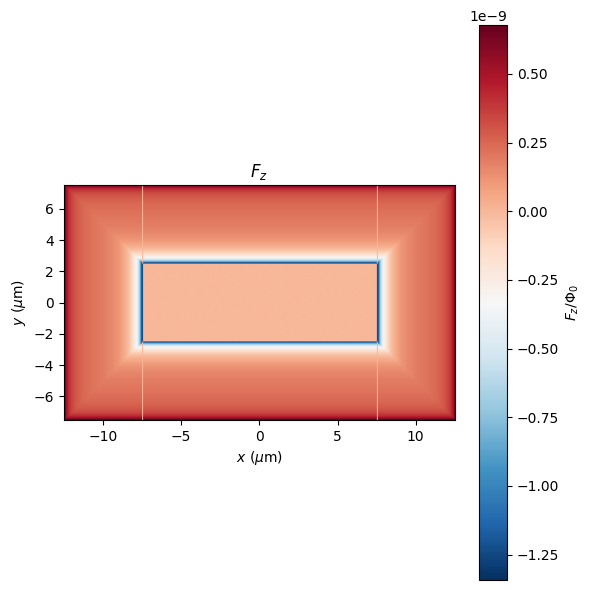

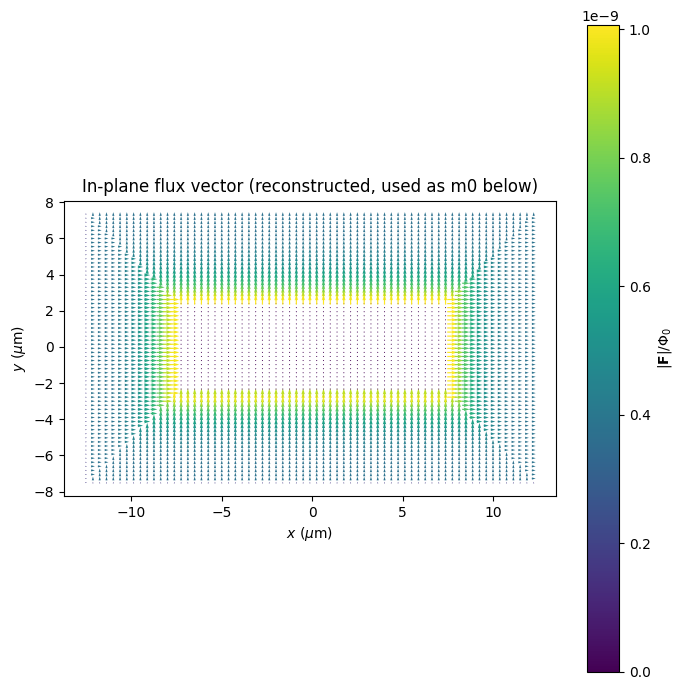

In [ ]:
# ============================================================
# PART 1: Reconstruct 2D flux field from strip profiles
# (unchanged from your original code — produces Fx, Fy, Fz
#  on grid X, Y with shape (Ny, Nx), meshgrid(x, y) 'xy' indexing)
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator

sigmam2=5e17#meters^-2
sigma=sigmam2*1e-12#micrometers^-2

W_um=5

# choose which geometry
Lx = 15          # one of the values in "files"
Ly = 5           # fixed

halfLx = Lx / 2
halfLy = Ly / 2

strip_width = W_um

# plotting domain
margin = W_um

Nx_flux, Ny_flux = 401, 401

x_flux = np.linspace(-halfLx - margin, halfLx + margin, Nx_flux)
y_flux = np.linspace(-halfLy - margin, halfLy + margin, Ny_flux)

X_flux, Y_flux = np.meshgrid(x_flux, y_flux)  # shape (Ny_flux, Nx_flux), 'xy' indexing

Fx = np.zeros_like(X_flux)
Fy = np.zeros_like(X_flux)
Fz = np.zeros_like(X_flux)

# ============================================================
# Masks defining the four strips
# (corners intentionally ignored)
# ============================================================

corner = strip_width / 2

mask_left = (
    (np.abs(X_flux + halfLx + strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_right = (
    (np.abs(X_flux - halfLx - strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_bottom = (
    (np.abs(Y_flux + halfLy + strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

mask_top = (
    (np.abs(Y_flux - halfLy - strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

# top and right must have a flip because current flows against the convention
# ============================================================
# LEFT ARM
# ============================================================

d = X_flux[mask_left] + halfLx + W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_left] = Fx_tmp
Fz[mask_left] = Fz_tmp

# ============================================================
# RIGHT ARM
# ============================================================

d = X_flux[mask_right] - halfLx - W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_right] = np.flip(Fx_tmp)
Fz[mask_right] = np.flip(Fz_tmp)

# ============================================================
# BOTTOM ARM
# ============================================================

d = Y_flux[mask_bottom] + halfLy + W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_bottom] = Fy_tmp
Fz[mask_bottom] = Fz_tmp

# ============================================================
# TOP ARM
# ============================================================

d = Y_flux[mask_top] - halfLy - W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_top] = np.flip(Fy_tmp)
Fz[mask_top] = np.flip(Fz_tmp)

# ============================================================
# Fill the four corners by interpolating from strip data
# ============================================================

mask_corner_bl = (X_flux < -halfLx) & (Y_flux < -halfLy)
mask_corner_br = (X_flux > halfLx) & (Y_flux < -halfLy)
mask_corner_tl = (X_flux < -halfLx) & (Y_flux > halfLy)
mask_corner_tr = (X_flux > halfLx) & (Y_flux > halfLy)

corner_masks = {
    "bottom_left": mask_corner_bl,
    "bottom_right": mask_corner_br,
    "top_left": mask_corner_tl,
    "top_right": mask_corner_tr,
}

data_mask = mask_left | mask_right | mask_top | mask_bottom
pts_known = np.column_stack([X_flux[data_mask], Y_flux[data_mask]])

for name, cmask in corner_masks.items():
    if not np.any(cmask):
        continue
    pts_query = np.column_stack([X_flux[cmask], Y_flux[cmask]])
    for field, arr in (("Fx", Fx), ("Fy", Fy), ("Fz", Fz)):
        vals_known = arr[data_mask]
        interp_vals = griddata(pts_known, vals_known, pts_query, method="nearest")
        nan_mask = np.isnan(interp_vals)
        if np.any(nan_mask):
            interp_vals[nan_mask] = griddata(
                pts_known, vals_known, pts_query[nan_mask], method="nearest"
            )
        arr[cmask] = interp_vals

# (Optional) diagnostic plots of Fx, Fy, Fz and the in-plane vector field
# — kept exactly as before, just wrapped so they don't block execution.

def _plot_field(field, name, symbol):
    plt.figure(figsize=(6, 6))
    plt.imshow(
        field, origin="lower",
        extent=[x_flux.min(), x_flux.max(), y_flux.min(), y_flux.max()],
        cmap="RdBu_r", aspect="equal",
    )
    plt.colorbar(label=rf"${symbol}/\Phi_0$")
    plt.xlabel(r"$x\ (\mu{\rm m})$")
    plt.ylabel(r"$y\ (\mu{\rm m})$")
    plt.title(rf"${symbol}$")
    plt.tight_layout()

_plot_field(Fx, "Fx", "F_x")
_plot_field(Fy, "Fy", "F_y")
_plot_field(Fz, "Fz", "F_z")

step = 6
plt.figure(figsize=(7, 7))
plt.quiver(
    X_flux[::step, ::step], Y_flux[::step, ::step],
    Fx[::step, ::step], Fy[::step, ::step],
    np.sqrt(Fx[::step, ::step] ** 2 + Fy[::step, ::step] ** 2),
    cmap="viridis", pivot="mid",
)
plt.gca().set_aspect("equal")
plt.xlabel(r"$x\ (\mu{\rm m})$")
plt.ylabel(r"$y\ (\mu{\rm m})$")
plt.title("In-plane flux vector (reconstructed, used as m0 below)")
plt.colorbar(label=r"$|\mathbf{F}|/\Phi_0$")
plt.tight_layout()


# ============================================================
# PART 2: 2D vector diffusion on a rectangular loop,
# initialized with m0 = (Fx, Fy, Fz) from Part 1
# ============================================================

from diffusion2d_complete import (
    build_rectangular_loop_mask,
    solve_diffusion_2d_loop,
    max_stable_dt, build_nonuniform_time_grid,
)

Nx, Ny = 120, 120

# domain_size is set from the flux grid itself so both fields live on
# compatible (µm) coordinates and the interpolation in Part 1 -> Part 2
# actually overlaps.
domain_size = 2 * max(halfLx + margin, halfLy + margin)

x = np.linspace(-domain_size / 2, domain_size / 2, Nx)
y = np.linspace(-domain_size / 2, domain_size / 2, Ny)
dx, dy = x[1] - x[0], y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing="ij")  # shape (Nx, Ny), 'ij' indexing

Lx_outer, Ly_outer = Lx + 2 * W_um, Ly + 2 * W_um
mask = build_rectangular_loop_mask(X, Y, Lx_outer, Ly_outer, W_um)


# ------------------------------------------------------------
# Build m0 by interpolating the reconstructed (Fx, Fy, Fz) field
# from Part 1's grid (X_flux, Y_flux) onto Part 2's grid (X, Y).
#
# Part 1 used meshgrid(x_flux, y_flux) with default 'xy' indexing,
# so Fx/Fy/Fz have shape (Ny_flux, Nx_flux) and are indexed [row=y, col=x].
# RegularGridInterpolator wants strictly increasing axes in the order
# matching the array's own indexing, so we build it as (y_flux, x_flux) -> value,
# then query at each (X, Y) point of Part 2's grid, which uses 'ij' indexing
# (shape (Nx, Ny), indexed [x, y]).
# ------------------------------------------------------------

def interp_to_target_grid(field_xy_indexed, y_source, x_source, X_target, Y_target):
    """field_xy_indexed: array of shape (len(y_source), len(x_source))."""
    interpolator = RegularGridInterpolator(
        (y_source, x_source), field_xy_indexed,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    query_pts = np.column_stack([Y_target.ravel(), X_target.ravel()])
    return interpolator(query_pts).reshape(X_target.shape)

Fx_on_target = interp_to_target_grid(Fx, y_flux, x_flux, X, Y)
Fy_on_target = interp_to_target_grid(Fy, y_flux, x_flux, X, Y)
Fz_on_target = interp_to_target_grid(Fz, y_flux, x_flux, X, Y)
Fx_on_target = Fx_on_target*phi0*1e12#um units
Fy_on_target = Fy_on_target*phi0*1e12
Fz_on_target = Fz_on_target*phi0*1e12

B0 = 350.0            # Gauss
B0 *= 1e-4            # Tesla

R_cm = .4

X_cm = X * 1e-4
Y_cm = Y * 1e-4

Bext_y = B0 * (
    (1.0 + (Y_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (Y_cm/R_cm + 0.5)**2)**(-1.5)
)

Bext_x = B0 * (
    (1.0 + (X_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (X_cm/R_cm + 0.5)**2)**(-1.5)
)


F = np.zeros((Nx, Ny, 3))
F[..., 0] = Fx_on_target#0.
F[..., 1] = Fy_on_target
F[..., 2] = Fz_on_target

Fmag=np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)

m0 = np.zeros((Nx, Ny, 3))
m0[..., 0] = 0#1*Fx_on_target#np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)
m0[..., 1] = 0#1*Fy_on_target#Fy_on_target
m0[..., 2] = 0#1*Fz_on_target#Fz_on_target
#m0[..., 0]=0.1

mu_B_nAum2 = 9.2740100657e-24 * 1e21
Ip_nA=6.3
B_static = np.zeros((Nx, Ny, 3))
B_static[..., 0] = Fx_on_target*Ip_nA/mu_B_nAum2+3.6e-3#+Bext_x#0.
B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.#+0.002
B_static[..., 2] = Fz_on_target*Ip_nA/mu_B_nAum2

# B_static[..., 0] = 0.04#Bext_x#0.
# B_static[..., 1] = 0.#+0.002
# B_static[..., 2] = 0.

#B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.002

Bmag=np.sqrt(B_static[..., 0]**2+B_static[..., 1]**2+B_static[..., 2]**2)
np.savetxt('Bmag.csv', Bmag, delimiter=',')
T1=10e-6*1
a=1.5
TD=T1/1
D, T = a**2/TD, 20e-3

"""
Qubit + spatially-distributed spin-TLS bath population dynamics.

Solves the coupled rate equations

    dot(p_q)   = -Gamma_q  * (p_q      - p_q^th)      - sigma * Integral d^2x Gamma_qt(x) * (p_q - p_t(x))
    dot(p_t)(x)= -Gamma_1  * (p_t(x)   - p_t^th(x))    - Gamma_qt(x) * (p_t(x) - p_q)

with

    Gamma_1        = 1 / T1
    Gamma_qt(x)    = 2 g^2 Gamma_2 / (Gamma_2^2 + delta(x)^2)
    delta(x)       = 2*omega_0 - gamma * |B(x)|
    Gamma_2        = Gamma_2q + Gamma_2t = (Gamma_1 + Gamma_q) / 2
    gamma          = mu_B / hbar   (electron spin gyromagnetic ratio, rad/s/T)

p_q^th and p_t^th(x) are two-level-system Boltzmann excited-state
populations at temperature T, evaluated at the qubit frequency omega_0
and at the local spin-TLS Larmor frequency gamma*|B(x)| respectively.

UNITS
-----
- B_static must be supplied in Tesla, on a grid (X, Y) given in micrometers.
- All rates (Gamma_1, Gamma_q, Gamma_qt, Gamma_2) and omega_0, delta are in rad/s.
- gamma is computed in SI (rad/s/T) so that gamma*|B[T]| is directly in rad/s,
  matching omega_0. No unit conversion of B itself is needed.
- sigma is a 2D trap density - it must be supplied in um^-2 so that
  sigma * (cell area in um^2) is dimensionless (a number of traps per cell).
  The spatial grid (X, Y) is used in um for exactly this reason: the
  integral sigma * Integral d^2x (...) is evaluated as sigma * sum(...) * dx * dy
  with dx, dy in um.
"""

import numpy as np
from scipy.integrate import solve_ivp

# ------------------------------------------------------------------
# Physical constants (SI)
# ------------------------------------------------------------------
HBAR = 1.054571817e-34      # J s
MU_B = 9.2740100657e-24     # J / T
KB = 1.380649e-23           # J / K
GAMMA_E = MU_B / HBAR       # rad s^-1 T^-1  (electron spin gyromagnetic ratio)


def thermal_excited_population(omega, T):
    """
    Two-level-system Boltzmann excited-state population.

    p^th = 1 / (1 + exp(hbar*omega / (kB*T)))

    omega : angular frequency (rad/s), scalar or array. Must be >= 0
            (use abs(omega) if a signed detuning-like quantity is passed).
    T     : temperature (K), scalar.

    Returns array/scalar of same shape as omega, valued in (0, 0.5].
    """
    omega = np.asarray(omega, dtype=float)
    x = HBAR * np.abs(omega) / (KB * T)
    # numerically safe for large x (avoids overflow in exp)
    return np.where(x > 700, 0.0, 1.0 / (1.0 + np.exp(np.clip(x, None, 700))))


def build_qubit_tls_rhs(
    B_static,      # (Nx, Ny, 3) array, Tesla
    X, Y,           # (Nx, Ny) grids, micrometers
    mask,           # (Nx, Ny) boolean, True where loop material exists
    sigma,          # trap density, um^-2
    omega_0,        # qubit angular frequency, rad/s
    Gamma_q,        # qubit "extra" decay/dephasing-type rate, rad/s (i.e. 1/s)
    g,              # qubit-TLS coupling, rad/s
    T1,             # spin-TLS relaxation time, s
    T=20e-3,        # temperature, K
):
    """
    Build and return:
      rhs(t, state) -> dstate/dt     for use with scipy.integrate.solve_ivp
      pack(p_q, p_t) -> state
      unpack(state)  -> (p_q, p_t)
      info dict with precomputed fields (Gamma_qt map, thermal pops, etc.)

    state layout: state[0] = p_q ; state[1:] = p_t.ravel() (only over mask
    points -- points outside the mask are excluded from the integral and
    from the ODE system, since there is no TLS bath material there).
    """
    dx = X[1, 0] - X[0, 0]
    dy = Y[0, 1] - Y[0, 0]
    cell_area = dx * dy  # um^2
    #np.savetxt('B.csv', Bmag, delimiter=',')

    Bmag = np.sqrt(np.sum(B_static ** 2, axis=-1))  # Tesla, shape (Nx, Ny)
    np.savetxt('Bmag.csv', Bmag, delimiter=',')

    # Only evolve p_t where there is actually loop material (mask == True).
    idx = np.where(mask.ravel())[0]
    n_t = idx.size

    Bmag_flat = Bmag.ravel()[idx]

    Gamma_1 = 1.0 / T1
    Gamma_2 = (Gamma_1 + Gamma_q) / 2.0

    delta = 2.0 * omega_0 - GAMMA_E * Bmag_flat            # rad/s, shape (n_t,)
    Gamma_qt = 2.0 * g ** 2 * Gamma_2 / (Gamma_2 ** 2 + delta ** 2)  # rad/s (1/s)

    p_q_th = thermal_excited_population(omega_0, T)                 # scalar
    p_t_th = thermal_excited_population(GAMMA_E * Bmag_flat, T)      # shape (n_t,)

    def pack(p_q, p_t_full):
        state = np.empty(1 + n_t)
        state[0] = p_q
        state[1:] = p_t_full.ravel()[idx]
        return state

    def unpack(state, fill_value=np.nan):
        p_q = state[0]
        p_t_full = np.full(mask.shape, fill_value)
        p_t_full.ravel()[idx] = state[1:]
        return p_q, p_t_full

    def rhs(t, state):
        p_q = state[0]
        p_t = state[1:]  # shape (n_t,)

        dpq_dt = (
            -Gamma_q * (p_q - p_q_th)
            - sigma * np.sum(Gamma_qt * (p_q - p_t)) * cell_area
        )

        dpt_dt = -Gamma_1 * (p_t - p_t_th) - Gamma_qt * (p_t - p_q)

        dstate = np.empty_like(state)
        dstate[0] = dpq_dt
        dstate[1:] = dpt_dt
        return dstate

    info = dict(
        Gamma_1=Gamma_1,
        Gamma_2=Gamma_2,
        Gamma_qt=Gamma_qt,
        delta=delta,
        p_q_th=p_q_th,
        p_t_th=p_t_th,
        Bmag=Bmag,
        idx=idx,
        n_t=n_t,
        cell_area=cell_area,
    )
    return rhs, pack, unpack, info


def solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0, Gamma_q, g, T1,
    T=20e-3,
    p_q0=1, p_t0=None,
    t_span=(0.0, 1e-3), n_eval=200,
    method="LSODA",
    rtol=1e-8, atol=1e-12,
):
    """
    Convenience wrapper: builds the RHS and integrates it with solve_ivp.

    If p_q0 / p_t0 are None, both p_q and p_t are initialized at their
    respective thermal populations (a natural default: bath starts in
    thermal equilibrium, no qubit excitation).

    Returns a dict with:
      t          : (n_eval,) time array (s)
      p_q        : (n_eval,) qubit excited-state population vs time
      p_t        : (n_eval, Nx, Ny) TLS population field vs time (NaN outside mask)
      info       : dict of precomputed rates (Gamma_qt map, thermal pops, ...)
      sol        : raw solve_ivp result object
    """
    rhs, pack, unpack, info = build_qubit_tls_rhs(
        B_static, X, Y, mask, sigma, omega_0, Gamma_q, g, T1, T=T
    )

    if p_q0 is None:
        p_q0 = info["p_q_th"]
    if p_t0 is None:
        p_t0_full = np.full(mask.shape, np.nan)
        p_t0_full.ravel()[info["idx"]] = info["p_t_th"]
    else:
        p_t0_full = p_t0

    state0 = pack(p_q0, p_t0_full)

    t_eval = np.linspace(t_span[0], t_span[1], n_eval)
    sol = solve_ivp(
        rhs, t_span, state0, t_eval=t_eval,
        method=method, rtol=rtol, atol=atol,
    )

    p_q_t = sol.y[0, :]
    p_t_t = np.full((sol.y.shape[1], *mask.shape), np.nan)
    for k in range(sol.y.shape[1]):
        _, p_t_full = unpack(sol.y[:, k])
        p_t_t[k] = p_t_full

    return dict(t=sol.t, p_q=p_q_t, p_t=p_t_t, info=info, sol=sol)

Text(0, 0.5, 'p_q')

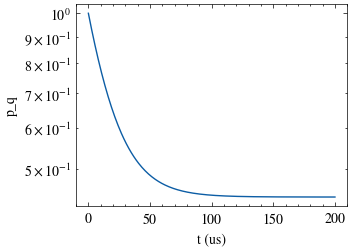

In [ ]:
#from qubit_tls_dynamics import solve_qubit_tls

out = solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0=2*np.pi*100e6,   # 5 GHz qubit, tune as needed
    Gamma_q=1/(20e-6),
    g=2*np.pi*1e3,
    T1=50e-6,#T1,                 # you already define T1 in your code
    t_span=(0, 20*T1), n_eval=300,
)

plt.plot(out['t']*1e6, out['p_q'])
#plt.xscale('log')
plt.yscale('log')
plt.xlabel('t (us)'); plt.ylabel('p_q')

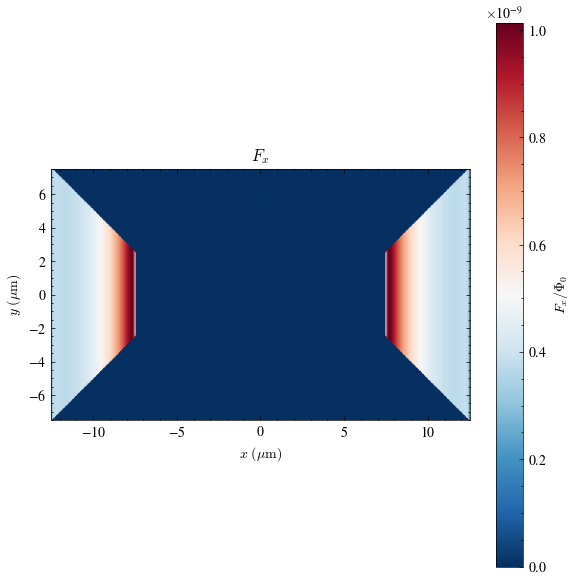

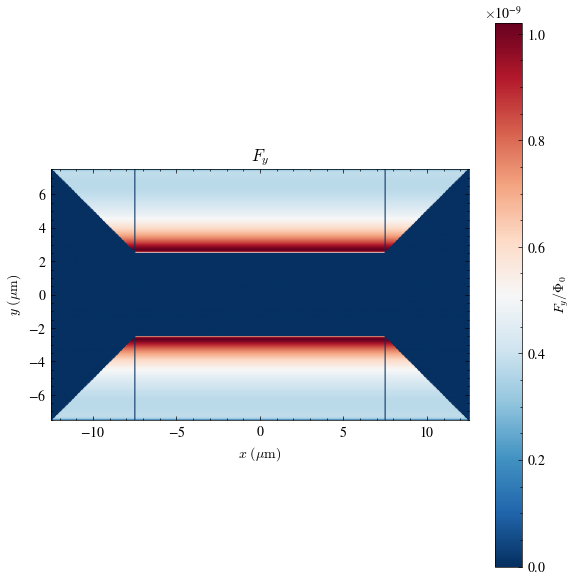

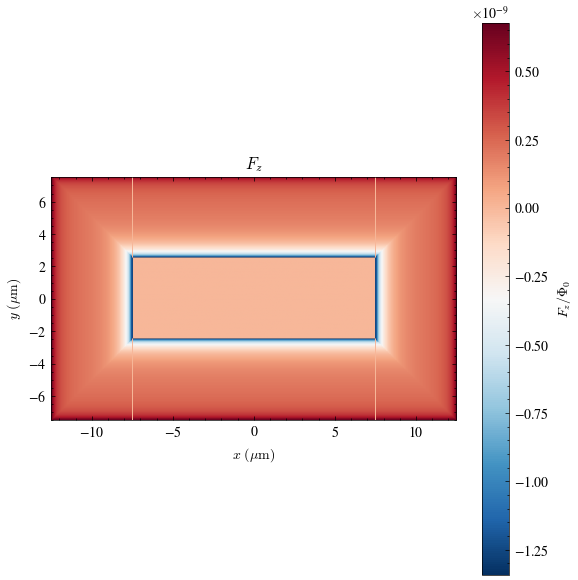

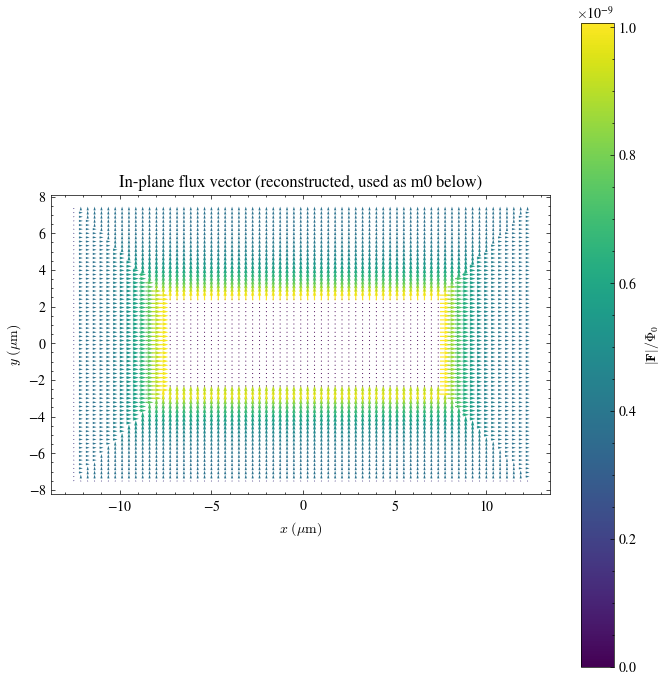

In [ ]:
# ============================================================
# PART 1: Reconstruct 2D flux field from strip profiles
# (unchanged from your original code — produces Fx, Fy, Fz
#  on grid X, Y with shape (Ny, Nx), meshgrid(x, y) 'xy' indexing)
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator

sigmam2=5e16#meters^-2
sigma=sigmam2*1e-12#micrometers^-2

W_um=5

# choose which geometry
Lx = 15          # one of the values in "files"
Ly = 5           # fixed

halfLx = Lx / 2
halfLy = Ly / 2

strip_width = W_um

# plotting domain
margin = W_um

Nx_flux, Ny_flux = 401, 401

x_flux = np.linspace(-halfLx - margin, halfLx + margin, Nx_flux)
y_flux = np.linspace(-halfLy - margin, halfLy + margin, Ny_flux)

X_flux, Y_flux = np.meshgrid(x_flux, y_flux)  # shape (Ny_flux, Nx_flux), 'xy' indexing

Fx = np.zeros_like(X_flux)
Fy = np.zeros_like(X_flux)
Fz = np.zeros_like(X_flux)

# ============================================================
# Masks defining the four strips
# (corners intentionally ignored)
# ============================================================

corner = strip_width / 2

mask_left = (
    (np.abs(X_flux + halfLx + strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_right = (
    (np.abs(X_flux - halfLx - strip_width / 2) <= strip_width / 2) &
    (np.abs(Y_flux) < halfLy)
)

mask_bottom = (
    (np.abs(Y_flux + halfLy + strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

mask_top = (
    (np.abs(Y_flux - halfLy - strip_width / 2) <= strip_width / 2) &
    (np.abs(X_flux) < halfLx)
)

# top and right must have a flip because current flows against the convention
# ============================================================
# LEFT ARM
# ============================================================

d = X_flux[mask_left] + halfLx + W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_left] = Fx_tmp
Fz[mask_left] = Fz_tmp

# ============================================================
# RIGHT ARM
# ============================================================

d = X_flux[mask_right] - halfLx - W_um / 2
Fx_tmp, Fz_tmp = flux_fun_mag_y[Lx](d)
Fx[mask_right] = np.flip(Fx_tmp)
Fz[mask_right] = np.flip(Fz_tmp)

# ============================================================
# BOTTOM ARM
# ============================================================

d = Y_flux[mask_bottom] + halfLy + W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_bottom] = Fy_tmp
Fz[mask_bottom] = Fz_tmp

# ============================================================
# TOP ARM
# ============================================================

d = Y_flux[mask_top] - halfLy - W_um / 2
Fy_tmp, Fz_tmp = flux_fun_mag_x[Lx](d)
Fy[mask_top] = np.flip(Fy_tmp)
Fz[mask_top] = np.flip(Fz_tmp)

# ============================================================
# Fill the four corners by interpolating from strip data
# ============================================================

mask_corner_bl = (X_flux < -halfLx) & (Y_flux < -halfLy)
mask_corner_br = (X_flux > halfLx) & (Y_flux < -halfLy)
mask_corner_tl = (X_flux < -halfLx) & (Y_flux > halfLy)
mask_corner_tr = (X_flux > halfLx) & (Y_flux > halfLy)

corner_masks = {
    "bottom_left": mask_corner_bl,
    "bottom_right": mask_corner_br,
    "top_left": mask_corner_tl,
    "top_right": mask_corner_tr,
}

data_mask = mask_left | mask_right | mask_top | mask_bottom
pts_known = np.column_stack([X_flux[data_mask], Y_flux[data_mask]])

for name, cmask in corner_masks.items():
    if not np.any(cmask):
        continue
    pts_query = np.column_stack([X_flux[cmask], Y_flux[cmask]])
    for field, arr in (("Fx", Fx), ("Fy", Fy), ("Fz", Fz)):
        vals_known = arr[data_mask]
        interp_vals = griddata(pts_known, vals_known, pts_query, method="nearest")
        nan_mask = np.isnan(interp_vals)
        if np.any(nan_mask):
            interp_vals[nan_mask] = griddata(
                pts_known, vals_known, pts_query[nan_mask], method="nearest"
            )
        arr[cmask] = interp_vals

# (Optional) diagnostic plots of Fx, Fy, Fz and the in-plane vector field
# — kept exactly as before, just wrapped so they don't block execution.

def _plot_field(field, name, symbol):
    plt.figure(figsize=(6, 6))
    plt.imshow(
        field, origin="lower",
        extent=[x_flux.min(), x_flux.max(), y_flux.min(), y_flux.max()],
        cmap="RdBu_r", aspect="equal",
    )
    plt.colorbar(label=rf"${symbol}/\Phi_0$")
    plt.xlabel(r"$x\ (\mu{\rm m})$")
    plt.ylabel(r"$y\ (\mu{\rm m})$")
    plt.title(rf"${symbol}$")
    plt.tight_layout()

_plot_field(Fx, "Fx", "F_x")
_plot_field(Fy, "Fy", "F_y")
_plot_field(Fz, "Fz", "F_z")

step = 6
plt.figure(figsize=(7, 7))
plt.quiver(
    X_flux[::step, ::step], Y_flux[::step, ::step],
    Fx[::step, ::step], Fy[::step, ::step],
    np.sqrt(Fx[::step, ::step] ** 2 + Fy[::step, ::step] ** 2),
    cmap="viridis", pivot="mid",
)
plt.gca().set_aspect("equal")
plt.xlabel(r"$x\ (\mu{\rm m})$")
plt.ylabel(r"$y\ (\mu{\rm m})$")
plt.title("In-plane flux vector (reconstructed, used as m0 below)")
plt.colorbar(label=r"$|\mathbf{F}|/\Phi_0$")
plt.tight_layout()


# ============================================================
# PART 2: 2D vector diffusion on a rectangular loop,
# initialized with m0 = (Fx, Fy, Fz) from Part 1
# ============================================================

from diffusion2d_complete import (
    build_rectangular_loop_mask,
    solve_diffusion_2d_loop,
    max_stable_dt, build_nonuniform_time_grid,
)

Nx, Ny = 120, 120

# domain_size is set from the flux grid itself so both fields live on
# compatible (µm) coordinates and the interpolation in Part 1 -> Part 2
# actually overlaps.
domain_size = 2 * max(halfLx + margin, halfLy + margin)

x = np.linspace(-domain_size / 2, domain_size / 2, Nx)
y = np.linspace(-domain_size / 2, domain_size / 2, Ny)
dx, dy = x[1] - x[0], y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing="ij")  # shape (Nx, Ny), 'ij' indexing

Lx_outer, Ly_outer = Lx + 2 * W_um, Ly + 2 * W_um
mask = build_rectangular_loop_mask(X, Y, Lx_outer, Ly_outer, W_um)


# ------------------------------------------------------------
# Build m0 by interpolating the reconstructed (Fx, Fy, Fz) field
# from Part 1's grid (X_flux, Y_flux) onto Part 2's grid (X, Y).
#
# Part 1 used meshgrid(x_flux, y_flux) with default 'xy' indexing,
# so Fx/Fy/Fz have shape (Ny_flux, Nx_flux) and are indexed [row=y, col=x].
# RegularGridInterpolator wants strictly increasing axes in the order
# matching the array's own indexing, so we build it as (y_flux, x_flux) -> value,
# then query at each (X, Y) point of Part 2's grid, which uses 'ij' indexing
# (shape (Nx, Ny), indexed [x, y]).
# ------------------------------------------------------------

def interp_to_target_grid(field_xy_indexed, y_source, x_source, X_target, Y_target):
    """field_xy_indexed: array of shape (len(y_source), len(x_source))."""
    interpolator = RegularGridInterpolator(
        (y_source, x_source), field_xy_indexed,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    query_pts = np.column_stack([Y_target.ravel(), X_target.ravel()])
    return interpolator(query_pts).reshape(X_target.shape)

Fx_on_target = interp_to_target_grid(Fx, y_flux, x_flux, X, Y)
Fy_on_target = interp_to_target_grid(Fy, y_flux, x_flux, X, Y)
Fz_on_target = interp_to_target_grid(Fz, y_flux, x_flux, X, Y)
Fx_on_target = Fx_on_target*phi0*1e12#um units
Fy_on_target = Fy_on_target*phi0*1e12
Fz_on_target = Fz_on_target*phi0*1e12

B0 = 350.0            # Gauss
B0 *= 1e-4            # Tesla

R_cm = .4

X_cm = X * 1e-4
Y_cm = Y * 1e-4

Bext_y = B0 * (
    (1.0 + (Y_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (Y_cm/R_cm + 0.5)**2)**(-1.5)
)

Bext_x = B0 * (
    (1.0 + (X_cm/R_cm - 0.5)**2)**(-1.5)
    -
    (1.0 + (X_cm/R_cm + 0.5)**2)**(-1.5)
)


F = np.zeros((Nx, Ny, 3))
F[..., 0] = Fx_on_target#0.
F[..., 1] = Fy_on_target
F[..., 2] = Fz_on_target

Fmag=np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)

m0 = np.zeros((Nx, Ny, 3))
m0[..., 0] = 0#1*Fx_on_target#np.sqrt(Fx_on_target**2+Fy_on_target**2+Fz_on_target**2)
m0[..., 1] = 0#1*Fy_on_target#Fy_on_target
m0[..., 2] = 0#1*Fz_on_target#Fz_on_target
#m0[..., 0]=0.1

mu_B_nAum2 = 9.2740100657e-24 * 1e21
Ip_nA=6.3
B_static = np.zeros((Nx, Ny, 3))
B_static[..., 0] = Fx_on_target*Ip_nA/mu_B_nAum2+3.6e-3#+Bext_x#0.
B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.#+0.002
B_static[..., 2] = Fz_on_target*Ip_nA/mu_B_nAum2

# B_static[..., 0] = 0.04#Bext_x#0.
# B_static[..., 1] = 0.#+0.002
# B_static[..., 2] = 0.

#B_static[..., 1] = Fy_on_target*Ip_nA/mu_B_nAum2+0.002

Bmag=np.sqrt(B_static[..., 0]**2+B_static[..., 1]**2+B_static[..., 2]**2)
np.savetxt('Bmag.csv', Bmag, delimiter=',')
T1=10e-6*1
a=1.5
TD=T1/1
D, T = a**2/TD, 20e-3

"""
Qubit + spatially-distributed spin-TLS bath population dynamics.

Solves the coupled rate equations

    dot(p_q)   = -Gamma_q  * (p_q      - p_q^th)      - sigma * Integral d^2x Gamma_qt(x) * (p_q - p_t(x))
    dot(p_t)(x)= -Gamma_1  * (p_t(x)   - p_t^th(x))    - Gamma_qt(x) * (p_t(x) - p_q)

with

    Gamma_1        = 1 / T1
    Gamma_qt(x)    = 2 g^2 Gamma_2 / (Gamma_2^2 + delta(x)^2)
    delta(x)       = 2*omega_0 - gamma * |B(x)|
    Gamma_2        = Gamma_2q + Gamma_2t = (Gamma_1 + Gamma_q) / 2
    gamma          = mu_B / hbar   (electron spin gyromagnetic ratio, rad/s/T)

p_q^th and p_t^th(x) are two-level-system Boltzmann excited-state
populations at temperature T, evaluated at the qubit frequency omega_0
and at the local spin-TLS Larmor frequency gamma*|B(x)| respectively.

UNITS
-----
- B_static must be supplied in Tesla, on a grid (X, Y) given in micrometers.
- All rates (Gamma_1, Gamma_q, Gamma_qt, Gamma_2) and omega_0, delta are in rad/s.
- gamma is computed in SI (rad/s/T) so that gamma*|B[T]| is directly in rad/s,
  matching omega_0. No unit conversion of B itself is needed.
- sigma is a 2D trap density -- it must be supplied in um^-2 so that
  sigma * (cell area in um^2) is dimensionless (a number of traps per cell).
  The spatial grid (X, Y) is used in um for exactly this reason: the
  integral sigma * Integral d^2x (...) is evaluated as sigma * sum(...) * dx * dy
  with dx, dy in um.
- Temperature enters only through hbar*omega / (kB*T), a dimensionless ratio,
  so as long as omega is in rad/s and T is in Kelvin there is no unit issue.
"""

import numpy as np
from scipy.integrate import solve_ivp

# ------------------------------------------------------------------
# Physical constants (SI)
# ------------------------------------------------------------------
HBAR = 1.054571817e-34      # J s
MU_B = 9.2740100657e-24     # J / T
KB = 1.380649e-23           # J / K
GAMMA_E = MU_B / HBAR       # rad s^-1 T^-1  (electron spin gyromagnetic ratio)


def thermal_excited_population(omega, T):
    """
    Two-level-system Boltzmann excited-state population.

    p^th = 1 / (1 + exp(hbar*omega / (kB*T)))

    omega : angular frequency (rad/s), scalar or array. Must be >= 0
            (use abs(omega) if a signed detuning-like quantity is passed).
    T     : temperature (K), scalar.

    Returns array/scalar of same shape as omega, valued in (0, 0.5].
    """
    omega = np.asarray(omega, dtype=float)
    x = HBAR * np.abs(omega) / (KB * T)
    # numerically safe for large x (avoids overflow in exp)
    return np.where(x > 700, 0.0, 1.0 / (1.0 + np.exp(np.clip(x, None, 700))))


def build_qubit_tls_rhs(
    B_static,      # (Nx, Ny, 3) array, Tesla
    X, Y,           # (Nx, Ny) grids, micrometers
    mask,           # (Nx, Ny) boolean, True where loop material exists
    sigma,          # trap density, um^-2
    omega_0,        # qubit angular frequency, rad/s
    Gamma_q,        # qubit "extra" decay/dephasing-type rate, rad/s (i.e. 1/s)
    g,              # qubit-TLS coupling, rad/s
    T1,             # spin-TLS relaxation time, s
    T=20e-3,        # temperature, K
):
    """
    Build and return:
      rhs(t, state) -> dstate/dt     for use with scipy.integrate.solve_ivp
      pack(p_q, p_t) -> state
      unpack(state)  -> (p_q, p_t)
      info dict with precomputed fields (Gamma_qt map, thermal pops, etc.)

    state layout: state[0] = p_q ; state[1:] = p_t.ravel() (only over mask
    points -- points outside the mask are excluded from the integral and
    from the ODE system, since there is no TLS bath material there).
    """
    dx = X[1, 0] - X[0, 0]
    dy = Y[0, 1] - Y[0, 0]
    cell_area = dx * dy  # um^2
    #np.savetxt('B.csv', Bmag, delimiter=',')

    Bmag = np.sqrt(np.sum(B_static ** 2, axis=-1))  # Tesla, shape (Nx, Ny)
    np.savetxt('Bmag.csv', Bmag, delimiter=',')

    # Only evolve p_t where there is actually loop material (mask == True).
    idx = np.where(mask.ravel())[0]
    n_t = idx.size

    Bmag_flat = Bmag.ravel()[idx]

    Gamma_1 = 1.0 / T1
    Gamma_2 = (Gamma_1 + Gamma_q) / 2.0

    delta = 2.0 * omega_0 - GAMMA_E * Bmag_flat            # rad/s, shape (n_t,)
    Gamma_qt = 2.0 * g ** 2 * Gamma_2 / (Gamma_2 ** 2 + delta ** 2)  # rad/s (1/s)

    p_q_th = thermal_excited_population(omega_0, T)                 # scalar
    p_t_th = thermal_excited_population(GAMMA_E * Bmag_flat, T)      # shape (n_t,)

    def pack(p_q, p_t_full):
        state = np.empty(1 + n_t)
        state[0] = p_q
        state[1:] = p_t_full.ravel()[idx]
        return state

    def unpack(state, fill_value=np.nan):
        p_q = state[0]
        p_t_full = np.full(mask.shape, fill_value)
        p_t_full.ravel()[idx] = state[1:]
        return p_q, p_t_full

    def rhs(t, state):
        p_q = state[0]
        p_t = state[1:]  # shape (n_t,)

        dpq_dt = (
            -Gamma_q * (p_q - p_q_th)
            - sigma * np.sum(Gamma_qt * (p_q - p_t)) * cell_area
        )

        dpt_dt = -Gamma_1 * (p_t - p_t_th) - Gamma_qt * (p_t - p_q)

        dstate = np.empty_like(state)
        dstate[0] = dpq_dt
        dstate[1:] = dpt_dt
        return dstate

    info = dict(
        Gamma_1=Gamma_1,
        Gamma_2=Gamma_2,
        Gamma_qt=Gamma_qt,
        delta=delta,
        p_q_th=p_q_th,
        p_t_th=p_t_th,
        Bmag=Bmag,
        idx=idx,
        n_t=n_t,
        cell_area=cell_area,
    )
    return rhs, pack, unpack, info


def solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0, Gamma_q, g, T1,
    T=20e-3,
    p_q0=1, p_t0=None,
    t_span=(0.0, 1e-3), n_eval=200,
    method="LSODA",
    rtol=1e-8, atol=1e-12,
):
    """
    Convenience wrapper: builds the RHS and integrates it with solve_ivp.

    If p_q0 / p_t0 are None, both p_q and p_t are initialized at their
    respective thermal populations (a natural default: bath starts in
    thermal equilibrium, no qubit excitation).

    Returns a dict with:
      t          : (n_eval,) time array (s)
      p_q        : (n_eval,) qubit excited-state population vs time
      p_t        : (n_eval, Nx, Ny) TLS population field vs time (NaN outside mask)
      info       : dict of precomputed rates (Gamma_qt map, thermal pops, ...)
      sol        : raw solve_ivp result object
    """
    rhs, pack, unpack, info = build_qubit_tls_rhs(
        B_static, X, Y, mask, sigma, omega_0, Gamma_q, g, T1, T=T
    )

    if p_q0 is None:
        p_q0 = info["p_q_th"]
    if p_t0 is None:
        p_t0_full = np.full(mask.shape, np.nan)
        p_t0_full.ravel()[info["idx"]] = info["p_t_th"]
    else:
        p_t0_full = p_t0

    state0 = pack(p_q0, p_t0_full)

    t_eval = np.linspace(t_span[0], t_span[1], n_eval)
    sol = solve_ivp(
        rhs, t_span, state0, t_eval=t_eval,
        method=method, rtol=rtol, atol=atol,
    )

    p_q_t = sol.y[0, :]
    p_t_t = np.full((sol.y.shape[1], *mask.shape), np.nan)
    for k in range(sol.y.shape[1]):
        _, p_t_full = unpack(sol.y[:, k])
        p_t_t[k] = p_t_full

    return dict(t=sol.t, p_q=p_q_t, p_t=p_t_t, info=info, sol=sol)

omega_TLS / 2pi = 50.386 MHz
g / 2pi = 0.010 MHz
On-resonance Gamma_qt = 2.500e+05 rad/s  vs  Gamma_q = 5.000e+04 rad/s


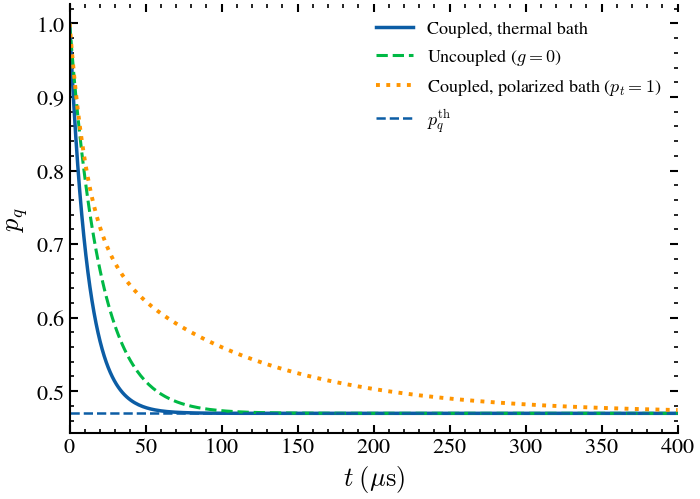

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Resonance calculation
# ------------------------------------------------------------------
B0 = 3.6e-3
omega_TLS = GAMMA_E * B0

print(f"omega_TLS / 2pi = {omega_TLS/(2*np.pi)/1e6:.3f} MHz")

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
omega_0 = omega_TLS
Gamma_q = 1 / (20e-6)
T1      = 100e-6
T_bath  = T

Gamma_1 = 1 / T1
Gamma_2 = (Gamma_1 + Gamma_q) / 2

g_target_ratio = 5.0
g = np.sqrt(g_target_ratio * Gamma_q * Gamma_2 / 2)

print(f"g / 2pi = {g/(2*np.pi)/1e6:.3f} MHz")
print(
    f"On-resonance Gamma_qt = {2*g**2/Gamma_2:.3e} rad/s"
    f"  vs  Gamma_q = {Gamma_q:.3e} rad/s"
)

t_span = (0, 20 / Gamma_q)
n_eval = 300
p_q0 = 1.0

# ------------------------------------------------------------------
# Coupled dynamics -- thermal bath
# ------------------------------------------------------------------
out_coupled = solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0=omega_0,
    Gamma_q=Gamma_q,
    g=g,
    T1=T1,
    T=T_bath,
    p_q0=p_q0,
    t_span=t_span,
    n_eval=n_eval,
)

# ------------------------------------------------------------------
# Uncoupled comparison
# ------------------------------------------------------------------
t_eval = out_coupled["t"]

p_q_th = thermal_excited_population(omega_0, T_bath)

p_q_uncoupled = (
    p_q_th
    + (p_q0 - p_q_th) * np.exp(-Gamma_q * t_eval)
)

# ------------------------------------------------------------------
# Coupled dynamics -- fully polarized bath
# ------------------------------------------------------------------
p_t0_polarized = np.ones(mask.shape)

out_polarized = solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0=omega_0,
    Gamma_q=Gamma_q,
    g=g,
    T1=T1,
    T=T_bath,
    p_q0=p_q0,
    p_t0=p_t0_polarized,
    t_span=t_span,
    n_eval=n_eval,
)

# ==================================================================
# Plot -- PRB/PRL style
# ==================================================================

fig, ax = plt.subplots(figsize=(7.2, 5.2))

# Coupled, thermal bath
ax.plot(
    out_coupled["t"] * 1e6,
    out_coupled["p_q"],
    lw=2.5,
    label="Coupled, thermal bath",
)

# Uncoupled
ax.plot(
    t_eval * 1e6,
    p_q_uncoupled,
    "--",
    lw=2.2,
    label=r"Uncoupled ($g=0$)",
)

# Coupled, polarized bath
ax.plot(
    out_polarized["t"] * 1e6,
    out_polarized["p_q"],
    ":",
    lw=2.8,
    label=r"Coupled, polarized bath ($p_t=1$)",
)

# Thermal equilibrium
ax.axhline(
    p_q_th,
    lw=1.8,
    ls="--",
    label=r"$p_q^{\mathrm{th}}$",
)

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------
ax.set_xlabel(r"$t\;(\mu\mathrm{s})$", fontsize=19)
ax.set_ylabel(r"$p_q$", fontsize=19)

# ------------------------------------------------------------------
# Tick formatting
# ------------------------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
    width=1.5,
    length=6,
)

ax.tick_params(
    axis="both",
    which="minor",
    width=1.2,
    length=3,
)

# Minor ticks
ax.minorticks_on()

# ------------------------------------------------------------------
# Spines
# ------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
ax.legend(
    fontsize=13,
    frameon=False,
    loc="best",
)

# ------------------------------------------------------------------
# Limits
# ------------------------------------------------------------------
ax.set_xlim(
    0,
    t_span[1] * 1e6
)

# ------------------------------------------------------------------
# Layout
# ------------------------------------------------------------------
fig.tight_layout()

fig.savefig(
    "qubit_tls_more.pdf",
    bbox_inches="tight",
)

plt.show()

In [ ]:
"""
Qubit + spatially-distributed spin-TLS bath population dynamics.

Solves the coupled rate equations

    dot(p_q)   = -Gamma_q  * (p_q      - p_q^th)      - sigma * Integral d^2x Gamma_qt(x) * (p_q - p_t(x))
    dot(p_t)(x)= -Gamma_1  * (p_t(x)   - p_t^th(x))    - Gamma_qt(x) * (p_t(x) - p_q)

with

    Gamma_1        = 1 / T1
    Gamma_qt(x)    = 2 g^2 Gamma_2 / (Gamma_2^2 + delta(x)^2)
    delta(x)       = 2*omega_0 - gamma * |B(x)|
    Gamma_2        = Gamma_2q + Gamma_2t = (Gamma_1 + Gamma_q) / 2
    gamma          = mu_B / hbar   (electron spin gyromagnetic ratio, rad/s/T)

p_q^th and p_t^th(x) are two-level-system Boltzmann excited-state
populations at temperature T, evaluated at the qubit frequency omega_0
and at the local spin-TLS Larmor frequency gamma*|B(x)| respectively.

UNITS
-----
- B_static must be supplied in Tesla, on a grid (X, Y) given in micrometers.
- All rates (Gamma_1, Gamma_q, Gamma_qt, Gamma_2) and omega_0, delta are in rad/s.
- gamma is computed in SI (rad/s/T) so that gamma*|B[T]| is directly in rad/s,
  matching omega_0. No unit conversion of B itself is needed.
- sigma is a 2D trap density -- it must be supplied in um^-2 so that
  sigma * (cell area in um^2) is dimensionless (a number of traps per cell).
  The spatial grid (X, Y) is used in um for exactly this reason: the
  integral sigma * Integral d^2x (...) is evaluated as sigma * sum(...) * dx * dy
  with dx, dy in um.
- Temperature enters only through hbar*omega / (kB*T), a dimensionless ratio,
  so as long as omega is in rad/s and T is in Kelvin there is no unit issue.
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix

# ------------------------------------------------------------------
# Physical constants (SI)
# ------------------------------------------------------------------
HBAR = 1.054571817e-34      # J s
MU_B = 9.2740100657e-24     # J / T
KB = 1.380649e-23           # J / K
GAMMA_E = MU_B / HBAR       # rad s^-1 T^-1  (electron spin gyromagnetic ratio)


def thermal_excited_population(omega, T):
    """
    Two-level-system Boltzmann excited-state population.

    p^th = 1 / (1 + exp(hbar*omega / (kB*T)))

    omega : angular frequency (rad/s), scalar or array. Must be >= 0
            (use abs(omega) if a signed detuning-like quantity is passed).
    T     : temperature (K), scalar.

    Returns array/scalar of same shape as omega, valued in (0, 0.5].
    """
    omega = np.asarray(omega, dtype=float)
    x = HBAR * np.abs(omega) / (KB * T)
    # numerically safe for large x (avoids overflow in exp)
    return np.where(x > 700, 0.0, 1.0 / (1.0 + np.exp(np.clip(x, None, 700))))


def build_qubit_tls_rhs(
    B_static,      # (Nx, Ny, 3) array, Tesla
    X, Y,           # (Nx, Ny) grids, micrometers
    mask,           # (Nx, Ny) boolean, True where loop material exists
    sigma,          # trap density, um^-2
    omega_0,        # qubit angular frequency, rad/s
    Gamma_q,        # qubit "extra" decay/dephasing-type rate, rad/s (i.e. 1/s)
    g,              # qubit-TLS coupling, rad/s
    T1,             # spin-TLS relaxation time, s
    T=20e-3,        # temperature, K
):
    """
    Build and return:
      rhs(t, state) -> dstate/dt     for use with scipy.integrate.solve_ivp
      pack(p_q, p_t) -> state
      unpack(state)  -> (p_q, p_t)
      info dict with precomputed fields (Gamma_qt map, thermal pops, etc.)

    state layout: state[0] = p_q ; state[1:] = p_t.ravel() (only over mask
    points -- points outside the mask are excluded from the integral and
    from the ODE system, since there is no TLS bath material there).
    """
    dx = X[1, 0] - X[0, 0]
    dy = Y[0, 1] - Y[0, 0]
    cell_area = dx * dy  # um^2

    Bmag = np.sqrt(np.sum(B_static ** 2, axis=-1))  # Tesla, shape (Nx, Ny)

    # Only evolve p_t where there is actually loop material (mask == True).
    idx = np.where(mask.ravel())[0]
    n_t = idx.size

    Bmag_flat = Bmag.ravel()[idx]

    Gamma_1 = 1.0 / T1
    Gamma_2 = (Gamma_1 + Gamma_q) / 2.0

    delta = 2.0 * omega_0 - GAMMA_E * Bmag_flat            # rad/s, shape (n_t,)
    Gamma_qt = 2.0 * g ** 2 * Gamma_2 / (Gamma_2 ** 2 + delta ** 2)  # rad/s (1/s)

    p_q_th = thermal_excited_population(omega_0, T)                 # scalar
    p_t_th = thermal_excited_population(GAMMA_E * Bmag_flat, T)      # shape (n_t,)

    def pack(p_q, p_t_full):
        state = np.empty(1 + n_t)
        state[0] = p_q
        state[1:] = p_t_full.ravel()[idx]
        return state

    def unpack(state, fill_value=np.nan):
        p_q = state[0]
        p_t_full = np.full(mask.shape, fill_value)
        p_t_full.ravel()[idx] = state[1:]
        return p_q, p_t_full

    def rhs(t, state):
        p_q = state[0]
        p_t = state[1:]  # shape (n_t,)

        dpq_dt = (
            -Gamma_q * (p_q - p_q_th)
            - sigma * np.sum(Gamma_qt * (p_q - p_t)) * cell_area
        )

        dpt_dt = -Gamma_1 * (p_t - p_t_th) - Gamma_qt * (p_t - p_q)

        dstate = np.empty_like(state)
        dstate[0] = dpq_dt
        dstate[1:] = dpt_dt
        return dstate

    # ------------------------------------------------------------
    # The system is LINEAR in the state: dot(p) = A @ p + b, with A
    # constant (Gamma_qt, Gamma_1, Gamma_q, sigma, cell_area don't depend
    # on p). Supplying the exact, constant Jacobian A lets stiff solvers
    # (BDF/LSODA) take large implicit steps instead of crawling -- this
    # matters a lot here because Gamma_1 = 1/T1 (~1e5 rad/s) and Gamma_qt
    # (~1-100 rad/s for nT-scale fields) differ by orders of magnitude,
    # i.e. the system is numerically stiff.
    # ------------------------------------------------------------
    sum_sigma_Gqt_area = sigma * cell_area  # scalar prefactor reused below
    n_state = 1 + n_t

    # Build the constant Jacobian ONCE as a sparse matrix (dense would be
    # (n_t+1)^2 floats -- tens/hundreds of MB and slow to factor for
    # n_t ~ 1e4). Structure: row 0 (dpq_dt) is dense-ish (couples to every
    # p_t), rows 1: (dpt_dt) are diagonal (each p_t only couples to p_q
    # and itself) plus a first column entry.
    row0 = np.concatenate(([0], np.zeros(n_t, dtype=int)))
    col0 = np.concatenate(([0], np.arange(1, n_state)))
    data0 = np.concatenate((
        [-Gamma_q - sum_sigma_Gqt_area * np.sum(Gamma_qt)],
        sum_sigma_Gqt_area * Gamma_qt,
    ))
    rows_diag = np.arange(1, n_state)
    cols_diag = np.arange(1, n_state)
    data_diag = -Gamma_1 - Gamma_qt
    rows_firstcol = np.arange(1, n_state)
    cols_firstcol = np.zeros(n_t, dtype=int)
    data_firstcol = Gamma_qt

    rows = np.concatenate((row0, rows_diag, rows_firstcol))
    cols = np.concatenate((col0, cols_diag, cols_firstcol))
    data = np.concatenate((data0, data_diag, data_firstcol))
    J_const = csr_matrix((data, (rows, cols)), shape=(n_state, n_state))

    def jac(t, state):
        return J_const

    info = dict(
        Gamma_1=Gamma_1,
        Gamma_2=Gamma_2,
        Gamma_qt=Gamma_qt,
        delta=delta,
        p_q_th=p_q_th,
        p_t_th=p_t_th,
        Bmag=Bmag,
        idx=idx,
        n_t=n_t,
        cell_area=cell_area,
    )
    return rhs, jac, pack, unpack, info


def suggest_g_scale(sigma, mask, X, Y, Gamma_1, Gamma_q, target_collective_rate=None):
    """
    Given the TLS areal density sigma (um^-2) and the mask area, suggest a
    per-TLS coupling g (rad/s) such that the COLLECTIVE resonant coupling
    rate sigma * area * Gamma_qt_peak is comparable to (not vastly larger
    than) the qubit's own bare decay channels (Gamma_1, Gamma_q).

    Why this matters: Gamma_qt(x) for a single TLS can look modest
    (order Gamma_2, i.e. order 1-100 rad/s for these nT-scale fields), but
    the qubit equation sums this over EVERY grid cell weighted by sigma.
    With sigma ~ 5e17 m^-2 (a typical literature TLS areal density) and a
    loop of a few hundred um^2, that is ~1e8 effective TLS contributing --
    even a tiny per-TLS g swamps the qubit unless g is scaled down to
    compensate. This function inverts that relation to suggest a sane g.

    If target_collective_rate is None, defaults to Gamma_1 (i.e. the TLS
    bath contributes "about as much" relaxation as the TLS's own intrinsic
    T1 -- a reasonable middle ground that still lets resonance structure
    show up in the dynamics instead of either doing nothing or swamping
    the qubit instantly).
    """
    dx = X[1, 0] - X[0, 0]
    dy = Y[0, 1] - Y[0, 0]
    area = mask.sum() * dx * dy  # um^2
    Gamma_2 = (Gamma_1 + Gamma_q) / 2.0
    if target_collective_rate is None:
        target_collective_rate = Gamma_1
    # Gamma_qt_peak (at exact resonance, delta=0) = 2*g^2/Gamma_2
    # want: sigma * area * Gamma_qt_peak == target_collective_rate
    Gamma_qt_peak_needed = target_collective_rate / (sigma * area)
    g = np.sqrt(Gamma_qt_peak_needed * Gamma_2 / 2.0)
    return g


def suggest_omega_0_range(Bmag, mask=None, n=25):
    """
    Given the actual |B(x)| map (Tesla) on the grid, return a physically
    sensible array of omega_0 values (rad/s) to sweep, centered on the
    resonance band 2*omega_0 = gamma*|B(x)| implied by the data itself.

    This is the key diagnostic for "what should omega_0 be": rather than
    picking a qubit frequency in a vacuum (e.g. a GHz transmon value that
    would leave every spin TLS wildly off-resonance for a nT-scale field),
    we read off the range of Larmor frequencies gamma*|B(x)| actually
    present in B_static and sweep omega_0 through half that range, so the
    resonance condition delta(x) = 0 is achieved somewhere on the grid for
    at least some values of omega_0 in the sweep -- this is what produces
    a Gamma_qt(x) map with real spatial structure (resonant hot-spots
    against an off-resonant background) instead of either uniformly-huge
    or uniformly-negligible coupling everywhere.
    """
    if mask is not None:
        vals = Bmag[mask]
    else:
        vals = Bmag[Bmag > 0]
    f_lo, f_hi = GAMMA_E * vals.min() / (4 * np.pi), GAMMA_E * vals.max() / (4 * np.pi)
    # pad by 50% on each side so the sweep also covers the fully-off-resonant regime
    span = f_hi - f_lo
    f_lo_padded = max(f_lo - 0.5 * span, 0.0)
    f_hi_padded = f_hi + 0.5 * span
    f0_array = np.linspace(f_lo_padded, f_hi_padded, n)
    return 2 * np.pi * f0_array  # rad/s


def solve_qubit_tls(
    B_static, X, Y, mask, sigma,
    omega_0, Gamma_q, g, T1,
    T=20e-3,
    p_q0=None, p_t0=None,
    t_span=(0.0, 1e-3), n_eval=200,
    method="BDF",
    rtol=1e-6, atol=1e-10,
):
    """
    Convenience wrapper: builds the RHS and integrates it with solve_ivp.

    If p_q0 / p_t0 are None, both p_q and p_t are initialized at their
    respective thermal populations (a natural default: bath starts in
    thermal equilibrium, no qubit excitation).

    Returns a dict with:
      t          : (n_eval,) time array (s)
      p_q        : (n_eval,) qubit excited-state population vs time
      p_t        : (n_eval, Nx, Ny) TLS population field vs time (NaN outside mask)
      info       : dict of precomputed rates (Gamma_qt map, thermal pops, ...)
      sol        : raw solve_ivp result object
    """
    rhs, jac, pack, unpack, info = build_qubit_tls_rhs(
        B_static, X, Y, mask, sigma, omega_0, Gamma_q, g, T1, T=T
    )

    if p_q0 is None:
        p_q0 = info["p_q_th"]
    if p_t0 is None:
        p_t0_full = np.full(mask.shape, np.nan)
        p_t0_full.ravel()[info["idx"]] = info["p_t_th"]
    else:
        p_t0_full = p_t0

    state0 = pack(p_q0, p_t0_full)

    t_eval = np.linspace(t_span[0], t_span[1], n_eval)
    sol = solve_ivp(
        rhs, t_span, state0, t_eval=t_eval,
        method=method, jac=jac, rtol=rtol, atol=atol,
    )

    p_q_t = sol.y[0, :]
    p_t_t = np.full((sol.y.shape[1], *mask.shape), np.nan)
    for k in range(sol.y.shape[1]):
        _, p_t_full = unpack(sol.y[:, k])
        p_t_t[k] = p_t_full

    return dict(t=sol.t, p_q=p_q_t, p_t=p_t_t, info=info, sol=sol)


def sweep_omega_0(
    B_static, X, Y, mask, sigma,
    omega_0_array,       # rad/s, e.g. from suggest_omega_0_range(...)
    Gamma_q, g, T1,
    T=20e-3,
    t_span=None, n_eval=150,
):
    """
    Sweep omega_0 across omega_0_array and, for each value, integrate the
    coupled p_q/p_t system to its final time. Returns arrays useful for
    plotting the qubit "spectroscopy" signature of the resonant TLS bath:

      p_q_final[i]     : p_q at t_span[1] for omega_0_array[i]
      p_q_th_array[i]   : the trivial (bath-decoupled) qubit thermal population
                          at that omega_0, for comparison
      max_Gamma_qt[i]   : peak Gamma_qt(x) over the grid at that omega_0
                          (rad/s) -- large where some x is near resonance
      n_eval, t          : as returned by the last individual solve (shared time grid)

    The qubit population deviating from p_q_th (its bare thermal value) as
    omega_0 sweeps through the band where max_Gamma_qt spikes is the
    diagnostic that the coupling to spatially-resolved resonant TLS is
    doing something physical, i.e. is what you'd plot to "reveal the
    physics" of this model.
    """
    if t_span is None:
        # default integration horizon: several T1's is enough for p_q to
        # visibly respond to (or fail to respond to) the bath
        t_span = (0.0, 10 * T1)

    p_q_final = np.empty_like(omega_0_array)
    p_q_th_array = np.empty_like(omega_0_array)
    max_Gamma_qt = np.empty_like(omega_0_array)
    t_shared = None

    for i, omega_0 in enumerate(omega_0_array):
        out = solve_qubit_tls(
            B_static, X, Y, mask, sigma, omega_0, Gamma_q, g, T1,
            T=T, t_span=t_span, n_eval=n_eval,
        )
        p_q_final[i] = out["p_q"][-1]
        p_q_th_array[i] = out["info"]["p_q_th"]
        max_Gamma_qt[i] = out["info"]["Gamma_qt"].max()
        t_shared = out["t"]

    return dict(
        omega_0=omega_0_array,
        p_q_final=p_q_final,
        p_q_th=p_q_th_array,
        max_Gamma_qt=max_Gamma_qt,
        t=t_shared,
    )

# Solomon equations with relaxation rates distribution $P(\Gamma)$

In [ ]:
# ============================================================
# PART 2: 2D vector diffusion + qubit/TLS population dynamics
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp


# ============================================================
# Physical constants
# ============================================================

HBAR = 1.054571817e-34      # J s
MU_B = 9.2740100657e-24     # J / T
KB = 1.380649e-23           # J / K

GAMMA_E = MU_B / HBAR       # rad s^-1 T^-1


# ============================================================
# Thermal population
# ============================================================

def thermal_excited_population(omega, T):
    """
    Two-level-system Boltzmann excited-state population:

        p_th = 1 / (1 + exp(hbar*|omega|/(kB*T)))

    omega : angular frequency [rad/s]
    T     : temperature [K]
    """

    omega = np.asarray(omega, dtype=float)

    x = HBAR * np.abs(omega) / (KB * T)

    return np.where(
        x > 700,
        0.0,
        1.0 / (1.0 + np.exp(np.clip(x, None, 700)))
    )


# ============================================================
# Build RHS
# ============================================================

def build_qubit_tls_rhs(
    B_static,          # (Nx, Ny, 3), Tesla
    X, Y,              # (Nx, Ny), micrometers
    mask,              # (Nx, Ny), True inside loop
    sigma,             # TLS density [um^-2]
    omega_0,           # qubit angular frequency [rad/s]
    Gamma_q,           # qubit rate [1/s]
    g,                 # qubit-TLS coupling [rad/s]

    Gamma_min,         # minimum TLS relaxation rate [1/s]
    Gamma_max,         # maximum TLS relaxation rate [1/s]

    T=20e-3,           # temperature [K]
    seed=None,         # random seed
):
    """
    Build the RHS for the coupled qubit-TLS population equations.

    Each TLS is assigned an independent relaxation rate Gamma_1
    drawn from the logarithmic distribution

        p(Gamma_1)
        = 1 / [Gamma_1 * ln(Gamma_max/Gamma_min)]

    for

        Gamma_min <= Gamma_1 <= Gamma_max.

    Therefore the distribution is uniform in log(Gamma_1).

    The equations are

        dp_q/dt =
            -Gamma_q (p_q - p_q_th)
            - sigma * integral d^2x
              Gamma_qt(x) [p_q - p_t(x)]

        dp_t/dt =
            -Gamma_1(x) [p_t - p_t_th(x)]
            - Gamma_qt(x) [p_t - p_q]

    with

        Gamma_qt =
            2 g^2 Gamma_2 /
            (Gamma_2^2 + delta^2)

        delta = 2 omega_0 - gamma_e |B|

        Gamma_2 = (Gamma_1 + Gamma_q)/2.
    """

    # --------------------------------------------------------
    # Grid spacing
    # --------------------------------------------------------

    dx = X[1, 0] - X[0, 0]
    dy = Y[0, 1] - Y[0, 0]

    cell_area = dx * dy       # um^2


    # --------------------------------------------------------
    # Magnetic-field magnitude
    # --------------------------------------------------------

    Bmag = np.sqrt(
        np.sum(B_static**2, axis=-1)
    )                         # Tesla


    # --------------------------------------------------------
    # Only keep TLSs inside the superconducting loop
    # --------------------------------------------------------

    idx = np.where(mask.ravel())[0]
    n_t = idx.size

    Bmag_flat = Bmag.ravel()[idx]


    # ========================================================
    # RANDOM TLS RELAXATION RATES
    # ========================================================
    #
    # We want
    #
    #       p(Gamma_1) ~ 1/Gamma_1
    #
    # between Gamma_min and Gamma_max.
    #
    # Properly normalized:
    #
    #       p(Gamma_1)
    #       =
    #       1 / [Gamma_1 ln(Gamma_max/Gamma_min)]
    #
    # Sampling is therefore equivalent to:
    #
    #       log(Gamma_1)
    #       ~ Uniform(log(Gamma_min), log(Gamma_max))
    #
    # ========================================================

    if Gamma_min <= 0:
        raise ValueError("Gamma_min must be > 0.")

    if Gamma_max <= Gamma_min:
        raise ValueError(
            "Gamma_max must be greater than Gamma_min."
        )


    # Random-number generator
    rng = np.random.default_rng(seed)


    # Draw one Gamma_1 for every TLS
    Gamma_1 = np.exp(
        rng.uniform(
            np.log(Gamma_min),
            np.log(Gamma_max),
            size=n_t
        )
    )


    # --------------------------------------------------------
    # Corresponding T1 of every TLS
    # --------------------------------------------------------

    T1 = 1.0 / Gamma_1


    # --------------------------------------------------------
    # TLS transverse relaxation rate
    # --------------------------------------------------------
    #
    # IMPORTANT:
    # Gamma_1 is now an array, not a scalar.
    #
    # Therefore every TLS has its own Gamma_2.
    # --------------------------------------------------------

    Gamma_2 = (
        Gamma_1 + Gamma_q
    ) / 2.0


    # ========================================================
    # TLS detuning
    # ========================================================

    delta = (
        omega_0
        - GAMMA_E * Bmag_flat
    )


    # ========================================================
    # Qubit-TLS coupling rate
    # ========================================================

    Gamma_qt = (
        2.0 * g**2 * Gamma_2
        /
        (
            Gamma_2**2
            + delta**2
        )
    )


    # ========================================================
    # Thermal populations
    # ========================================================

    # Qubit thermal population
    p_q_th = thermal_excited_population(
        omega_0,
        T
    )


    # Individual TLS thermal populations
    p_t_th = thermal_excited_population(
        GAMMA_E * Bmag_flat,
        T
    )


    # ========================================================
    # State packing/unpacking
    # ========================================================

    def pack(p_q, p_t_full):

        state = np.empty(
            1 + n_t
        )

        state[0] = p_q

        state[1:] = (
            p_t_full.ravel()[idx]
        )

        return state


    def unpack(state, fill_value=np.nan):

        p_q = state[0]

        p_t_full = np.full(
            mask.shape,
            fill_value
        )

        p_t_full.ravel()[idx] = state[1:]

        return p_q, p_t_full


    # ========================================================
    # ODE RHS
    # ========================================================

    def rhs(t, state):

        # ----------------------------------------------------
        # Extract populations
        # ----------------------------------------------------

        p_q = state[0]

        p_t = state[1:]


        # ----------------------------------------------------
        # Qubit equation
        # ----------------------------------------------------

        dpq_dt = (

            -Gamma_q
            * (p_q - p_q_th)

            - sigma
            * np.sum(
                Gamma_qt
                * (p_q - p_t)
            )
            * cell_area
        )


        # ----------------------------------------------------
        # TLS equations
        #
        # Gamma_1 is an array, so each TLS has its own
        # relaxation rate.
        # ----------------------------------------------------

        dpt_dt = (

            -Gamma_1
            * (p_t - p_t_th)

            - Gamma_qt
            * (p_t - p_q)
        )


        # ----------------------------------------------------
        # Construct derivative vector
        # ----------------------------------------------------

        dstate = np.empty_like(state)

        dstate[0] = dpq_dt

        dstate[1:] = dpt_dt


        return dstate


    # ========================================================
    # Information returned with the solution
    # ========================================================

    info = dict(

        # Random TLS relaxation rates
        Gamma_1=Gamma_1,

        # Corresponding T1 values
        T1=T1,

        # Transverse rates
        Gamma_2=Gamma_2,

        # Qubit-TLS coupling rates
        Gamma_qt=Gamma_qt,

        # Detunings
        delta=delta,

        # Thermal populations
        p_q_th=p_q_th,
        p_t_th=p_t_th,

        # Magnetic field
        Bmag=Bmag,

        # Grid information
        idx=idx,
        n_t=n_t,
        cell_area=cell_area,

        # Distribution limits
        Gamma_min=Gamma_min,
        Gamma_max=Gamma_max,

        # Random seed
        seed=seed,
    )


    return rhs, pack, unpack, info


# ============================================================
# SOLVER
# ============================================================

def solve_qubit_tls(
    B_static,
    X,
    Y,
    mask,
    sigma,

    omega_0,
    Gamma_q,
    g,

    Gamma_min,
    Gamma_max,

    T=20e-3,

    p_q0=1,
    p_t0=None,

    t_span=(0.0, 1e-3),
    n_eval=200,

    method="LSODA",

    rtol=1e-8,
    atol=1e-12,

    seed=None,
):
    """
    Solve the coupled qubit-TLS population dynamics.

    Each TLS receives its own Gamma_1 drawn from

        p(Gamma_1)
        =
        1 / [
            Gamma_1 *
            ln(Gamma_max/Gamma_min)
        ]

    between Gamma_min and Gamma_max.

    Parameters
    ----------
    Gamma_min : float
        Minimum TLS relaxation rate [1/s].

    Gamma_max : float
        Maximum TLS relaxation rate [1/s].

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    result : dict
        Contains

            t
            p_q
            p_t
            info
            sol
    """


    # ========================================================
    # Build RHS
    # ========================================================

    rhs, pack, unpack, info = build_qubit_tls_rhs(

        B_static,
        X,
        Y,
        mask,
        sigma,

        omega_0,
        Gamma_q,
        g,

        Gamma_min,
        Gamma_max,

        T=T,
        seed=seed,
    )


    # ========================================================
    # Initial qubit population
    # ========================================================

    if p_q0 is None:

        p_q0 = info["p_q_th"]


    # ========================================================
    # Initial TLS populations
    # ========================================================

    if p_t0 is None:

        p_t0_full = np.full(
            mask.shape,
            np.nan
        )

        p_t0_full.ravel()[
            info["idx"]
        ] = info["p_t_th"]

    else:

        p_t0_full = p_t0


    # ========================================================
    # Initial state
    # ========================================================

    state0 = pack(
        p_q0,
        p_t0_full
    )


    # ========================================================
    # Evaluation times
    # ========================================================

    t_eval = np.linspace(
        t_span[0],
        t_span[1],
        n_eval
    )


    # ========================================================
    # Solve
    # ========================================================

    sol = solve_ivp(

        rhs,

        t_span,

        state0,

        t_eval=t_eval,

        method=method,

        rtol=rtol,
        atol=atol,
    )


    # ========================================================
    # Qubit population
    # ========================================================

    p_q_t = sol.y[0, :]


    # ========================================================
    # TLS populations
    # ========================================================

    p_t_t = np.full(
        (
            sol.y.shape[1],
            *mask.shape
        ),
        np.nan
    )


    for k in range(sol.y.shape[1]):

        _, p_t_full = unpack(
            sol.y[:, k]
        )

        p_t_t[k] = p_t_full


    # ========================================================
    # Return
    # ========================================================

    return dict(

        t=sol.t,

        p_q=p_q_t,

        p_t=p_t_t,

        info=info,

        sol=sol,
    )

omega_TLS / 2pi = 50.386 MHz
g / 2pi = 0.010 MHz
On-resonance Gamma_qt = 2.500e+05 rad/s  vs  Gamma_q = 5.000e+04 rad/s


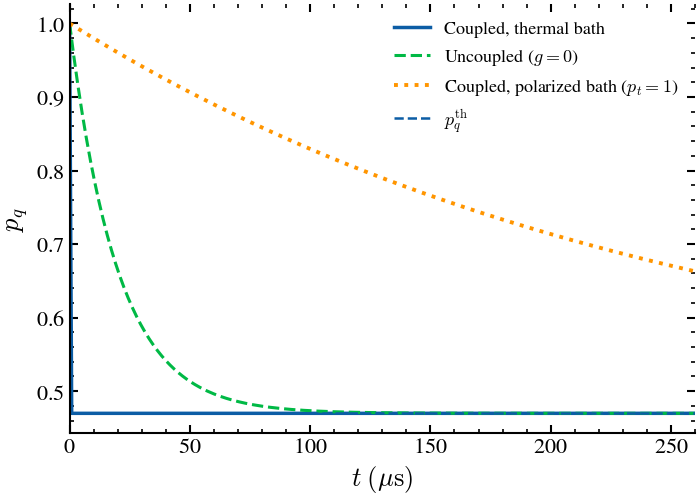

In [ ]:
# Gamma_min = 7e4
# Gamma_max = 1e6

Gamma_min = 1e3
Gamma_max = 1e4
T=20e-3

# result = solve_qubit_tls(

#     B_static,
#     X,
#     Y,
#     mask,
#     sigma,

#     omega_0,
#     Gamma_q,
#     g,

#     Gamma_min,
#     Gamma_max,

#     T=T,

#     p_q0=1,
#     p_t0=None,

#     t_span=(0.0, 1e-3),
#     n_eval=200,

#     method="LSODA",

#     rtol=1e-8,
#     atol=1e-12,

#     seed=1234,
# )

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Resonance calculation
# ------------------------------------------------------------------
B0 = 3.6e-3
omega_TLS = GAMMA_E * B0

print(f"omega_TLS / 2pi = {omega_TLS/(2*np.pi)/1e6:.3f} MHz")

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
omega_0 = omega_TLS
Gamma_q = 1 / (20e-6)
T1      = 100e-6
T_bath  = T

Gamma_1 = 1 / T1
Gamma_2 = (Gamma_1 + Gamma_q) / 2

g_target_ratio = 5.0
g = np.sqrt(g_target_ratio * Gamma_q * Gamma_2 / 2)

print(f"g / 2pi = {g/(2*np.pi)/1e6:.3f} MHz")
print(
    f"On-resonance Gamma_qt = {2*g**2/Gamma_2:.3e} rad/s"
    f"  vs  Gamma_q = {Gamma_q:.3e} rad/s"
)

t_span = (0, 13 / Gamma_q)
n_eval = 300
p_q0 = 1.0

# ------------------------------------------------------------------
# Coupled dynamics -- thermal bath
# ------------------------------------------------------------------
out_coupled = solve_qubit_tls(
    B_static, X, Y, mask, sigma,

    omega_0,
    Gamma_q,
    g,

    Gamma_min,
    Gamma_max,

    T=T_bath,

    p_q0=p_q0,
    p_t0=None,

    t_span=t_span,
    n_eval=n_eval,

    method="LSODA",

    rtol=1e-8,
    atol=1e-12,

    seed=1234,
    )

# )

# ------------------------------------------------------------------
# Uncoupled comparison
# ------------------------------------------------------------------
t_eval = out_coupled["t"]

p_q_th = thermal_excited_population(omega_0, T_bath)

p_q_uncoupled = (
    p_q_th
    + (p_q0 - p_q_th) * np.exp(-Gamma_q * t_eval)
)

# ------------------------------------------------------------------
# Coupled dynamics -- fully polarized bath
# ------------------------------------------------------------------
p_t0_polarized = np.ones(mask.shape)

out_polarized = solve_qubit_tls(
    B_static, X, Y, mask, sigma,

    omega_0,
    Gamma_q,
    g,

    Gamma_min,
    Gamma_max,

    T=T_bath,

    p_q0=p_q0,
    p_t0=p_t0_polarized,

    t_span=t_span,
    n_eval=n_eval,

    method="LSODA",

    rtol=1e-8,
    atol=1e-12,

    seed=1234,
    )





# ==================================================================
# Plot -- PRB/PRL style
# ==================================================================

fig, ax = plt.subplots(figsize=(7.2, 5.2))

# Coupled, thermal bath
ax.plot(
    out_coupled["t"] * 1e6,
    out_coupled["p_q"],
    lw=2.5,
    label="Coupled, thermal bath",
)

# Uncoupled
ax.plot(
    t_eval * 1e6,
    p_q_uncoupled,
    "--",
    lw=2.2,
    label=r"Uncoupled ($g=0$)",
)

# Coupled, polarized bath
ax.plot(
    out_polarized["t"] * 1e6,
    out_polarized["p_q"],
    ":",
    lw=2.8,
    label=r"Coupled, polarized bath ($p_t=1$)",
)

# Thermal equilibrium
ax.axhline(
    p_q_th,
    lw=1.8,
    ls="--",
    label=r"$p_q^{\mathrm{th}}$",
)

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------
ax.set_xlabel(r"$t\;(\mu\mathrm{s})$", fontsize=19)
ax.set_ylabel(r"$p_q$", fontsize=19)

# ------------------------------------------------------------------
# Tick formatting
# ------------------------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
    width=1.5,
    length=6,
)

ax.tick_params(
    axis="both",
    which="minor",
    width=1.2,
    length=3,
)

# Minor ticks
ax.minorticks_on()

# ------------------------------------------------------------------
# Spines
# ------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
ax.legend(
    fontsize=13,
    frameon=False,
    loc="best",
)

# ------------------------------------------------------------------
# Limits
# ------------------------------------------------------------------
ax.set_xlim(
    0,
    t_span[1] * 1e6
)
#ax.loglog()

# ------------------------------------------------------------------
# Layout
# ------------------------------------------------------------------
fig.tight_layout()

fig.savefig(
    "qubit_tls_avg_in2.pdf",
    bbox_inches="tight",
)

plt.show()

/tmp/ipykernel_1763/971341434.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(out_coupled["t"] * 1e6),
/tmp/ipykernel_1763/971341434.py:13: RuntimeWarning: divide by zero encountered in log
  np.log(t_eval * 1e6),
/tmp/ipykernel_1763/971341434.py:22: RuntimeWarning: divide by zero encountered in log
  np.log(out_polarized["t"] * 1e6),


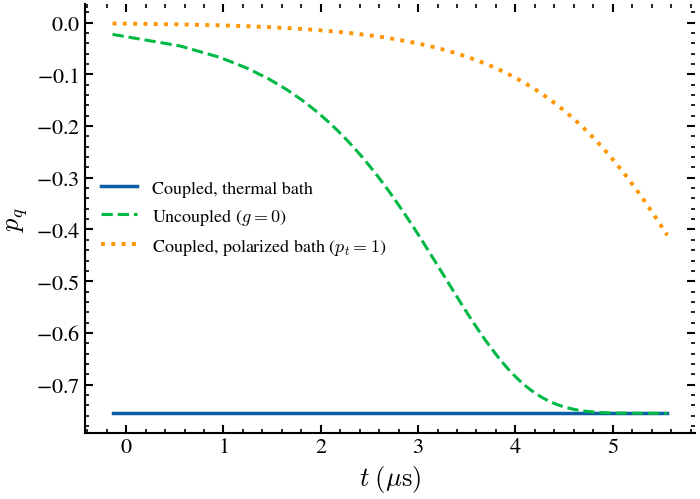

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))

# Coupled, thermal bath
ax.plot(
    np.log(out_coupled["t"] * 1e6),
    np.log(out_coupled["p_q"]),
    lw=2.5,
    label="Coupled, thermal bath",
)

# Uncoupled
ax.plot(
    np.log(t_eval * 1e6),
    np.log(p_q_uncoupled),
    "--",
    lw=2.2,
    label=r"Uncoupled ($g=0$)",
)

# Coupled, polarized bath
ax.plot(
    np.log(out_polarized["t"] * 1e6),
    np.log(out_polarized["p_q"]),
    ":",
    lw=2.8,
    label=r"Coupled, polarized bath ($p_t=1$)",
)

# Thermal equilibrium
# ax.axhline(
#     p_q_th,
#     lw=1.8,
#     ls="--",
#     label=r"$p_q^{\mathrm{th}}$",
# )

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------
ax.set_xlabel(r"$t\;(\mu\mathrm{s})$", fontsize=19)
ax.set_ylabel(r"$p_q$", fontsize=19)

# ------------------------------------------------------------------
# Tick formatting
# ------------------------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
    width=1.5,
    length=6,
)

ax.tick_params(
    axis="both",
    which="minor",
    width=1.2,
    length=3,
)

# Minor ticks
ax.minorticks_on()

# ------------------------------------------------------------------
# Spines
# ------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
ax.legend(
    fontsize=13,
    frameon=False,
    loc="best",
)

# ------------------------------------------------------------------
# Limits
# ------------------------------------------------------------------
# ax.set_xlim(
#     0,
#     t_span[1] * 1e6
# )
#ax.loglog()
#ax.semilogy()

# ------------------------------------------------------------------
# Layout
# ------------------------------------------------------------------
fig.tight_layout()

fig.savefig(
    "qubit_tls_avg_in2.pdf",
    bbox_inches="tight",
)

plt.show()

Gamma_1 range:
1000.3186957681102 999992.5394835367

T1 range:
1.000007460572123e-06 0.0009996814057665238


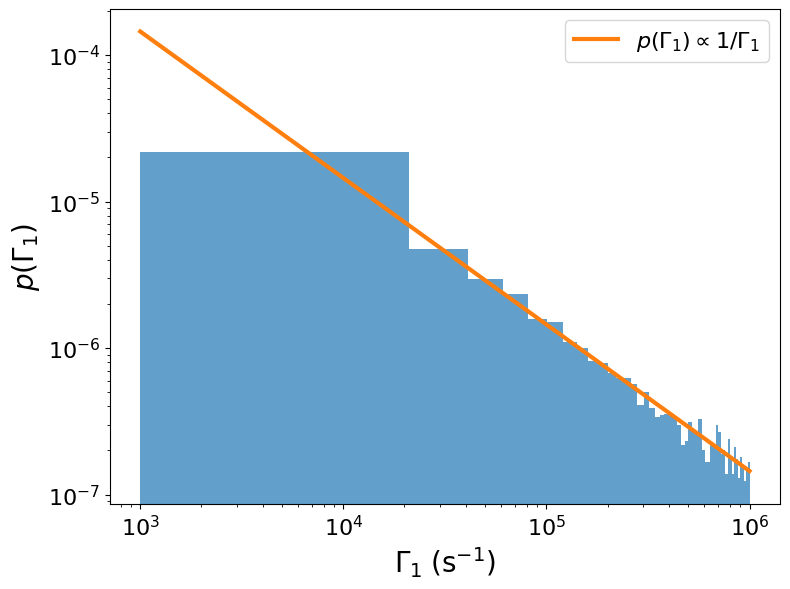

In [ ]:
Gamma_1 = result["info"]["Gamma_1"]
T1 = result["info"]["T1"]

print("Gamma_1 range:")
print(Gamma_1.min(), Gamma_1.max())

print("\nT1 range:")
print(T1.min(), T1.max())
plt.figure(figsize=(8, 6))

plt.hist(
    Gamma_1,
    bins=50,
    density=True,
    alpha=0.7
)

Gamma_plot = np.logspace(
    np.log10(Gamma_min),
    np.log10(Gamma_max),
    500
)

pdf = 1.0 / (
    Gamma_plot
    * np.log(Gamma_max / Gamma_min)
)

plt.plot(
    Gamma_plot,
    pdf,
    linewidth=3,
    label=r"$p(\Gamma_1)\propto 1/\Gamma_1$"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$\Gamma_1\;(\mathrm{s}^{-1})$", fontsize=20)
plt.ylabel(r"$p(\Gamma_1)$", fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

# Appendix: Difussion Finite Differences methods

Here we illustrate the numerical method used to solve the dynamics in 1D and 2D

### 1D

This is a simple example in 1D of the numerical method used to solve the dynamics of the bath system

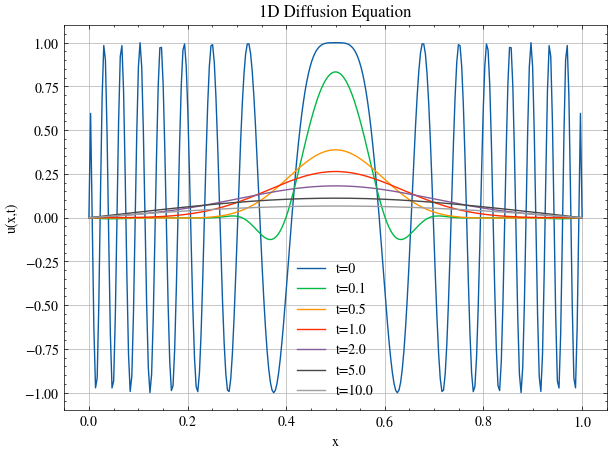

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# Parameters
# ======================================================

L = 1.0          # Length of domain
D = 0.01         # Diffusion coefficient

Nx = 300         # Number of spatial points
dx = L / (Nx - 1)

T = 10.0         # Final time

# FTCS stability condition:
# D*dt/dx^2 <= 0.5
dt = 0.4 * dx**2 / D

Nt = int(T / dt)

x = np.linspace(0, L, Nx)

# ======================================================
# Initial condition
# ======================================================

u = np.cos(-200 * (x - 0.5)**2)   # Gaussian

# Boundary conditions
u[0] = 0
u[-1] = 0

# ======================================================
# Time evolution
# ======================================================

r = D * dt / dx**2

times_to_save = [0, 0.1, 0.5, 1, 2, 5, 10]
saved = {}

t = 0

for n in range(Nt + 1):

    if np.any(np.isclose(t, times_to_save, atol=dt/2)):
        saved[round(t, 2)] = u.copy()

    unew = u.copy()

    unew[1:-1] = (
        u[1:-1]
        + r * (u[2:] - 2*u[1:-1] + u[:-2])
    )

    # Dirichlet boundaries
    unew[0] = 0
    unew[-1] = 0

    u = unew
    t += dt

# ======================================================
# Plot
# ======================================================

plt.figure(figsize=(7,5))

for time, profile in saved.items():
    plt.plot(x, profile, label=f"t={time}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D Diffusion Equation")
plt.legend()
plt.grid(True)
plt.show()

## 2D

Extension to 2D

In [ ]:
"""
Solve the 2D vector diffusion equation

    d m / dt = D * Laplacian_2D ( m - chi * B )

where m = m(x, y, t) and B = B(x, y, t) are 3-component vector fields
(mx, my, mz) and (Bx, By, Bz), but the spatial domain is 2D (x, y).

Since the equation is linear in m for a given (fixed or time-dependent) B,
it separates into three independent scalar diffusion equations, one per
Cartesian component:

    d m_i / dt = D * Lap(m_i) - D*chi * Lap(B_i),   i = x, y, z

Method: explicit FTCS (forward-time, central-space) with 5-point Laplacian.
Stability (2D, explicit): D*dt*(1/dx^2 + 1/dy^2) <= 1/2  (we use a safety factor).

Boundary conditions: Neumann (zero-flux) by default, easily swapped to
Dirichlet or periodic (see comments in `laplacian2d`).
"""

import numpy as np


def laplacian2d(f, dx, dy, bc="dirichlet"):
    """
    5-point discrete Laplacian of a 2D array f, shape (Nx, Ny).

    bc: "neumann"  -> zero-flux (ghost cells = edge values), default
        "dirichlet"-> f=0 outside domain (ghost cells = 0)
        "periodic" -> wrap-around
    """
    if bc == "periodic":
        f_xp = np.roll(f, -1, axis=0)
        f_xm = np.roll(f, 1, axis=0)
        f_yp = np.roll(f, -1, axis=1)
        f_ym = np.roll(f, 1, axis=1)
    else:
        if bc == "neumann":
            pad_mode = "edge"
        elif bc == "dirichlet":
            pad_mode = "constant"
        else:
            raise ValueError(f"Unknown bc: {bc}")
        f_pad = np.pad(f, 1, mode=pad_mode)
        f_xp = f_pad[2:, 1:-1]
        f_xm = f_pad[:-2, 1:-1]
        f_yp = f_pad[1:-1, 2:]
        f_ym = f_pad[1:-1, :-2]

    lap = (f_xp - 2.0 * f + f_xm) / dx**2 + (f_yp - 2.0 * f + f_ym) / dy**2
    return lap


def step_ftcs(m, B, D, chi, dx, dy, dt, bc="dirichlet"):
    """
    Advance m (shape (Nx, Ny, 3)) by one explicit Euler step.
    B may be a static array of the same shape, or a time-dependent
    field already evaluated at the current time.
    """
    m_new = np.empty_like(m)
    for i in range(3):  # x, y, z components
        lap_m = laplacian2d(m[..., i], dx, dy, bc=bc)
        lap_B = laplacian2d(B[..., i], dx, dy, bc=bc)
        m_new[..., i] = m[..., i] + dt * D * (lap_m - chi * lap_B)
    return m_new


def max_stable_dt(D, dx, dy, safety=0.9):
    """Explicit FTCS stability limit for the 2D diffusion equation."""
    return safety * 0.5 / (D * (1.0 / dx**2 + 1.0 / dy**2))


def solve_diffusion_2d(
    m0,
    B_func,
    D,
    chi,
    dx,
    dy,
    dt,
    n_steps,
    bc="dirichlet",
    save_every=1,
):
    """
    m0      : initial condition, array (Nx, Ny, 3)
    B_func  : callable(t) -> array (Nx, Ny, 3), the external field B at time t
              (pass `lambda t: B_static` if B doesn't change in time)
    D, chi  : scalars (diffusion constant, susceptibility)
    dx, dy  : grid spacing
    dt      : time step (must satisfy stability limit, see max_stable_dt)
    n_steps : number of time steps to take
    bc      : "neumann" | "dirichlet" | "periodic"
    save_every : store a snapshot every this many steps

    Returns:
        times : array of saved times, shape (n_saved,)
        m_hist: array of saved fields, shape (n_saved, Nx, Ny, 3)
    """
    m = m0.copy()
    t = 0.0

    times = [t]
    m_hist = [m.copy()]

    for n in range(1, n_steps + 1):
        B = B_func(t)
        m = step_ftcs(m, B, D, chi, dx, dy, dt, bc=bc)
        t += dt

        if n % save_every == 0:
            times.append(t)
            m_hist.append(m.copy())

    return np.array(times), np.array(m_hist)


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # Grid
    Nx, Ny = 80, 80
    Lx, Ly = 1.0, 1.0
    dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    # Physical parameters
    D = 1.0
    chi = 0.5

    # Initial magnetization: a Gaussian bump in mz, zero in-plane components
    m0 = np.zeros((Nx, Ny, 3))
    m0[..., 2] = np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / (2 * 0.05**2))

    # External field B: static, uniform in z, e.g. a step-like profile in x
    B_static = np.zeros((Nx, Ny, 3))
    B_static[..., 2] = 0.2 * np.tanh((X - 0.5) / 0.05)

    def B_func(t):
        # Change this if B depends on time; here it's constant.
        return B_static

    # Time step from stability limit
    dt = max_stable_dt(D, dx, dy, safety=0.9)
    n_steps = 2000
    save_every = 100

    times, m_hist = solve_diffusion_2d(
        m0, B_func, D, chi, dx, dy, dt, n_steps,
        bc="dirichlet", save_every=save_every,
    )

    print(f"dt = {dt:.3e}, total simulated time = {times[-1]:.3e}")
    print(f"Saved {len(times)} snapshots, m_hist shape = {m_hist.shape}")

    # Quick sanity check: mz at the center over time
    ic, jc = Nx // 2, Ny // 2
    for k in range(0, len(times), max(1, len(times) // 10)):
        print(f"t={times[k]:.4f}  m_z(center)={m_hist[k, ic, jc, 2]:.5f}")

dt = 3.605e-05, total simulated time = 7.210e-02
Saved 21 snapshots, m_hist shape = (21, 80, 80, 3)
t=0.0000  m_z(center)=0.98410
t=0.0072  m_z(center)=0.15581
t=0.0144  m_z(center)=0.08938
t=0.0216  m_z(center)=0.06506
t=0.0288  m_z(center)=0.05253
t=0.0361  m_z(center)=0.04484
t=0.0433  m_z(center)=0.03955
t=0.0505  m_z(center)=0.03557
t=0.0577  m_z(center)=0.03241
t=0.0649  m_z(center)=0.02979
t=0.0721  m_z(center)=0.02757


Saved plot to m_snapshots.png


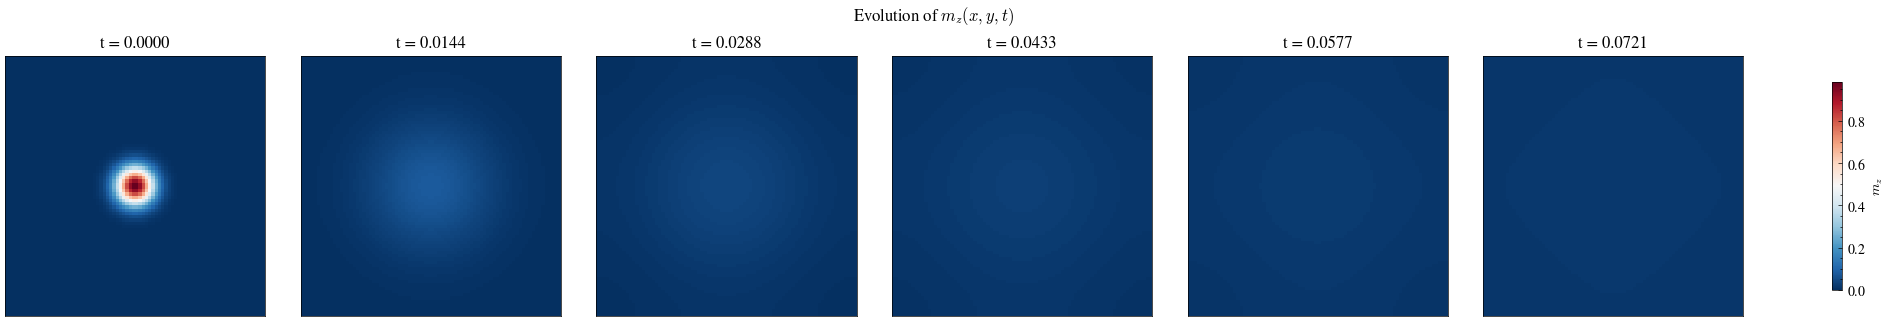

In [ ]:
"""
Quick plotting: snapshots of the m field (heatmaps) at a few times.
Run after / together with diffusion2d_vector.py.
"""

import numpy as np
import matplotlib.pyplot as plt
#from diffusion2d_vector import solve_diffusion_2d, max_stable_dt

# --- same setup as before ---
Nx, Ny = 80, 80
Lx, Ly = 1.0, 1.0
dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

D, chi = 1.0, 0.5

m0 = np.zeros((Nx, Ny, 3))
m0[..., 2] = np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / (2 * 0.05**2))

# B_static = np.zeros((Nx, Ny, 3))
# B_static[..., 2] = 0.2 * np.tanh((X - 0.5) / 0.05)

B_static = np.zeros((Nx, Ny, 3))
B_static[..., 0] = 0.0002

def B_func(t):
    return B_static

dt = max_stable_dt(D, dx, dy, safety=0.9)
n_steps = 2000
save_every = 100

times, m_hist = solve_diffusion_2d(
    m0, B_func, D, chi, dx, dy, dt, n_steps,
    bc="neumann", save_every=save_every,
)

# --- plot mz snapshots at a handful of times ---
component = 2       # 0=mx, 1=my, 2=mz
n_panels = 6
idxs = np.linspace(0, len(times) - 1, n_panels).astype(int)

fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3.2), constrained_layout=True)

vmin, vmax = m_hist[..., component].min(), m_hist[..., component].max()

for ax, k in zip(axes, idxs):
    im = ax.pcolormesh(X, Y, m_hist[k, ..., component], cmap="RdBu_r",
                        vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(f"t = {times[k]:.4f}")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label=r"$m_z$")
fig.suptitle(r"Evolution of $m_z(x,y,t)$")

print("Saved plot to m_snapshots.png")

# Appendix: Dynamics only relaxation

Gamma_max = 2.618e+02 s^-1
Gamma_min = 8.784e-02 s^-1


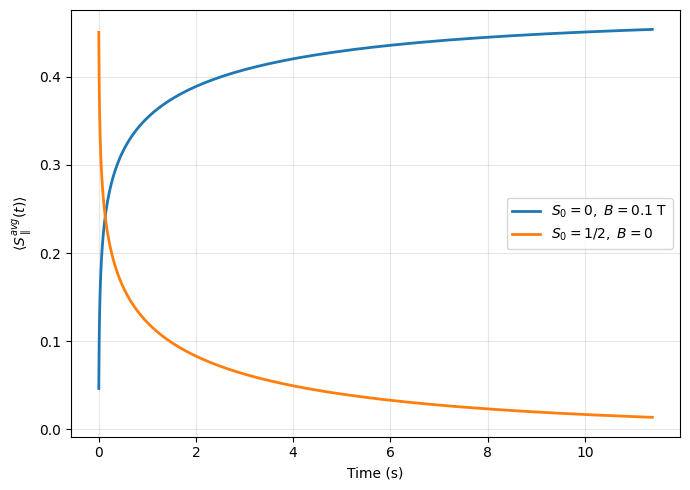

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import (
    physical_constants,
    k as k_B,
    hbar,
)
from scipy.integrate import quad

# ============================================================
# Constants
# ============================================================

g = 1.0
mu_B = physical_constants["Bohr magneton"][0]
gam = g * mu_B

# Typical aluminum qubit temperature
T = 0.020          # K (20 mK)

A = 1e-7
lambda_max = 8.0

Gamma_max = A * k_B * T / hbar
Gamma_min = Gamma_max * np.exp(-lambda_max)

print(f"Gamma_max = {Gamma_max:.3e} s^-1")
print(f"Gamma_min = {Gamma_min:.3e} s^-1")

# ============================================================
# Spin relaxation function
# ============================================================

def Seq(B, T):
    return -0.5 * np.tanh(gam * B / (2 * k_B * T))


def S(t, Gamma, S0, B, T):
    """
    Spin expectation value.

    Parameters
    ----------
    t : float or ndarray
        Time (s)
    Gamma : float
        Relaxation rate (1/s)
    S0 : float
        Initial spin
    B : float
        Magnetic field (Tesla)
    T : float
        Temperature (K)
    """
    seq = Seq(B, T)
    return (S0 - seq) * np.exp(-Gamma * t) + seq


# ============================================================
# Distribution P(Gamma)
# ============================================================

def P(Gamma):
    return 1.0 / (lambda_max * Gamma)


# ============================================================
# Average over Gamma
# ============================================================

def S_avg(t, S0, B, T):
    """
    Average of S over the Gamma distribution.
    """

    integrand = lambda Gamma: P(Gamma) * S(t, Gamma, S0, B, T)

    value, _ = quad(
        integrand,
        Gamma_min,
        Gamma_max,
        limit=300,
    )

    return value


# ============================================================
# Time array
# ============================================================

t = np.logspace(
    np.log10(1 / Gamma_max),
    np.log10(1 / Gamma_min),
    300,
)

# ============================================================
# Case 1:
# S0 = 0, finite magnetic field
# ============================================================

B1 = 0.1      # Tesla

S_case1 = -np.array([
    S_avg(tt, S0=0.0, B=B1, T=T)
    for tt in t
])

S_case11 = -np.array([
    S_avg(tt, S0=0.0, B=B1/10, T=T)
    for tt in t
])

S_case111 = -np.array([
    S_avg(tt, S0=0.0, B=B1/100, T=T)
    for tt in t
])

# ============================================================
# Case 2:
# B = 0, S0 = 1/2
# ============================================================

S_case2 = np.array([
    S_avg(tt, S0=0.5, B=0.0, T=T)
    for tt in t
])

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    t,
    S_case1,
    lw=2,
    label=rf"$S_0=0,\ B={B1}\ \rm T$"
)

# plt.plot(
#     t,
#     S_case11,
#     lw=2,
#     label=rf"$S_0=0,\ B={B1/10}\ \rm T$"
# )

# plt.plot(
#     t,
#     S_case111,
#     lw=2,
#     label=rf"$S_0=0,\ B={B1/100}\ \rm T$"
# )

plt.plot(
    t,
    S_case2,
    lw=2,
    label=r"$S_0=1/2,\ B=0$"
)

plt.xlabel("Time (s)")
plt.ylabel(r"$\langle S_{\parallel}^{avg}(t)\rangle$")
#plt.title(r"Averaged spin relaxation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

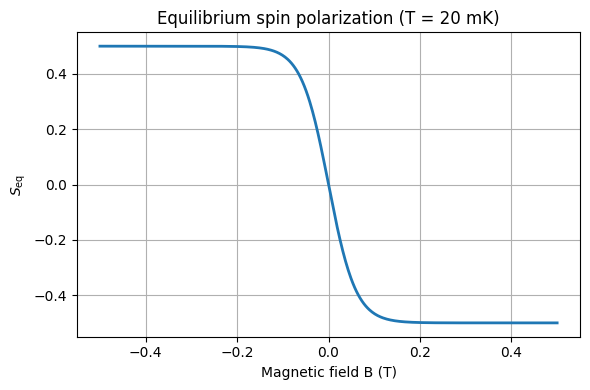

In [ ]:
# ============================================================
# Plot Seq(B)
# ============================================================

# Magnetic field range (Tesla)
B = np.linspace(-0.5, 0.5, 500)

Seq_values = Seq(B, T)

plt.figure(figsize=(6,4))

plt.plot(B, Seq_values, lw=2)

plt.xlabel("Magnetic field B (T)")
plt.ylabel(r"$S_{\rm eq}$")
plt.title(f"Equilibrium spin polarization (T = {T*1e3:.0f} mK)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Appendix: Superscreen Numerical

Superscreen is a python package that solves the London equations in 2d for thin superconductors, here we use it to check having similar results to FastHenry. It is much more inefficient because of its computational cost, for this reason Fast Henry is chosen for the work.

In [ ]:
!pip install superscreen

In [ ]:
import superscreen as sc
from superscreen.geometry import box

# Square 10 um x 10 um
film = sc.Polygon(
    name="film",
    layer="base",
    points=box(10, 10),
)

layer = sc.Layer(
    "base",
    london_lambda=0.1,  # um
    thickness=0.025,    # um
    z0=0,
)

device = sc.Device(
    "square_device",
    layers=[layer],
    films=[film],
)

device.make_mesh(max_edge_length=0.5)

print(device)

Device(
    "square_device", 
    layers=[
        Layer('base', Lambda=0.400, thickness=0.025, london_lambda=0.100, z0=0.000),
    ], 
    films=[
        Polygon(name='film', layer='base', points=<ndarray: shape=(100, 2)>),
    ], 
    holes=None, 
    terminals=None, 
    abstract_regions=None, 
    length_units="um",
)


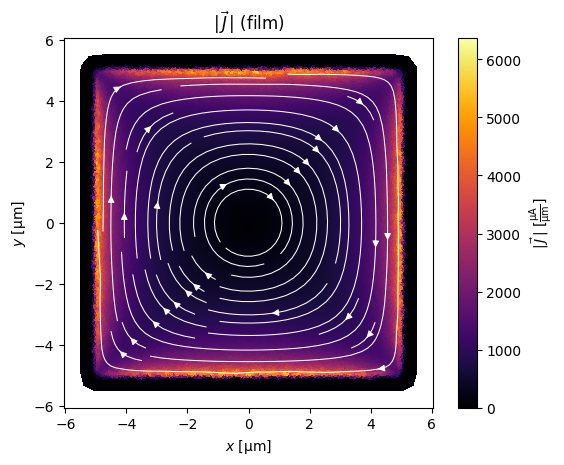

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import superscreen as sc
from superscreen.geometry import box

# =====================
# Layer
# =====================

layer = sc.Layer(
    "base",
    Lambda=0.1,      # Pearl length [um]
    z0=0,
)

# =====================
# Film
# =====================

film = sc.Polygon(
    "film",
    layer="base",
    points=box(10, 10),
)

# =====================
# Device
# =====================

device = sc.Device(
    "square",
    layers=[layer],
    films=[film],
)

device.make_mesh(max_edge_length=0.15)

# =====================
# Applied field
# =====================

def applied_field(x, y, z):
    return np.ones_like(x)

# =====================
# Solve
# =====================

solution = sc.solve(
    device=device,
    applied_field=applied_field,
    field_units="mT",
)[0]

print(solution)
import matplotlib.pyplot as plt

fig, ax = solution.plot_currents(
    films="film",
    streamplot=True,
)

plt.show()

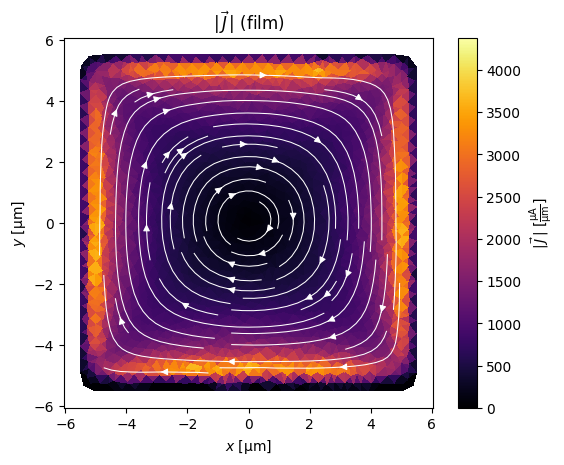

In [ ]:
fig, ax = solution.plot_currents()
plt.show()

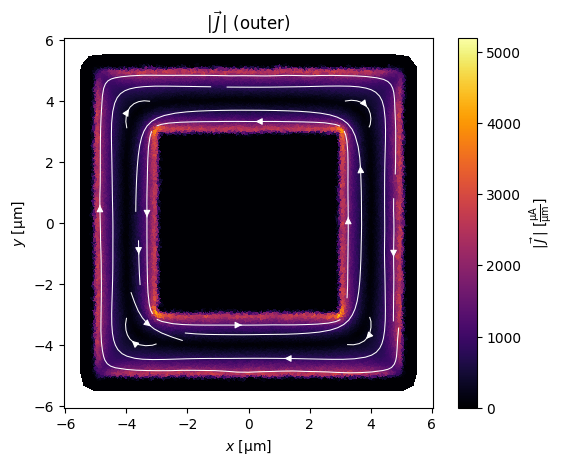

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import superscreen as sc
from superscreen.geometry import box

# =====================
# Layer
# =====================
layer = sc.Layer(
    "base",
    Lambda=0.1,
    z0=0,
)

# =====================
# Geometry: outer square + inner hole
# =====================
outer = sc.Polygon(
    "outer",
    layer="base",
    points=box(10, 10),
)

hole = sc.Polygon(
    "hole",
    layer="base",
    points=box(6,6),
)

# =====================
# Device
# =====================
device = sc.Device(
    "square_ring",
    layers=[layer],
    films=[outer],
    holes=[hole],
)

device.make_mesh(max_edge_length=0.15)

# =====================
# Applied field
# =====================
def applied_field(x, y, z):
    return np.ones_like(x)

# =====================
# Solve
# =====================
solution = sc.solve(
    device=device,
    applied_field=applied_field,
    field_units="mT",
)[0]

fig, ax = solution.plot_currents(
    films="outer",
    streamplot=True,
)
plt.show()

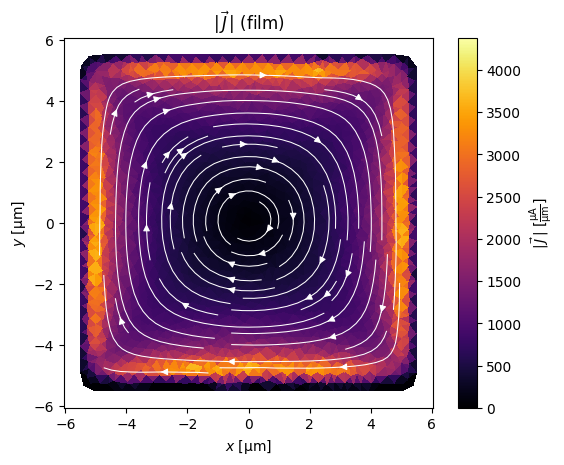

In [ ]:
import matplotlib.pyplot as plt

fig, ax = solution.plot_currents(
    films="film",
    streamplot=True,
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5,5,200)
y = np.linspace(-5,5,200)

X, Y = np.meshgrid(x,y)

positions = np.column_stack([
    X.ravel(),
    Y.ravel()
])

J = solution.interp_current_density(
    positions,
    film="film",
)

print(J.shape)
Jx = J[:,0].reshape(X.shape)
Jy = J[:,1].reshape(X.shape)

Jmag = np.sqrt(Jx**2 + Jy**2)

(40000, 2)


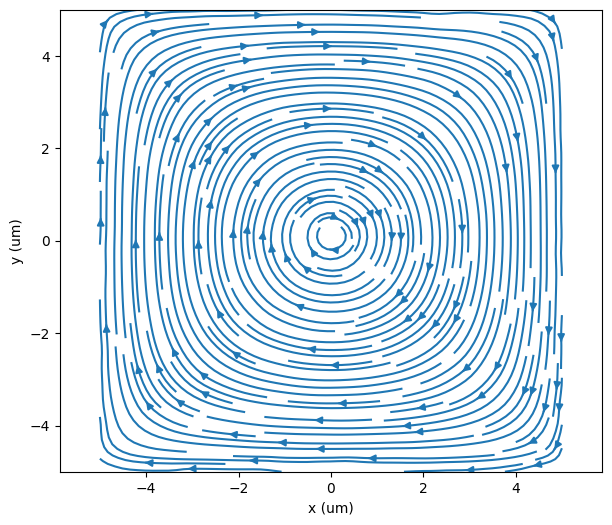

In [ ]:
plt.figure(figsize=(7,6))

plt.streamplot(
    X,
    Y,
    Jx,
    Jy,
    density=2
)

plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.axis("equal")
plt.show()

In [ ]:
import scipy.constants as const

def half_flux_quantum_field(n_um, m_um):
    """
    Magnetic field (Tesla) needed to thread half a flux quantum
    through a rectangle of dimensions n_um × m_um (micrometers).

    Parameters
    ----------
    n_um : float
        First dimension in micrometers.
    m_um : float
        Second dimension in micrometers.

    Returns
    -------
    B : float
        Required magnetic field in miliTesla.
    """
    phi0 = const.h / (2 * const.e)  # flux quantum (Wb)
    area = n_um * m_um * 1e-12      # m^2
    return 1e3*0.5 * phi0 / area
half_flux_quantum_field(6, 6)

0.028719914561971243

In [ ]:
!pip install superscreen

In [ ]:
lam_um = 0.07        # micrometers
b_um = 0.1           # micrometers
lam_um**2/b_um

0.049

n=0 circulating current: 0.0
n=1 circulating current: 44.69527556579308


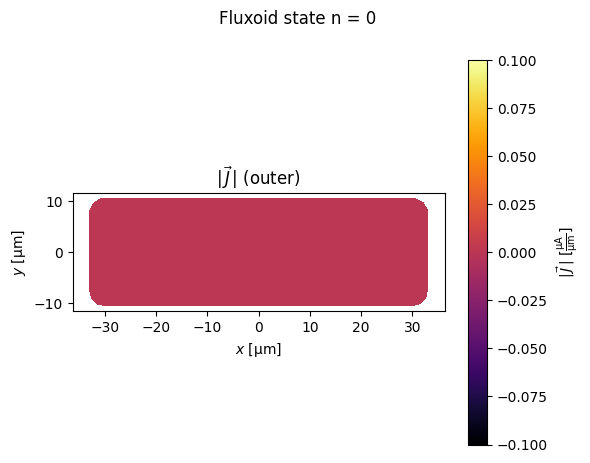

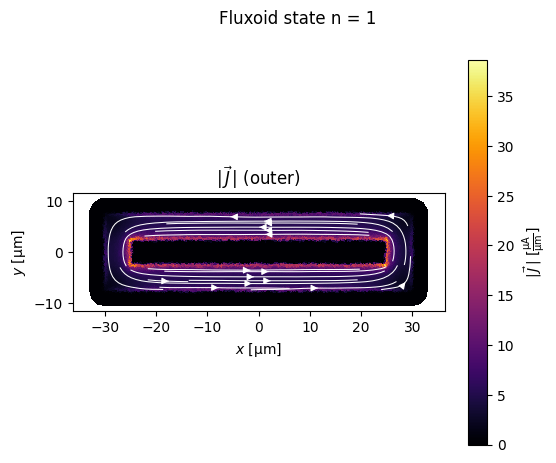

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import superscreen as sc
from superscreen.geometry import box
import scipy.constants as const

def half_flux_quantum_field(n_um, m_um):
    """
    Magnetic field (Tesla) needed to thread half a flux quantum
    through a rectangle of dimensions n_um × m_um (micrometers).

    Parameters
    ----------
    n_um : float
        First dimension in micrometers.
    m_um : float
        Second dimension in micrometers.

    Returns
    -------
    B : float
        Required magnetic field in miliTesla.
    """
    phi0 = const.h / (2 * const.e)  # flux quantum (Wb)
    area = n_um * m_um * 1e-12      # m^2
    return 0*1e3*0.5 * phi0 / area

# Layer
#layer = sc.Layer("base", Lambda=0.1, z0=0)
layer = sc.Layer("base", london_lambda=lam_um, thickness=b_um, z0=0)
W=5
Lx=60
Ly=15
lx=Lx-2*W
ly=Ly-2*W

# Geometry
outer = sc.Polygon("outer", layer="base", points=box(Lx, Ly))
hole = sc.Polygon("hole", layer="base", points=box(lx, ly))

# Device
device = sc.Device(
    "square_ring",
    layers=[layer],
    films=[outer],
    holes=[hole],
)

device.make_mesh(max_edge_length=0.495, smooth=20)

B0 = half_flux_quantum_field(lx, ly)  # mT

def applied_field(x, y, z):
    inside_hole = (np.abs(x) <= lx/2) & (np.abs(y) <= ly/2)
    return B0 * inside_hole.astype(float)

# Factorized model
model = sc.factorize_model(device=device, current_units="uA")

# n = 0
solution_n0 = sc.find_fluxoid_solution(
    model,
    fluxoids={"hole": 0},
    applied_field=applied_field,
    field_units="mT",
)

# n = 1
solution_n1 = sc.find_fluxoid_solution(
    model,
    fluxoids={"hole": 1},
    applied_field=applied_field,
    field_units="mT",
)

print("n=0 circulating current:", solution_n0.circulating_currents["hole"])
print("n=1 circulating current:", solution_n1.circulating_currents["hole"])

# Plot separately
fig0, ax0 = solution_n0.plot_currents(films="outer", streamplot=True, figsize=(6, 5))
fig0.suptitle("Fluxoid state n = 0")

fig1, ax1 = solution_n1.plot_currents(films="outer", streamplot=True, figsize=(6, 5))
fig1.suptitle("Fluxoid state n = 1")

plt.show()

Saved


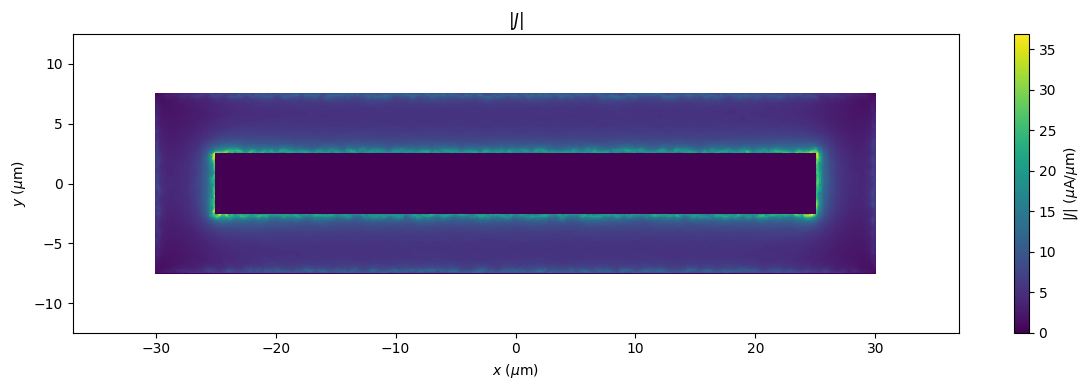

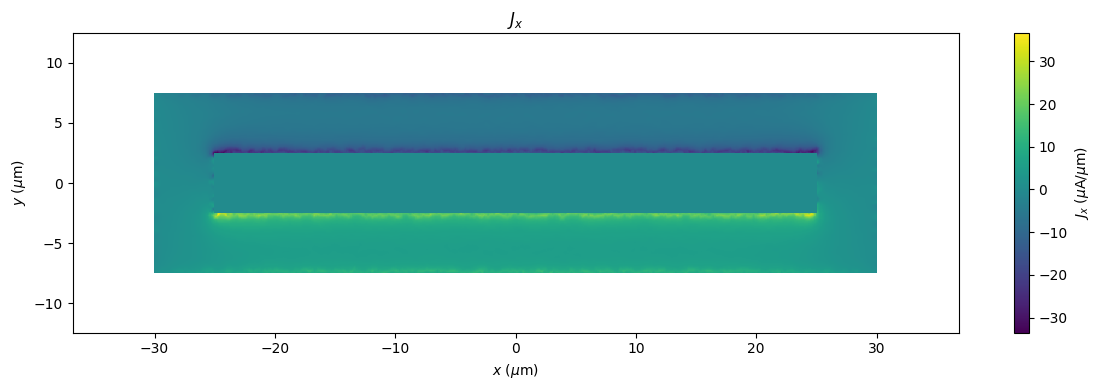

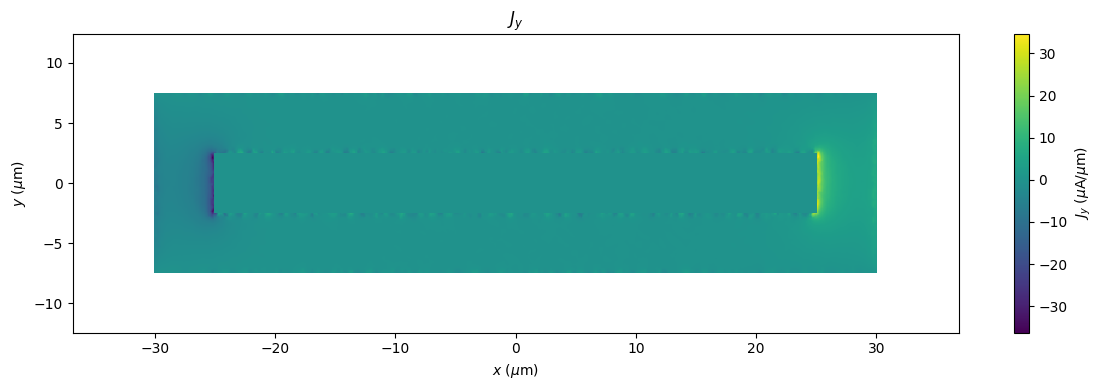

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Create regular grid
# ============================================================

Nx = 600
Ny = 600

x = np.linspace(-Lx/2, Lx/2, Nx)
x_ss=x
y = np.linspace(-Ly/2, Ly/2, Ny)
y_ss=y

X, Y = np.meshgrid(x, y)

positions = np.column_stack([
    X.ravel(),
    Y.ravel()
])

# ============================================================
# Interpolate current density
# ============================================================

J = solution_n1.interp_current_density(
    positions,
    film="outer",
    with_units=False,
)
J_ss=J

# ============================================================
# Reshape
# ============================================================

Jx = J[:, 0].reshape(Ny, Nx)
Jy = J[:, 1].reshape(Ny, Nx)

Jmag = np.sqrt(Jx**2 + Jy**2)
Jmag_ss=Jmag

# ============================================================
# Remove current inside hole
# ============================================================

hole_mask = (
    (np.abs(X) <= lx/2)
    &
    (np.abs(Y) <= ly/2)
)

Jx[hole_mask] = 0.0
Jy[hole_mask] = 0.0
Jmag[hole_mask] = 0.0

# ============================================================
# Save
# ============================================================

np.savez(
    "loop_superscreen_n1_50x5_no.npz",
    X=X,
    Y=Y,
    Jx=Jx,
    Jy=Jy,
    Jmag=Jmag,
)

print("Saved")

# ============================================================
# Plot |J|
# ============================================================

plt.figure(figsize=(12,4))

plt.pcolormesh(
    X,
    Y,
    Jmag,
    shading="auto"
)

plt.colorbar(label=r"$|J|$ ($\mu$A/$\mu$m)")
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$y$ ($\mu$m)")
plt.title(r"$|J|$")

plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Plot Jx
# ============================================================

plt.figure(figsize=(12,4))

plt.pcolormesh(
    X,
    Y,
    Jx,
    shading="auto"
)

plt.colorbar(label=r"$J_x$ ($\mu$A/$\mu$m)")
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$y$ ($\mu$m)")
plt.title(r"$J_x$")

plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Plot Jy
# ============================================================

plt.figure(figsize=(12,4))

plt.pcolormesh(
    X,
    Y,
    Jy,
    shading="auto"
)

plt.colorbar(label=r"$J_y$ ($\mu$A/$\mu$m)")
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$y$ ($\mu$m)")
plt.title(r"$J_y$")

plt.axis("equal")
plt.tight_layout()
plt.show()

In [ ]:
film = device.films["outer"]
print(dir(film))

['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__slots__', '__str__', '__subclasshook__', '_join_via', '_points', 'area', 'buffer', 'contains_points', 'copy', 'difference', 'extents', 'from_difference', 'from_hdf5', 'from_intersection', 'from_union', 'intersection', 'is_valid', 'layer', 'make_mesh', 'name', 'on_boundary', 'path', 'plot', 'points', 'polygon', 'resample', 'rotate', 'scale', 'set_layer', 'set_name', 'to_hdf5', 'translate', 'union']


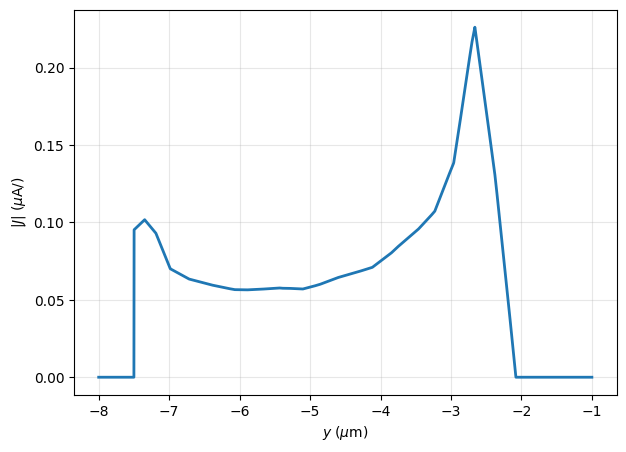

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Line x = 0
#y = np.linspace(-5.5, -2.5, 1000)
y = np.linspace(-8, -1, 5000)

positions = np.column_stack([
    np.zeros_like(y)+0,  # x = 0
    y
])

# Current density
J = solution_n0.interp_current_density(
    positions,
    film="outer",
)

Jx = J[:,0]
Jy = J[:,1]

Jmag = np.sqrt(Jx**2 + Jy**2)*1e-3/b_um

plt.figure(figsize=(7,5))

plt.plot(y, Jmag, lw=2)

plt.xlabel(r"$y\;(\mu{\rm m})$")
plt.ylabel(r"$|J|\;(\mu{\rm A}/)$")

plt.grid(alpha=0.3)

plt.show()

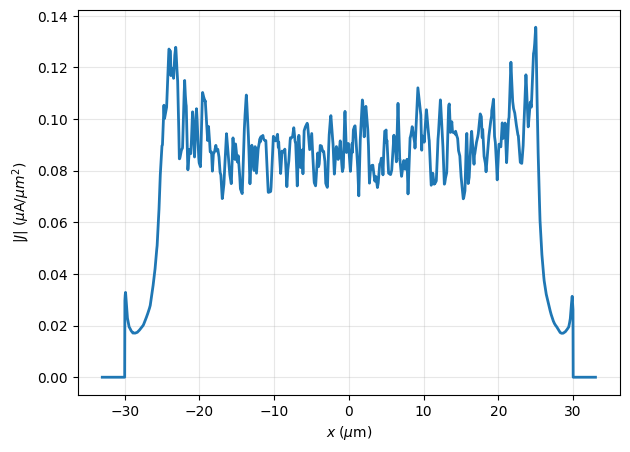

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Line x = 0
#y = np.linspace(-5.5, -2.5, 1000)
x = np.linspace(-33,33, 5000)

positions = np.column_stack([
    x,
    np.zeros_like(x)+2.75  # x = 0
])

# Current density
J = solution_n0.interp_current_density(
    positions,
    film="outer",
)

Jx = J[:,0]
Jy = J[:,1]

Jmag = np.sqrt(Jx**2 + Jy**2)*1e-3/b_um

plt.figure(figsize=(7,5))

plt.plot(x, Jmag, lw=2)

plt.xlabel(r"$x\;(\mu{\rm m})$")
plt.ylabel(r"$|J|\;(\mu{\rm A}/\mu m^2)$")

plt.grid(alpha=0.3)

plt.show()

I_SC   = 6.30000000e-06 mA
I_calc = 6.30430720e-06 mA
Relative error = 6.837e-04


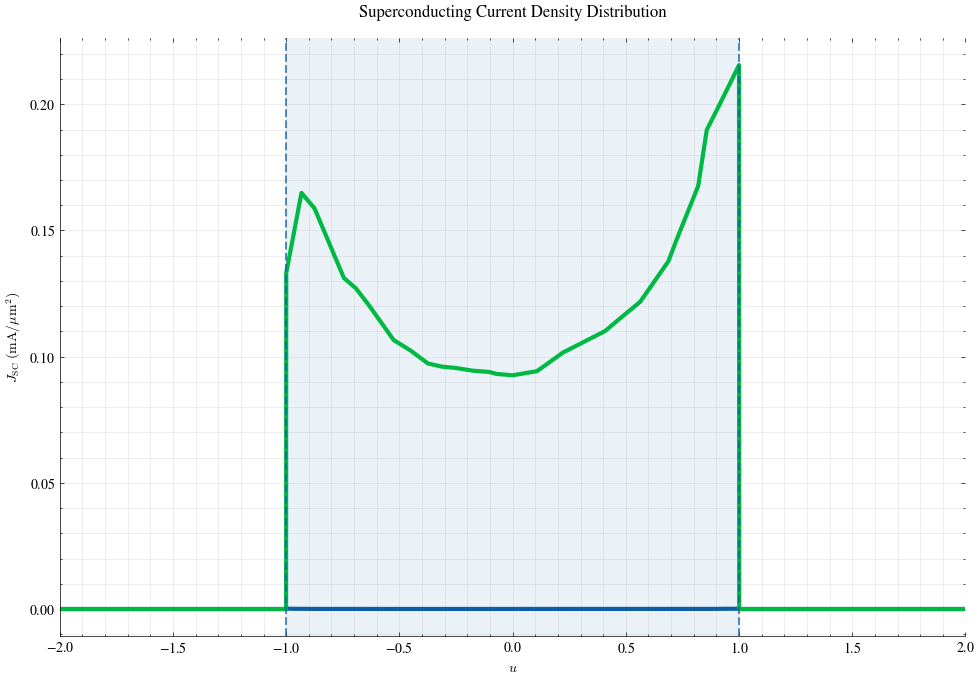

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Parameters
# ==========================
I_SC = 6.3e-6          # mA
lam = lam_um          # micrometers
b = b_um              # micrometers
W = 2.0               # micrometers
gamma = 0.2236

# Dimensionless penetration depth
lam_tilde = lam**2 / (b * W)

# Prefactor
prefactor = (2 * I_SC) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

# ==========================
# Current density function
# ==========================
def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    # Edge region
    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    # Bulk region
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor * J


# ==========================
# Grid
# ==========================
min_u = -2.0
max_u = 2.0

u = np.linspace(min_u, max_u, 5000)

# Avoid evaluating exactly at the singularities
eps = 1e-8
u[np.abs(u - 1) < eps] = 1 - eps
u[np.abs(u + 1) < eps] = -1 + eps

J_s = J_SC(u)

# ==========================
# Current normalization check
# ==========================
I_calc = (W * b / 2) * np.trapezoid(J_s, u)

print(f"I_SC   = {I_SC:.8e} mA")
print(f"I_calc = {I_calc:.8e} mA")
print(f"Relative error = {(I_calc - I_SC)/I_SC:.3e}")

Jmag[np.abs(u)>1]=0

# ==========================
# Plot styling
# ==========================

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    u,
    J_s,
    lw=3,
    label=(
        r"$J_{\rm SC}(u)$"
        "\n"
        + rf"$I_{{\rm calc}}=\frac{{Wb}}{{2}}\int J\,du"
        rf"={I_calc:.6e}\ {"mA"}$"
    )
)

ax.plot(
    u,
    Jmag,
    lw=3,
    label=(
        r"$J_{\rm SC}(u)$"
        "\n"
        + rf"$I_{{\rm calc}}=\frac{{Wb}}{{2}}\int J\,du"
        rf"={I_calc:.6e}\ {"mA"}$"
    )
)
# Strip boundaries
ax.axvline(-1, ls="--", lw=1.5, alpha=0.7)
ax.axvline(1, ls="--", lw=1.5, alpha=0.7)

# Highlight superconducting region
ax.axvspan(-1, 1, alpha=0.08)

ax.set_xlabel(r"$u$")
ax.set_ylabel(
    r"$J_{\rm SC}\;(\mathrm{mA}/\mu\mathrm{m}^{2})$"
)

ax.set_title(
    r"Superconducting Current Density Distribution",
    pad=15
)

ax.set_xlim(min_u, max_u)

ax.grid(True, which="both", alpha=0.3)

# ax.legend(
#     loc="best",
#     frameon=True,
#     fancybox=True
# )

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

I_SC original = 6.30430720e-06 mA
I_mag         = 1.57323622e-02 mA
Scale factor   = 4.00722225e-04
I_SC normalized= 1.00000000e+00 mA
Relative error = 6.256e+01


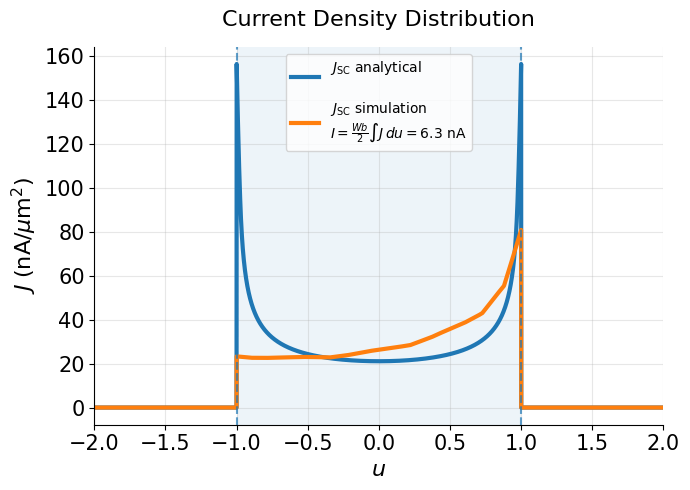

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Parameters
# ==========================
I_SC = 6.3e-6          # mA
lam = lam_um          # micrometers
b = b_um              # micrometers
W = 2.0               # micrometers
gamma = 0.2236

# Dimensionless penetration depth
lam_tilde = lam**2 / (b * W)

# Prefactor
prefactor = (2 * I_SC) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

# ==========================
# Current density function
# ==========================
def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    # Edge region
    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    # Bulk region
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor * J


# ==========================
# Grid
# ==========================
min_u = -2.0
max_u = 2.0
u = np.linspace(min_u, max_u, 5000)

# Avoid evaluating exactly at the singularities
eps = 1e-8
u[np.abs(u - 1) < eps] = 1 - eps
u[np.abs(u + 1) < eps] = -1 + eps

# ==========================
# Evaluate J_SC
# ==========================
J_s = J_SC(u)

# ==========================
# Prepare Jmag and compute its current
# ==========================
Jmag = np.asarray(Jmag, dtype=float).copy()
Jmag[np.abs(u) > 1] = 0.0

I_mag = (W * b / 2) * np.trapezoid(Jmag, u)

# ==========================
# Normalize J_SC so it carries the same current as Jmag
# ==========================
I_calc = (W * b / 2) * np.trapezoid(J_s, u)

# scale = I_mag / I_calc if I_calc != 0 else 1.0
# J_s_norm = J_s * scale

scale = I_calc / I_mag if I_mag != 0 else 1.0
Jmag_norm = Jmag * scale

#I_SC_norm = (W * b / 2) * np.trapezoid(J_s_norm, u)
I_SC_norm=1

print(f"I_SC original = {I_calc:.8e} mA")
print(f"I_mag         = {I_mag:.8e} mA")
print(f"Scale factor   = {scale:.8e}")
print(f"I_SC normalized= {I_SC_norm:.8e} mA")
print(f"Relative error = {(I_SC_norm - I_mag) / I_mag:.3e}")

# ==========================
# Plot styling
# ==========================
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    u,
    J_s*1e6,
    lw=3,
    label=(
        r"$J_{\rm SC}$ analytical"
        "\n"
        #+ rf"$I=\frac{{Wb}}{{2}}\int J\,du={I_SC/1e-6:.6e}\ \mathrm{{nA}}$"
    )
)

ax.plot(
    u,
    Jmag_norm*1e6,#nA
    lw=3,
    label=(
        r"$J_{\rm SC}$ simulation"
        "\n"
        + rf"$I=\frac{{Wb}}{{2}}\int J\,du={I_SC/1e-6:.2}\ \mathrm{{nA}}$"
    )
)

# Strip boundaries
ax.axvline(-1, ls="--", lw=1.5, alpha=0.7)
ax.axvline(1, ls="--", lw=1.5, alpha=0.7)

# Highlight superconducting region
ax.axvspan(-1, 1, alpha=0.08)

ax.set_xlabel(r"$u$", fontsize=16)
ax.set_ylabel(r"$J\;(\mathrm{nA}/\mu\mathrm{m}^{2})$", fontsize=16)
ax.set_title(r"Current Density Distribution", pad=15, fontsize=16)

ax.set_xlim(min_u, max_u)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", frameon=True, fancybox=True)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
#plt.savefig("current_density.png", dpi=350)
plt.show()

In [ ]:
#Check
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants

phi0 = h / (2 * e)   # flux quantum in Wb
n=1e-9

# ==========================
# Parameters
# ==========================
I_SC = 27e-3          # mA
lam = lam_um          # micrometers
b = b_um              # micrometers
W = 2.0               # micrometers
gamma = 0.2236

# Magnetic parameters for the force prefactor
mu_B = physical_constants['Bohr magneton'][0]  # A m^2
g = 2.0
mu_s = mu_B          #spin, replace with your magnetic moment if needed

# Convert lengths to SI for the force calculation
#um = 1e-6
#lam = lam_um * um
#b = b_um * um
#W = W_um * um

# Dimensionless penetration depth
lam_tilde = lam**2 / (b * W)

# Prefactor of J_SC
prefactor_J = (2 * I_SC) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

# ==========================
# Current density J_SC(u)
# Returns A/m^2
# ==========================
def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1.0)
    bulk = au <= (1 - lam_tilde)

    # Edge region
    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    # Bulk region
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J


# ==========================
# Numerical flux calculation
# ==========================
def compute_flux(X_vals_m, Z_m, Nu=6000):
    """
    Compute F_x(X,Z) and F_z(X,Z) for an array of X values at fixed Z.

    X_vals_m : array in meters
    Z_m      : fixed Z in meters
    Nu       : number of integration points in u
    """
    u = np.linspace(-1.0, 1.0, Nu)
    x_u = 0.5 * W * u                          # x(u) in meters
    J_ratio = J_SC(u) / I_SC                   # 1/m^2

    # Broadcast over all X values
    dx = x_u[:, None] - X_vals_m[None, :]      # shape (Nu, NX)

    log_term = np.log((dx**2 + Z_m**2) / (dx**2 + (Z_m + b)**2))

    # Use arctan2 for numerical robustness
    atan_term = np.arctan2(Z_m + b, dx) - np.arctan2(Z_m, dx)

    # Integrate over u
    integral_fx = np.trapezoid(J_ratio[:, None] * log_term, u, axis=0)
    integral_fz = np.trapezoid(J_ratio[:, None] * atan_term, u, axis=0)

    Fx = -(g * mu_s * mu_0 * W / (8 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 * W / (4 * np.pi)) * integral_fz

    return Fx, Fz


# ==========================
# Choose fixed Z and X range
# ==========================
Z_um = 0.005   # fixed height above the strip, in micrometers
Z_m = Z_um

X_um = np.linspace(-4.0, 4.0, 800)
X_m = X_um

Fx, Fz = compute_flux(X_m, Z_m, Nu=7000)
Fx=Fx/(n*phi0)
Fz=Fz/(n*phi0)

# ==========================
# Plot styling
# ==========================
plt.figure(figsize=(9, 6))
plt.plot(X_um, Fx, lw=3)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvline(W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvspan(-W_um/2, W_um/2, alpha=0.08)
plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_x(X,Z)$", fontsize=18)
#plt.title(rf"$F_x$ vs $X$ at fixed $Z={Z_um}\,\mu m}$", fontsize=20, pad=15)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(X_um, Fz, lw=3)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvline(W_um/2, ls="--", lw=1.5, alpha=0.7)
plt.axvspan(-W_um/2, W_um/2, alpha=0.08)
plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_z(X,Z)$", fontsize=18)
#plt.title(rf"$F_z$ vs $X$ at fixed $Z={Z_um}\,\mu{\rm m}$", fontsize=20, pad=15)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


Current normalization
---------------------
I_mag      = 1.73701337e-14
I_SC raw   = 2.70396972e-05
scale      = 6.42393795e-10
I_SC norm  = 1.73701337e-14



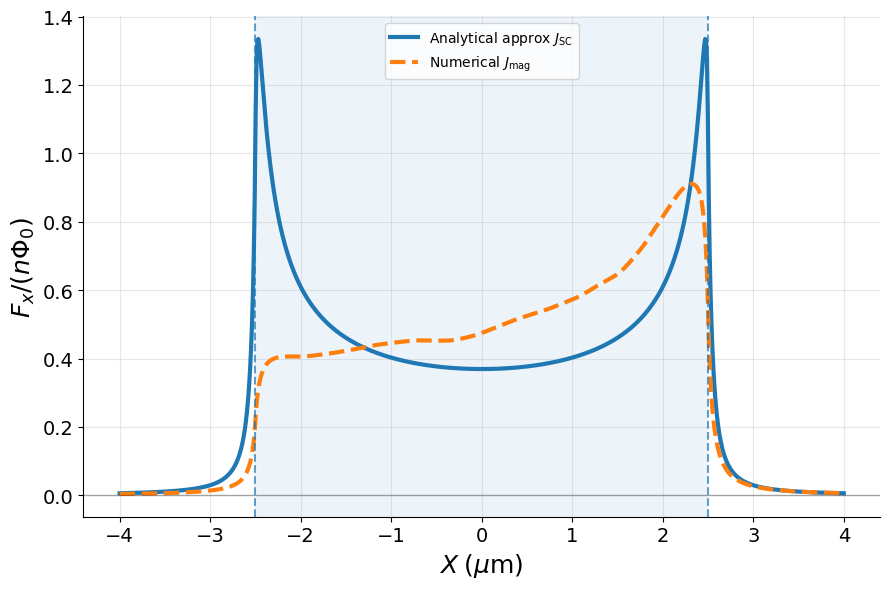

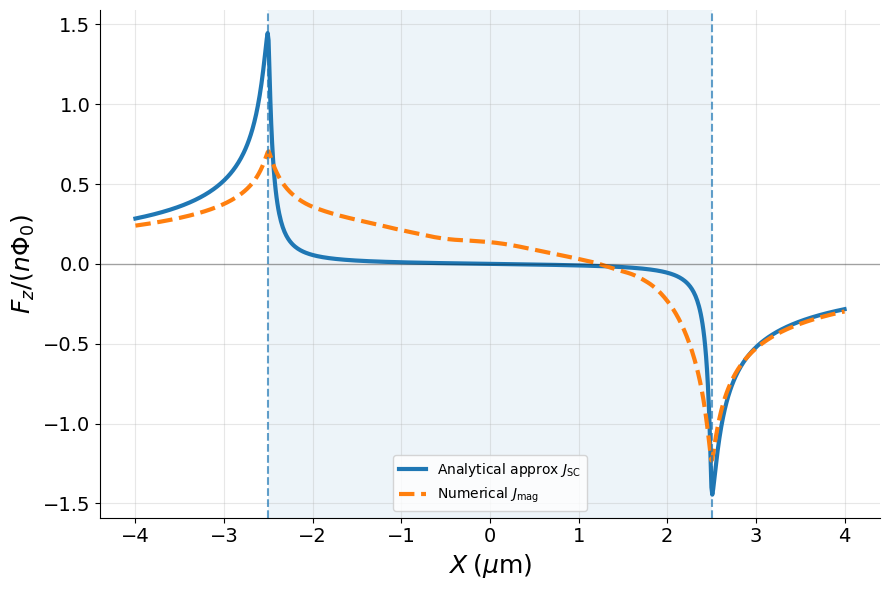

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d

phi0 = h / (2 * e)
n = 1e-9

# ============================================================
# Parameters
# ============================================================
um = 1e-6

I_SC = 27e-3 * 1e-3   # A
lam = lam_um * um     # m
b = b_um * um         # m
W = 5.0 * um          # m
gamma = 0.2236

mu_B = physical_constants['Bohr magneton'][0]
g = 1.0
mu_s = mu_B

# ============================================================
# J_SC definition
# ============================================================
lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_SC) / (
    np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde))
)

def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)

    J = np.zeros_like(u)

    edge = (au > (1 - lam_tilde)) & (au <= 1)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

# ============================================================
# EXACTLY THE SAME u GRID AS BEFORE
# ============================================================
u_full = np.linspace(-2.0, 2.0, 5000)

eps = 1e-8
u_full[np.abs(u_full - 1) < eps] = 1 - eps
u_full[np.abs(u_full + 1) < eps] = -1 + eps

# ============================================================
# Evaluate J_SC
# ============================================================
J_sc_raw = J_SC(u_full)

# ============================================================
# Prepare Jmag
# (assumes Jmag already exists on the same u grid)
# ============================================================
Jmag = np.asarray(Jmag, dtype=float).copy()
Jmag[np.abs(u_full) > 1] = 0.0

# ============================================================
# Match total currents
# ============================================================
I_sc_raw = (W * b / 2) * np.trapezoid(J_sc_raw, u_full)
I_mag    = (W * b / 2) * np.trapezoid(Jmag, u_full)

scale = I_mag / I_sc_raw

J_sc_norm = scale * J_sc_raw

I_sc_norm = (W * b / 2) * np.trapezoid(J_sc_norm, u_full)

print()
print("Current normalization")
print("---------------------")
print(f"I_mag      = {I_mag:.8e}")
print(f"I_SC raw   = {I_sc_raw:.8e}")
print(f"scale      = {scale:.8e}")
print(f"I_SC norm  = {I_sc_norm:.8e}")
print()

# ============================================================
# Interpolators
# ============================================================
Jsc_interp = interp1d(
    u_full,
    J_sc_norm,
    kind='linear',
    bounds_error=False,
    fill_value=0.0
)

Jmag_interp = interp1d(
    u_full,
    Jmag,
    kind='linear',
    bounds_error=False,
    fill_value=0.0
)

# ============================================================
# Flux calculation using arbitrary J(u)
# ============================================================
def compute_flux_from_current(
    X_vals_m,
    Z_m,
    J_interp,
    I_reference,
    Nu=7000
):

    u = np.linspace(-1.0, 1.0, Nu)

    J_u = J_interp(u)

    x_u = 0.5 * W * u

    J_ratio = J_u / I_reference

    dx = x_u[:, None] - X_vals_m[None, :]

    log_term = np.log(
        (dx**2 + Z_m**2)
        /
        (dx**2 + (Z_m + b)**2)
    )

    atan_term = (
        np.arctan2(Z_m + b, dx)
        - np.arctan2(Z_m, dx)
    )

    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        u,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        u,
        axis=0
    )

    Fx = -(g * mu_s * mu_0 * W / (8 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 * W / (4 * np.pi)) * integral_fz

    return Fx, Fz

# ============================================================
# Geometry
# ============================================================
Z_um = 0.005
Z_m = Z_um * um

X_um = np.linspace(-4.0, 4.0, 800)
X_m = X_um * um

# ============================================================
# Flux from normalized J_SC
# ============================================================
Fx_SC, Fz_SC = compute_flux_from_current(
    X_m,
    Z_m,
    Jsc_interp,
    I_mag,
    Nu=7000
)

# ============================================================
# Flux from Jmag
# ============================================================
Fx_mag, Fz_mag = compute_flux_from_current(
    X_m,
    Z_m,
    Jmag_interp,
    I_mag,
    Nu=7000
)

# ============================================================
# Normalize by n Phi0
# ============================================================
Fx_SC  /= (n * phi0)
Fz_SC  /= (n * phi0)

Fx_mag /= (n * phi0)
Fz_mag /= (n * phi0)

# ============================================================
# Fx comparison
# ============================================================
plt.figure(figsize=(9, 6))

plt.plot(
    X_um,
    Fx_SC,
    lw=3,
    label=r'Analytical approx $J_{\rm SC}$'
)

plt.plot(
    X_um,
    Fx_mag,
    '--',
    lw=3,
    label=r'Numerical $J_{\rm mag}$'
)

plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-(W / um) / 2, ls='--', lw=1.5, alpha=0.7)
plt.axvline((W / um) / 2, ls='--', lw=1.5, alpha=0.7)
plt.axvspan(-(W / um) / 2, (W / um) / 2, alpha=0.08)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_x/(n\Phi_0)$", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("flux_comparison_x.png", dpi=350)
plt.show()

# ============================================================
# Fz comparison
# ============================================================
plt.figure(figsize=(9, 6))

plt.plot(
    X_um,
    Fz_SC,
    lw=3,
    label=r'Analytical approx $J_{\rm SC}$'
)

plt.plot(
    X_um,
    Fz_mag,
    '--',
    lw=3,
    label=r'Numerical $J_{\rm mag}$'
)

plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.axvline(-(W / um) / 2, ls='--', lw=1.5, alpha=0.7)
plt.axvline((W / um) / 2, ls='--', lw=1.5, alpha=0.7)
plt.axvspan(-(W / um) / 2, (W / um) / 2, alpha=0.08)

plt.xlabel(r"$X\;(\mu{\rm m})$", fontsize=18)
plt.ylabel(r"$F_z/(n\Phi_0)$", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tick_params(axis='both', labelsize=14)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("flux_comparison_z.png", dpi=350)
plt.show()